In [2]:
# import classy module
from classy import Class

In [3]:
# import plot and numpy modules

#%matplotlib inline
#%matplotlib qt
#%matplotlib notebook

import matplotlib.pyplot as plt

import numpy as np

from scipy.interpolate import interp1d

from scipy.interpolate import UnivariateSpline

import vapeplot
import lovelyplots

# remove frame of legends
boolean = False

In [4]:
# Turn output of scales into a string and not a vector - useful for other quantities as well

k_scale=[0.0001*0.67556,0.1*0.67556,0.125*0.67556,0.01*0.67556,1*0.67556,0.2*0.67556,2*0.67556]
# k_scale = np.logspace(-3.9, 1, 100)
# print(k_scale)
# k_scale=[3*1e-5*0.67556,0.02*0.67556,0.2*0.67556,2*0.67556]
k_sorted = np.sort(k_scale)
output_k=''
for i in k_sorted:
    output_k+=str(i)+','
output_k = output_k[:-1]
print(output_k)

aa = '#CD5C5C'
bb ='#E4AF46'
cc = '#476455'
dd = '#ADD2C2'

6.7556e-05,0.0067556000000000005,0.067556,0.084445,0.135112,0.67556,1.35112


In [ ]:
# Algebraic case
f0s = [0.,0.001,0.003,-0.002,-0.004,1e-12]
h0s = 6*[0.]
A0s = 6*[1.]
n0s = 6*[0.]
kp0s = 6*[0.05]
kc0s = 6*[1.]
p0s= 6*[2.] 

# Derivative case
# f0s = 6*[0.]
# h0s = [0.,0.01,0.3,-0.02,-0.04,0.0001]
# A0s = 6*[1.]
# n0s = 6*[0.]
# p0s = 6*[2.]
# kp0s = 6*[0.05]
# kc0s = 6*[1.]

scf_parameters = []
for i in range(0, len(h0s)):
    scf_parameters.append('0.1'+','+'1.'+','+str(f0s[i])+','+str(h0s[i])+','+str(A0s[i])+','+str(n0s[i])+','+str(kp0s[i])+','+str(kc0s[i])+','+str(p0s[i])+','+'1.'+','+'-0.000000000008')
print(scf_parameters)
print(len(scf_parameters))

['0.1,1.,0.0,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008', '0.1,1.,0.001,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008', '0.1,1.,0.003,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008', '0.1,1.,-0.002,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008', '0.1,1.,-0.004,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008', '0.1,1.,1e-12,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008']
6


$\delta s = A_s * (k/k_p)^n$

In [6]:
# Run standard Lc class for comparison with other plots
standard = Class()
#standard.set({'Omega_Lambda':0, 'Omega_fld':0, 'Omega_scf':-1, 'attractor_ic_scf':'no','scf_tuning_index':1,
 #             'scf_parameters':parameters,'output':'tCl,mPk','P_k_max_1/Mpc':1.0,
  #            'k_output_values':output_k,'write background':'yes','evolver':0.})
standard.set({# wich output? ClTT, transfer functions delta_i and theta_i
                   'output':'tCl,pCl,dCl,lCl,mPk,mTk',
                   'lensing':'yes',
                   # Lambdac parameters
                   '100*theta_s':1.041856e+00,
                   'omega_b':2.237235e-02,
                   'omega_cdm':1.157303e-01,
                   'omega_edm':0.,
                    #'Omega_Lambda':0.,
                    'Omega_fld':0.,
                    'Omega_scf':0.,
                    #'scf_parameters': '1., 1., 1e-10, 1., 0.',
                   # 'attractor_ic_scf':'no',
                   # 'scf_tuning_index': 1,
                   'ln10^{10}A_s':3.050050e+00,
                   'n_s':9.674727e-01,
                   'tau_reio':5.564022e-02,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':2.478407e-01,
                    'evolver': 0., 
                   'lensing':'yes', 
                   'gauge':'synchronous',
                   'P_k_max_1/Mpc':10.0,'l_max_scalars':3000,'k_output_values':output_k,
                    'write background':'yes','z_max_pk':1000.,'l_switch_limber_for_nc_local_over_z':1000, 'l_switch_limber_for_nc_los_over_z':1000,
                    'start_small_k_at_tau_c_over_tau_h': 1e-5, 'start_large_k_at_tau_h_over_tau_k': 1e-5,'get_perturbations_in_current_gauge':'yes'})

standard.compute()
standard_background = standard.get_background()
standard_perturbations = standard.get_perturbations()

In [7]:
##########################################################################################################################

#                                                       V 2.9

##########################################################################################################################

cosmo = [1] * len(h0s)
cosmo_background = [1] * len(h0s)
cosmo_perturbations = [1] * len(h0s)
for index in range(0,len(h0s)):
    parameters = scf_parameters[index]
    print(scf_parameters[index])
    cosmo[index] = Class()
    cosmo[index].set({'output':'tCl,pCl,dCl,lCl,mPk,mTk','lensing':'no',
                   # Lambdac parameters
                   '100*theta_s':1.041856e+00,
                   'omega_b':2.237235e-02,
                   'omega_cdm':2.e-10,
                   'omega_edm':1.157303e-01,
                   'Omega_Lambda':0.,'Omega_fld':0.,
                    'Omega_scf':-1.,'scf_parameters': parameters,'attractor_ic_scf':'no','scf_tuning_index': 1,
                   'ln10^{10}A_s':3.050050e+00,
                   'n_s':9.674727e-01,
                   'tau_reio':5.564022e-02,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':2.478407e-01,
                   'lensing':'yes',
                   'gauge':'synchronous',
                   'P_k_max_1/Mpc':10.0,'l_max_scalars':3000,'k_output_values':output_k,
                    'write background':'yes','z_max_pk':1000.,'l_switch_limber_for_nc_local_over_z':1000, 'l_switch_limber_for_nc_los_over_z':1000,
                    'start_small_k_at_tau_c_over_tau_h': 1e-5, 'start_large_k_at_tau_h_over_tau_k': 1e-5,'get_perturbations_in_current_gauge':'yes'})
                    # ,get_perturbations_in_current_gauge = 'yes'})

    
    cosmo[index].compute()
    cosmo_background[index] = cosmo[index].get_background()
    cosmo_perturbations[index] = cosmo[index].get_perturbations()

cosmo_background[0].keys()
cosmo_perturbations[0].keys()

0.1,1.,0.0,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
0.1,1.,0.001,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
0.1,1.,0.003,0.0,1.0,0.0,0.05,1.0,2.0,1.,-0.000000000008
Not using attractor initial conditions
Not using at

dict_keys(['scalar'])

In [8]:
color = ['r','g','y','b','navy']
c1='#CE121D'
c2='#ED9107'
c3=color[2]
c4='#5D576B'

colors=[c1,c2,c3]

#
color = ['#5A5B9F', '#D94F70', '#009473', '#F0C05A', '#7BC4C4', '#FF6F61']
rr = '#CE121D'  # Red color for BAO
bb = '#6871F7'  # Blue color for SN

#aa = '#CE121D'
aa = '#C39BE9' #violet
#aa = '#EA85AF'
bb = '#ED9107' #orange
cc = '#9C99FF' #blue
dd = '#AAA5B6' #grey
ee = '#EEE5E9' #beige
ff = '#7FD1B9' #green
gg = '#DBA159' #yellow
hh = '#B77B9C' #magenta
ii = '#7594FA' #blue
pp = '#79535D'

color = ['#B77B9C','#79535D','#AFE3C0','#FFBC42', '#DFCED5']

0.0067556000000000005


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


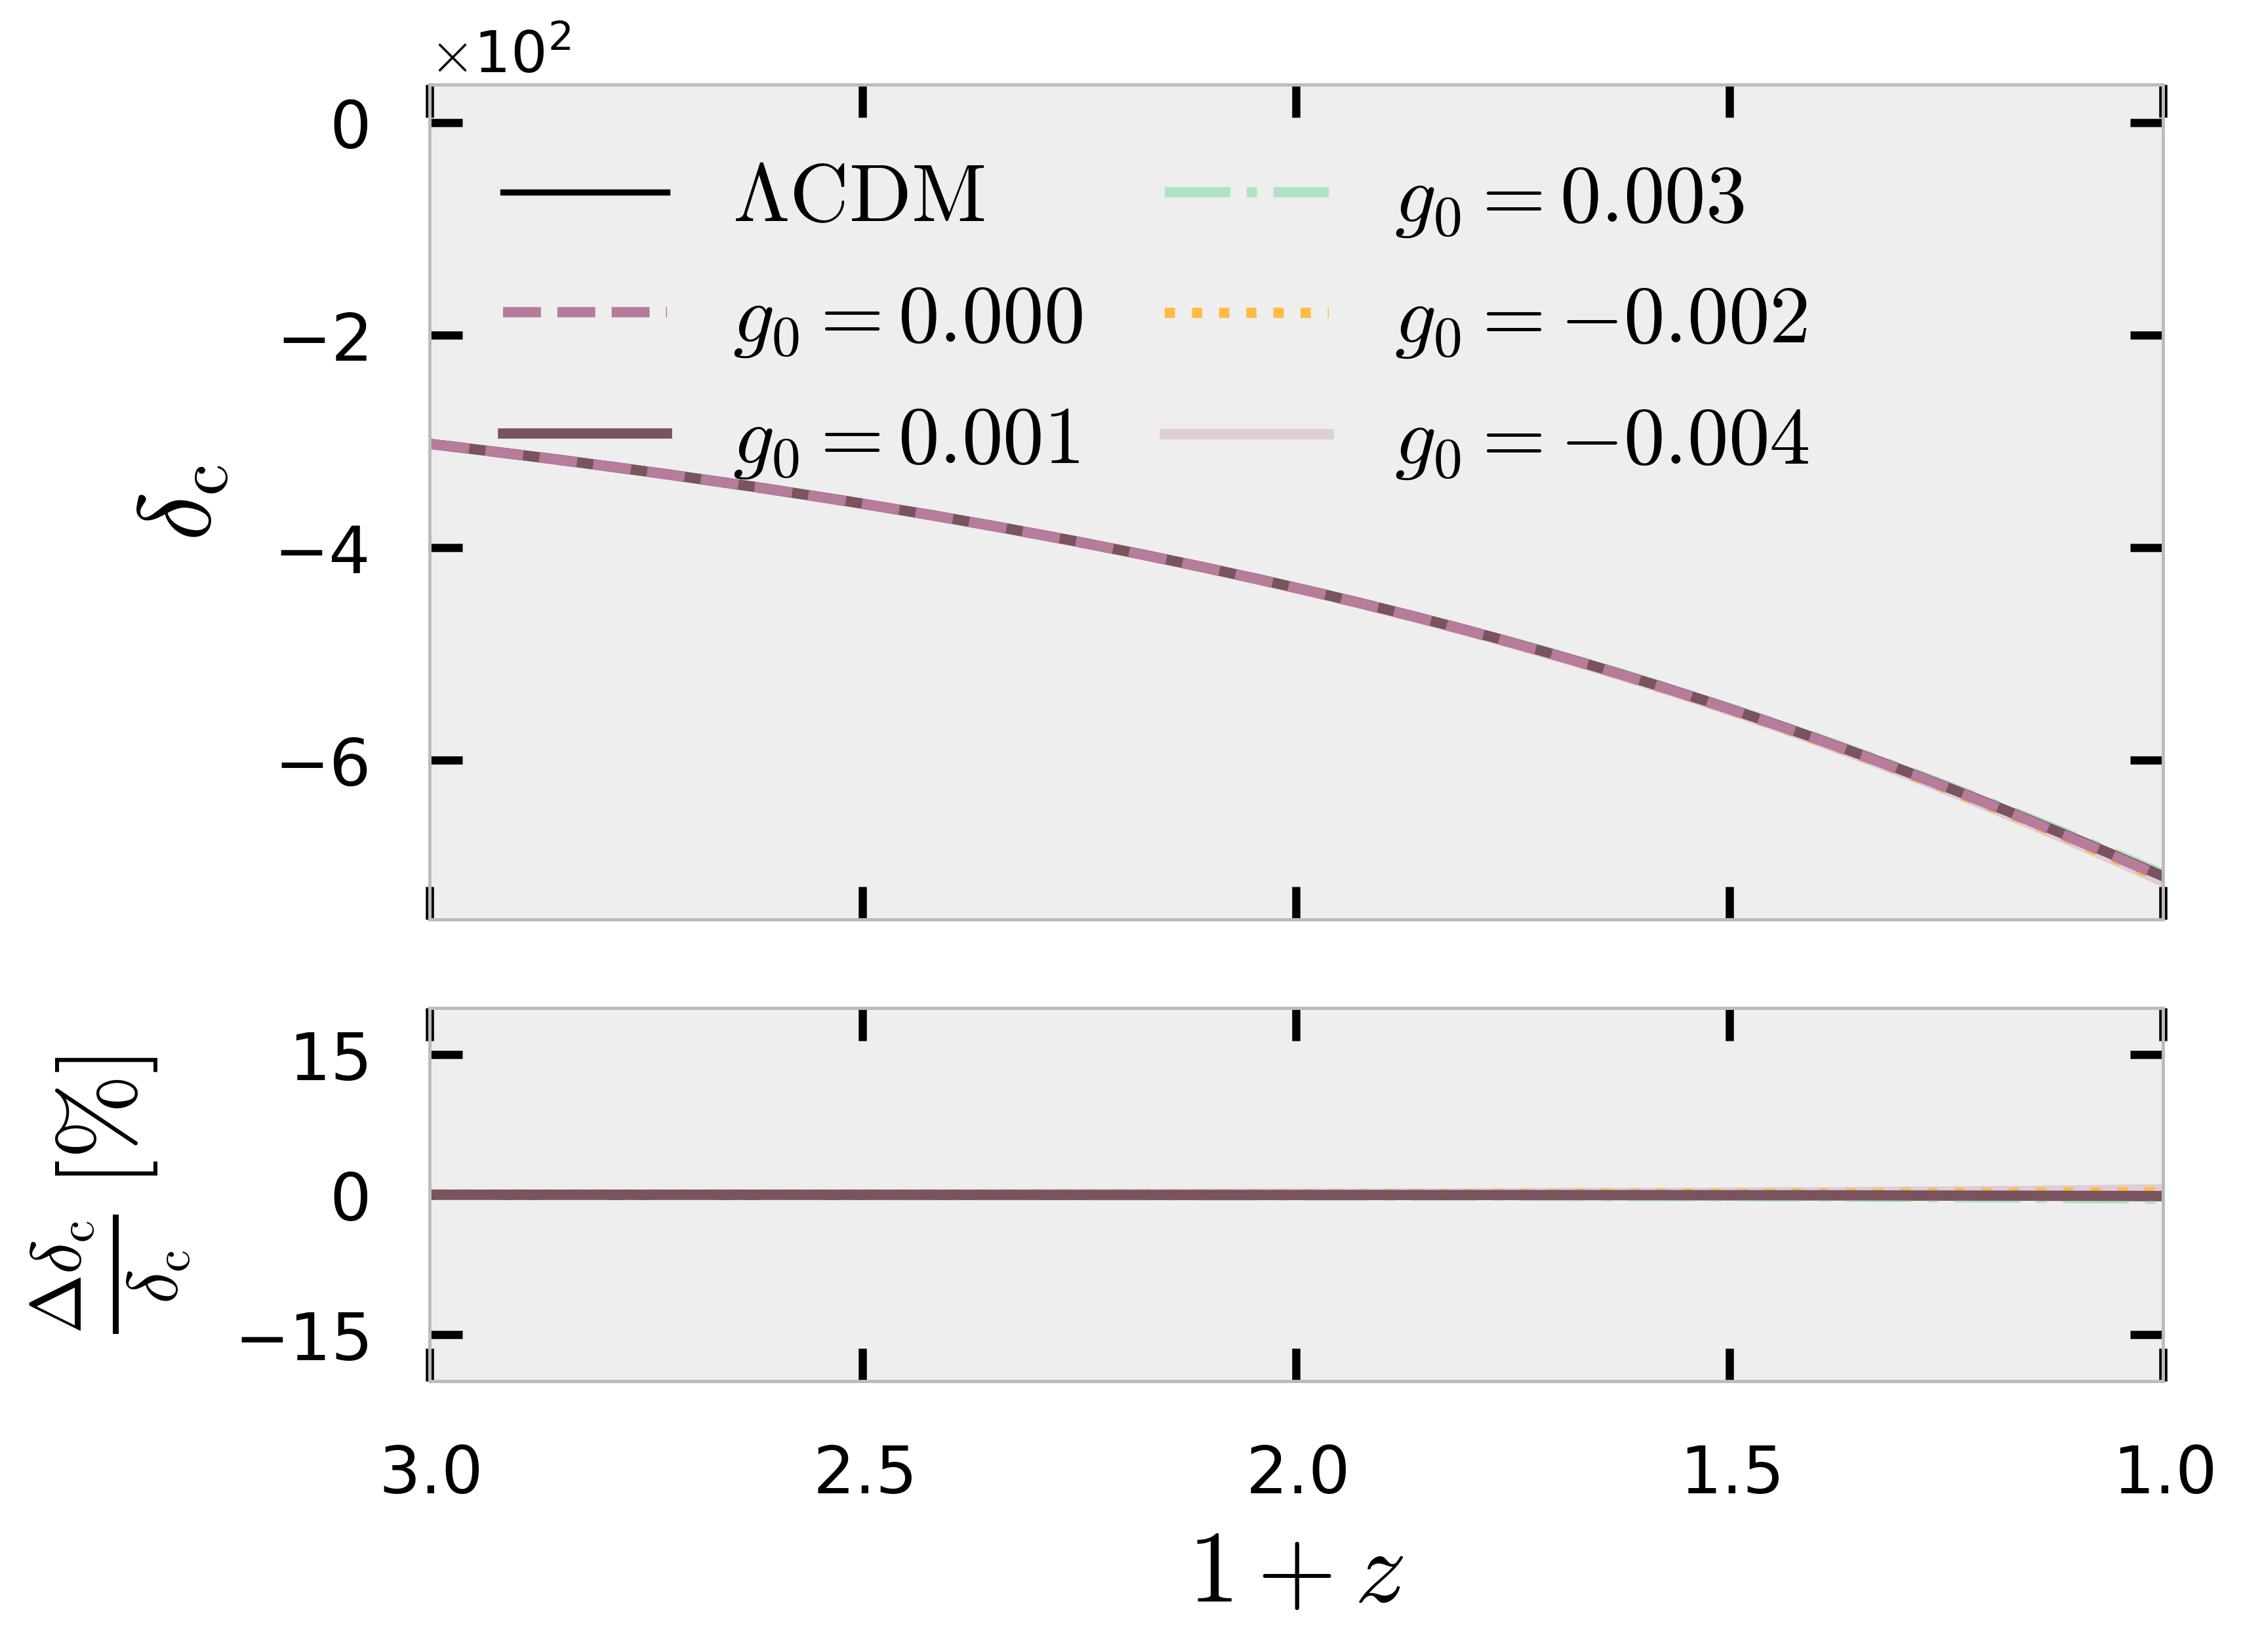

-0.07145235358546084


In [ ]:
# #print(k_sorted)
# index_k_list = [0]
# label = [r'$|\delta_{\rm c}| \times10^{-4}$','','','','']

# lw = 2.5
# ls = ['--','-','-.', ':', '-']
# plt.style.use('bmh')
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# fig = plt.figure(figsize=(8,6))
# ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
# ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

# plt.subplots_adjust(hspace=0,wspace=0.)

# from scipy.interpolate import interp1d
# import numpy as np
# import matplotlib.pyplot as plt

# def build_interp1d_monotonic(x, y, kind='linear', clamp=True):
#     """interp1d with sorting and duplicate-x handling."""
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y)
#         yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# # --- your plotting code (only the relevant bits changed) ---

# index_k = 1  # you set this explicitly
# print(k_sorted[index_k])

# standardPerturb = standard.get_perturbations()
# a0 = standardPerturb['scalar'][index_k]['a']                 # standard grid
# z0 = 1/a0 - 1
# delta_c0 = standardPerturb['scalar'][index_k]['delta_cdm']

# # interpolator: δ_c^Lc(a)
# f_delta0_of_a = build_interp1d_monotonic(a0, delta_c0, kind='linear', clamp=True)

# # plot the Lc baseline on its own grid (top panel)
# ax0.plot(1+z0, delta_c0, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1.5)

# for index in [0,1,2,3,4]:  # your beta values
#     cosmoPerturb = cosmo[index].get_perturbations()
#     a = cosmoPerturb['scalar'][index_k]['a']                  # this run's grid
#     z = 1/a - 1
#     delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']

#     # interpolate standard onto THIS grid => shapes now match
#     delta_c0_on_a = f_delta0_of_a(a)

#     # top panel
#     ax0.plot(1+z, delta_c,label=rf'$g_0 = {f0s[index]:.3f}$', lw=lw, ls=ls[index], c=color[index])

#     # bottom panel: percent difference, guard against tiny denominators
#     eps = 1e-300
#     denom = np.where(np.abs(delta_c0_on_a) > eps, delta_c0_on_a, np.nan)
#     rel = 100.0 * (delta_c - delta_c0_on_a) / denom

#     ax1.plot(1+z, rel, lw=lw, ls=ls[index], c=color[index])

#     #ax0.plot(1+z, np.abs(cosmoPerturb['scalar'][index_k]['delta_rho_scf'])*1e-4, c='k', ls='-', label = r'$\delta {\phi}$',lw=1.5)

#     ax0.set_ylabel(label[index], size=25)
#     ax1.set_xlabel(r'$1+z$', size=25)
#     #ax0.set_xlim(1e5,1)
#     # ax0.set_ylim(1e-3,1)
#     #ax0.set_title('k = '+str(k_sorted[index_k]), size=20)
#     ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
#     for tick in ax0.xaxis.get_major_ticks():
#         tick.set_pad(10)
#     for tick in ax0.yaxis.get_major_ticks():
#         tick.set_pad(10)    

# #ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
# #ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

# #ax0.set_xscale('log');ax0.set_yscale('log')
# ax1.set_xscale('linear');ax1.set_yscale('linear')

# ax1.set_ylabel(r'$ \frac{\Delta \delta_{\rm c}}{\delta_{\rm c}}\, [\%]$', size=25,labelpad=10)
# ax0.set_ylabel(r'$ \delta_{\rm c}$', size=25,labelpad=10)

# # #ns-f0 plot and ns-h0 plot 
# # #ax0.set_xlim([1.e-3,0.1])
# # ax1.set_xlim(3,1)
# # ax0.set_ylim(0.45,1.25)
# # ax1.set_ylim(-2,12)
# # ax1.set_yticks([i for i in np.linspace(0,10,3)])
# # ax1.set_xticks([i for i in np.linspace(3,1,5)])

# #h0 plot
# #ax0.set_xlim([1.e-3,0.1])
# ax1.set_xlim(3,1)
# # ax0.set_ylim(0.45,1.5)
# ax1.set_ylim(-20,20)
# ax1.set_yticks([i for i in np.linspace(-15,15,3)])
# ax1.set_xticks([i for i in np.linspace(3,1,5)])
    
# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# #ax0.set_xscale('log')
# #ax0.set_yscale('log')
# # original_labels = ax0.get_xticks()
# # labels = []
# # for label in original_labels:
# #     labels.append(int(np.log10(label)))
# # ax0.set_xticklabels(labels)

# ax1.ticklabel_format(axis='y', style='plain', useMathText=True)


# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=1)
# plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 20
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# fig.tight_layout()
# # plt.savefig('deltac_alg_constant2.pdf')
# #, transparent=True)

# plt.show()

# print(cosmoPerturb['scalar'][index_k]['delta_edm'][-1]*1e-4)

In [ ]:
plt.style.use('bmh')

lw = 2.5
ls = ['-','--',':', '-.', (0,(5,1))]

fig = plt.figure(figsize=(8,6.5))
ax0 = plt.subplot2grid((4,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((4,1),(2,0), rowspan=2,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)
i=0
zz = np.logspace(4,0,10000)
#print(zz)
oml = interp1d(1.+standard_background['z'], standard_background['(.)rho_lambda'],kind='cubic')

#print(standard.Hubble(0))
for index in [0,1,2,3,4]:
    my_cosmo = cosmo[index]
    my_hub = []
    my_omr = []
    omsf = interp1d(1.+cosmo_background[index]['z'], cosmo_background[index]['(.)rho_scf'],kind='cubic')
    for z in zz:
        my_omr.append(omsf(z)/oml(z))
        my_hub.append(100*(my_cosmo.Hubble(z-1)-standard.Hubble(z-1))/standard.Hubble(z-1))
    print(my_cosmo.Hubble(0)-standard.Hubble(0))
    ax0.plot(zz,my_omr, label = \
                 r'$h_0=\,%.2f $'%h0s[index], lw=lw, ls=ls[i], c=color[i])
    ax1.plot(zz,my_hub, label = \
                 r'$h_0=\,%.2f $'%h0s[index], lw=lw, ls=ls[i], c=color[i])
    i+=1

#ax0.plot(1.+standard_background['z'],standard_background['(.)rho_lambda']/standard_background['(.)rho_cdm'],'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)


ax0.set_xscale('log');ax0.set_yscale('linear')
ax1.set_xscale('log');ax1.set_yscale('linear')

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\log \left( \rho_{\phi}/\rho_{\Lambda} \right)$', size=25,labelpad=15,rotation=90)
ax1.set_ylabel(r'$\frac{\Delta \mathcal{H}}{\mathcal{H}}\, [\%]$', size=25,labelpad=10)

ax0.set_xlim([1.e4,1.])
ax1.set_xlim([1.e4,1.])
ax0.set_ylim([0.99,1.01])
ax1.set_ylim(-7.,2)
ax1.set_yticks([i for i in np.linspace(-6.,0.,3)])
# ax0.set_yticks([i for i in np.linspace(1.,2,3)])

#ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)

#ax0.set_yscale('log')
ax1.set_xscale('log')
ax0.set_xscale('log')

original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

# original_labels = ax0.get_yticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_yticklabels(labels)



ax0.tick_params(axis='both', which='both', labelsize=16)


ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)


ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 19},ncol=2, columnspacing=0.8)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
# plt.savefig('hub_alg_constant.pdf', transparent=True)
plt.show()

6.7556e-05
n = 0.0 h0 = 0.0 f0 = 0.001
-5.013264933430165e-32 -5.013146890180492e-32
3.2030552132289017e-07 9.999999999999987e-15
391843275491.1669 1.2876732478210256e+34
0.9999999954361869 1.44983e-10 6.7556e-05 0.148438958493903


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


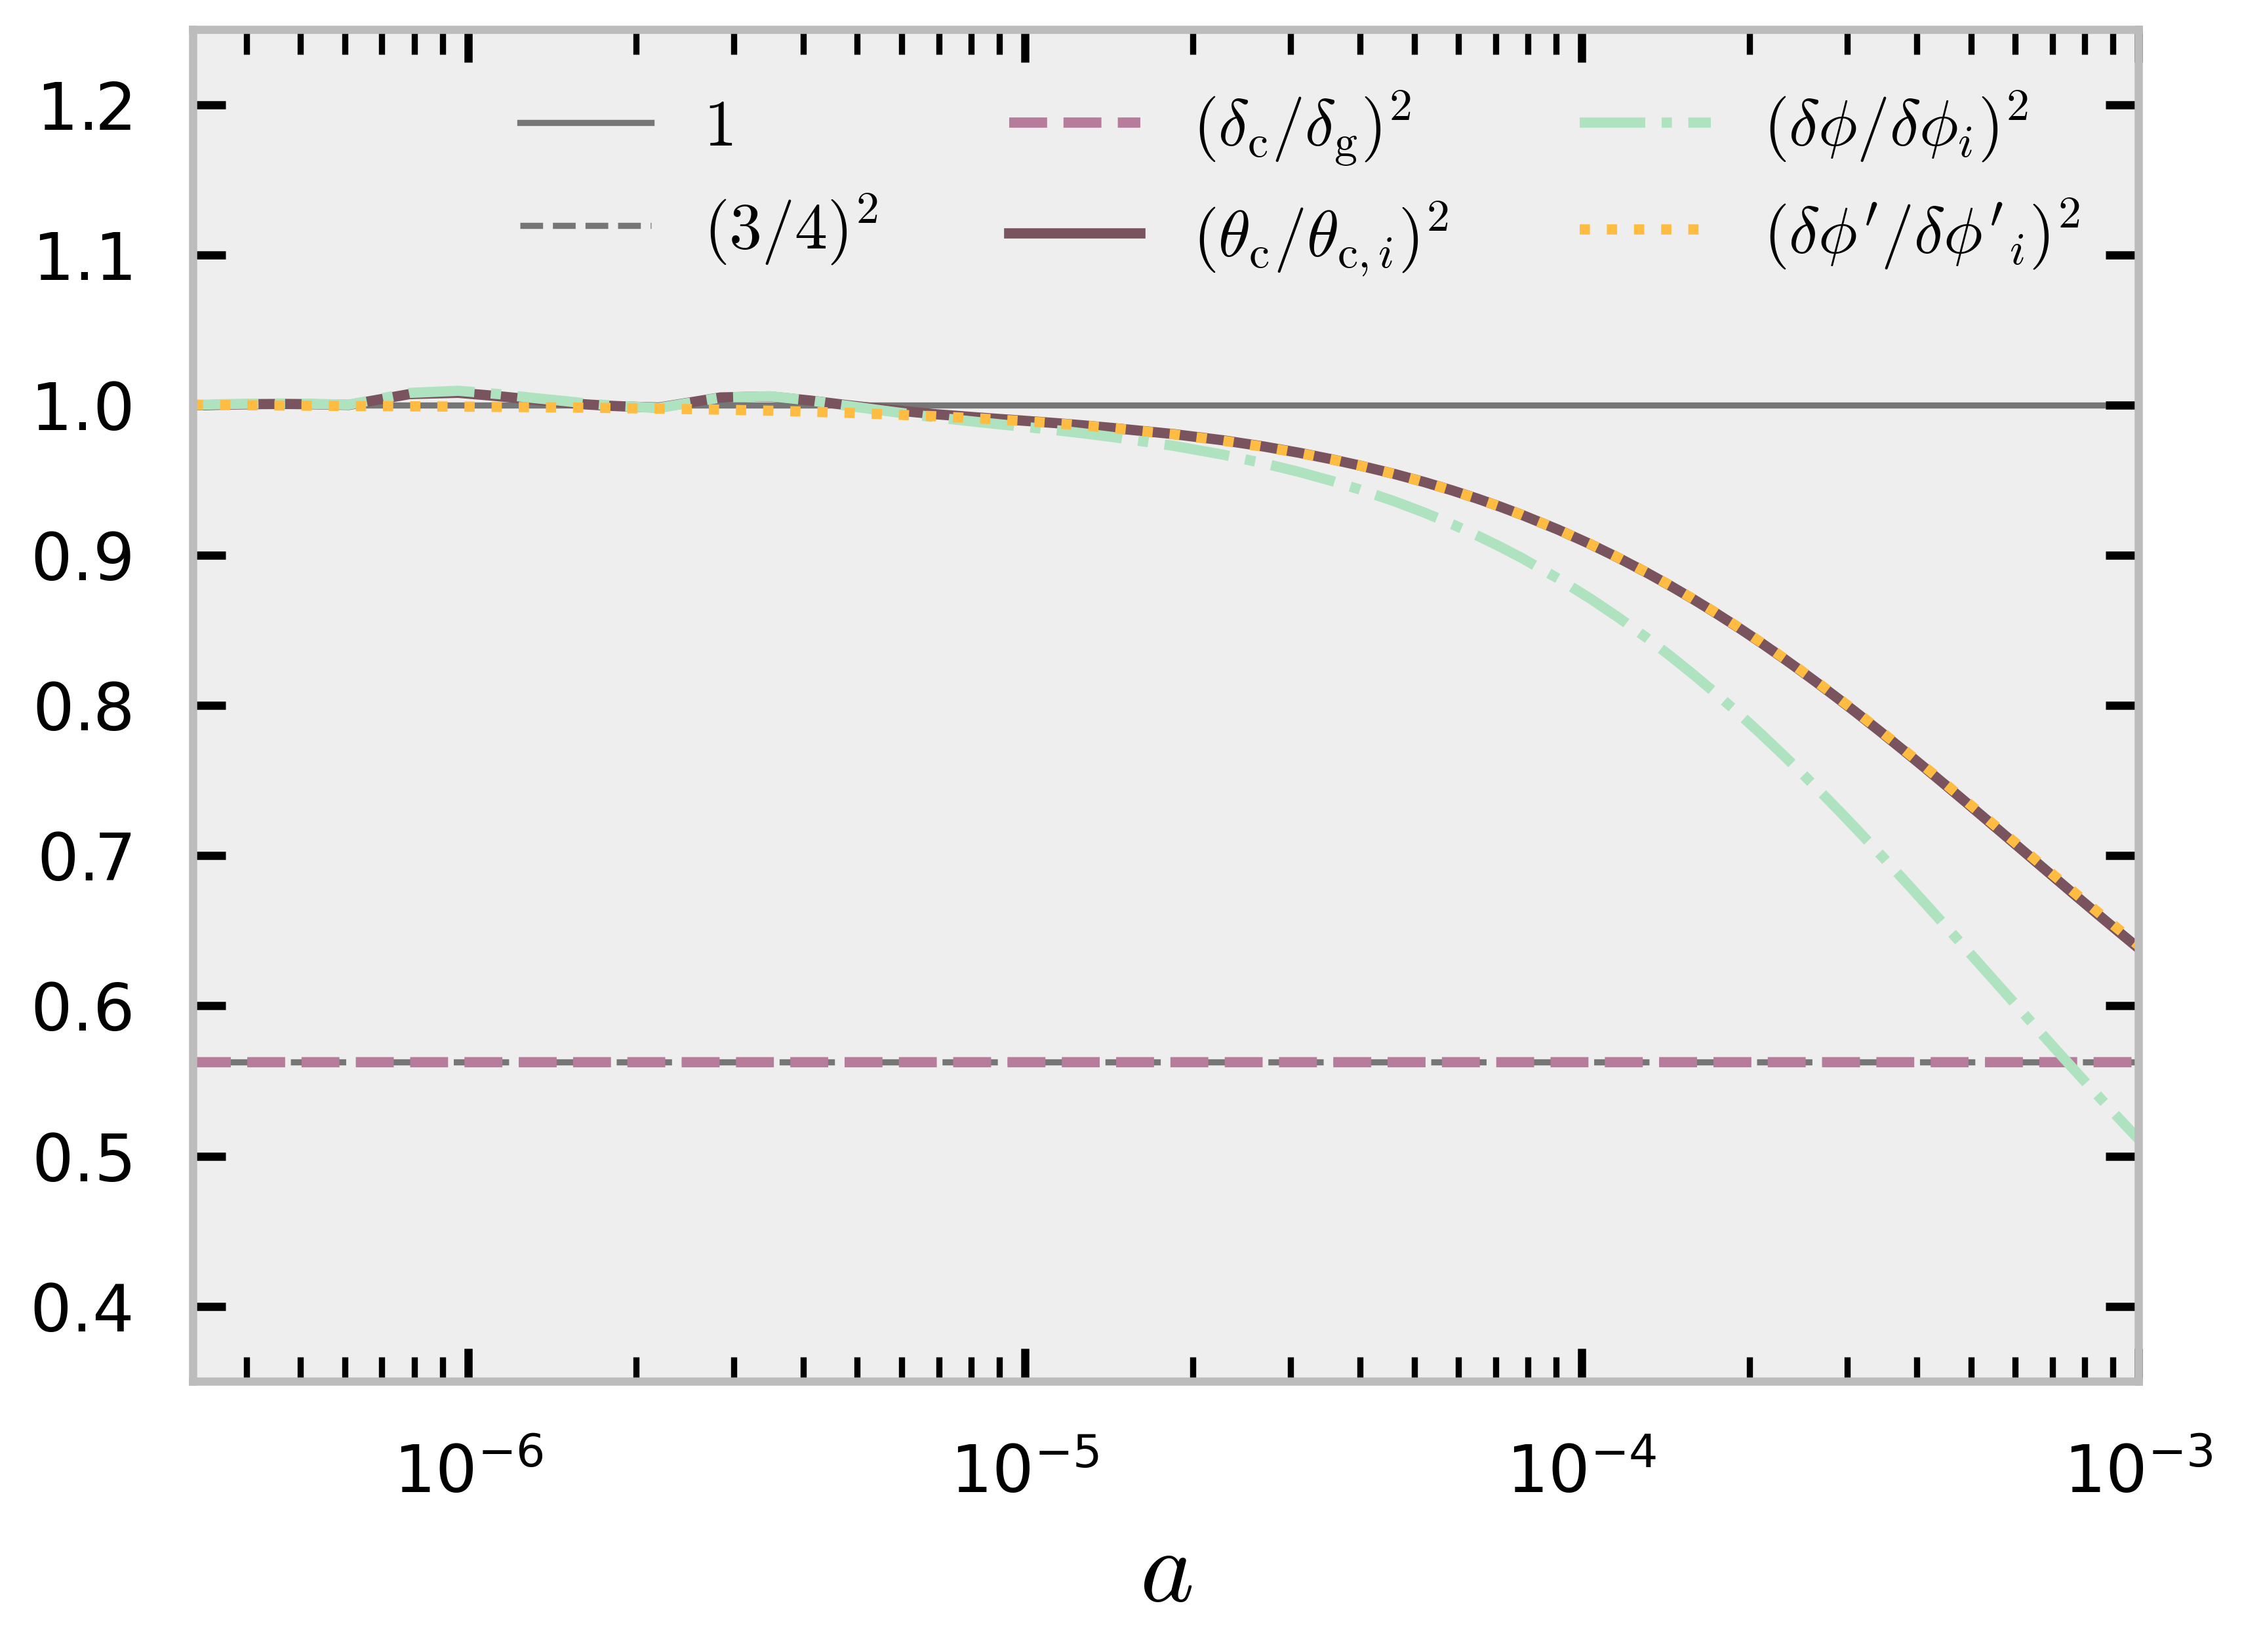

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# from scipy.interpolate import PchipInterpolator



# lw = 2.5
# ls = ['--','-','-.', ':', '-']
# plt.style.use('bmh')
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# lw = 2.5
# eps = 1e-300

# index_k = 0
# k = k_sorted[index_k]
# print(k)
# # print(k_sorted)
# index = 1
# cosmoPerturb = cosmo[index].get_perturbations()
# cosmoBack = cosmo[index].get_background()
# P = cosmoPerturb['scalar'][index_k]
# print("n =", n0s[index], "h0 =", h0s[index], "f0 =", f0s[index])

# a   = np.asarray(P['a'])
# tau = np.asarray(P['tau [Mpc]'])

# def pchip(x, y):
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     return PchipInterpolator(x, y, extrapolate=False)


# # Extract background quantities
# z_bg = np.asarray(cosmoBack['z'])
# a_bg = 1.0/(1.0 + z_bg)
# H_bg = np.asarray(cosmoBack['H [1/Mpc]'])
# phi_bg = np.asarray(cosmoBack['phi_scf'])
# phi_prime_bg = np.asarray(cosmoBack["phi'_scf"])
# V_bg = np.asarray(cosmoBack['V_scf'])
# V_prime_bg = np.asarray(cosmoBack["V'_scf"])
# V_primeprime_bg = np.asarray(cosmoBack["V''_scf"])
# f_bg = np.asarray(cosmoBack['f_scf'])
# f_prime_bg = np.asarray(cosmoBack["f'_scf"])
# f_primeprime_bg = np.asarray(cosmoBack["f''_scf"])
# h_bg = np.asarray(cosmoBack['h_scf'])
# rho_edm_bg = np.asarray(cosmoBack['(.)rho_edm'])
# rho_tot_bg = np.asarray(cosmoBack['(.)rho_tot'])

# # Interpolate background to perturbation a-grid

# phi_int = pchip(a_bg, phi_bg)
# phi_prime_int = pchip(a_bg,phi_prime_bg)
# V_int = pchip(a_bg, V_bg)
# V_prime_int = pchip(a_bg, V_prime_bg)
# V_primeprime_int = pchip(a_bg, V_primeprime_bg)
# f_int = pchip(a_bg, f_bg)
# f_prime_int = pchip(a_bg, f_prime_bg)
# f_primeprime_int = pchip(a_bg, f_primeprime_bg)
# h_int = pchip(a_bg, h_bg)
# H_int = pchip(a_bg, H_bg)
# rho_edm_int = pchip(a_bg, rho_edm_bg)

# # Evaluate on perturbation a-grid
# phi_pert = phi_int(a)
# phi_prime_pert = phi_prime_int(a)
# V_pert = V_int(a)
# V_prime_pert = V_prime_int(a)
# V_primeprime_pert = V_primeprime_int(a)
# f_pert = f_int(a)
# f_prime_pert = f_prime_int(a)
# f_primeprime_pert = f_primeprime_int(a)
# h_pert = h_int(a)
# H_pert = H_int(a)
# rho_edm_pert = rho_edm_int(a)

# delta_edm  = np.asarray(P['delta_edm'])
# delta_g  = np.asarray(P['delta_g'])
# theta_edm  = np.asarray(P['theta_edm'])
# delta_phi  = np.asarray(P['delta_phi_scf'])
# delta_phi_p = np.asarray(P['delta_phi_prime_scf'])
# delta_s    = np.asarray(P['delta_s_scf'])   # your conserved entropy mode output

# a_p = np.asarray(P['a'])
# theta_edm_int = interp1d(a_p, theta_edm, kind='cubic', bounds_error=False, fill_value='extrapolate')

# kt = k * tau

# # --- plateau diagnostics ---
# den2ds = delta_s * (kt**2) + eps
# den4ds = delta_s * (kt**4) + eps
# den3ds = delta_s * (kt**3) + eps
# den4dsnk = delta_s * (tau**4) + eps
# den3dsnk = delta_s * (tau**3) + eps
# den4ds = delta_s * (kt**3) + eps
# den2 = (kt**2) + eps
# den1ds = delta_s * (k * kt) + eps
# # print(a/tau)
# D_cons = (f_pert - h_pert*V_prime_pert)
# # den_theta = -delta_s*(D_cons*pow(k,2))*tau*rho_edm_pert/(5)
# den_theta = -(k**2) * D_cons * delta_s * tau / (5.0 * rho_edm_pert)

# den_theta_int = interp1d(a_p, den_theta, kind='cubic', bounds_error=False, fill_value='extrapolate')

# # print('den_theta=',den_theta[0])
# den_phi = - (h_pert/6)*delta_s*(kt**2) - (a/tau)*(a/tau)*f_prime_pert*delta_s*tau**4/20
# den_phi_prime = - (h_pert/3)*delta_s*k*(kt) - (a/tau)*(a/tau)*f_prime_pert*delta_s*tau**3/5
# tau = P['tau [Mpc]']
# theta = P['theta_edm']
# theta_prime_num = (theta[1]-theta[0])/(tau[1]-tau[0])
# # print(theta_prime_num)

# # # Derivative case
# # Q_delta_edm = delta_edm / (delta_g)
# # #Q_delta_edm = delta_edm / den2ds
# # Q_delta_phi = delta_phi / den2ds
# # Q_theta_edm = theta_edm / den1ds
# # Q_delta_phi_p = delta_phi_p / den1ds

# # Algebraic case
# Q_delta_edm = delta_edm / (delta_g)
# #Q_delta_edm = delta_edm / den2ds
# # Q_delta_phi = delta_phi / den4ds
# Q_delta_phi = delta_phi / den_phi
# Q_theta_edm = theta_edm / den_theta
# print(theta_edm[0],den_theta[0])
# Q_delta_phi_p = delta_phi_p / den_phi_prime
# # print(theta_edm[0],den_theta[0])
# # print(Q_delta_edm[0], Q_theta_edm[0], Q_delta_phi[0], Q_delta_phi_p[0])
# # print(Q_theta_edm)

# print(a[0], a_bg.min())
# print(rho_edm_pert[0], rho_edm_bg[0])
# print(delta_s[0], D_cons[0], k, tau[0])


# # --- Fig.2-like plot ---
# fig = plt.figure(figsize=(8,6))
# ax = plt.gca()

# # Derivative case
# # ax.plot(a, np.abs(Q_delta_edm)**2, lw=lw, ls='-',  label=r'$(\delta_{\rm edm}/\delta_{\rm g})^2$')
# # ax.plot(a, np.abs(Q_theta_edm)**2, lw=lw, ls='--', label=r'$(\theta_{\rm edm}/[\delta s\,k(k\tau)])^2$')
# # ax.plot(a, np.abs(Q_delta_phi)**2, lw=lw, ls='-.', label=r'$(\delta\phi/[\delta s\,(k\tau)^2])^2$')
# # ax.plot(a, np.abs(Q_delta_phi_p)**2, lw=lw, ls=':',  label=r"$(\delta\phi'/[\delta s\,k(k\tau)])^2$")
# #ax.hlines(y=(3/4)**2, xmin=a[0], xmax=a[-1], lw=lw, ls=':',  label=r"$(3/4)^2$")

# # Algebraic case
# ax.axhline(1, color='k', ls='-', lw=1.5, alpha=0.5,label=r'$1$')
# ax.axhline(9/16, color='k', ls='--', lw=1.5, alpha=0.5,label=r'$(3/4)^2$')
# ax.plot(a, np.abs(Q_delta_edm)**2, lw=lw, ls='--',  label=r'$(\delta_{\rm c}/\delta_{\rm g})^2$',color=color[0])
# ax.plot(a, np.abs(Q_theta_edm)**2, lw=lw, ls='-', label=r'$(\theta_{\rm c}/\theta_{{\rm c},i})^2$',color=color[1])
# ax.plot(a, np.abs(Q_delta_phi)**2, lw=lw, ls='-.', label=r'$(\delta\phi/\delta\phi_i)^2$',color=color[2])
# ax.plot(a, np.abs(Q_delta_phi_p)**2, lw=lw, ls=':',  label=r"$(\delta\phi'/\delta\phi'_i)^2$",color=color[3])
# # ax.plot(a, np.abs(1e-18*pow(a,2)),lw=lw/2, ls='-', c='blue')

# ax.set_xscale('log')
# ax.set_yscale('linear')
# ax.set_xlim(a[0],1e-3)
# ax.set_ylim(0.35,1.25)
# ax.set_xlabel(r'$a$', size=25)

# original_labels = ax.get_xticks()
# labels = []
# # for label in original_labels:
# #     labels.append(int(np.log10(label)))
# # ax.set_xticklabels(labels)
# # Styling
# ax.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
# ax.tick_params(axis='both', which='both', labelsize=16)
# ax.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax.tick_params(axis='both', which='both', labelsize=16)
# ax.tick_params(axis='both', which='both', labelsize=16)
# for tick in ax.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax.yaxis.get_major_ticks():
#     tick.set_pad(15)
#     tick.set_pad(15)

# ax.tick_params(axis='both', which='both', labelsize=16)
# ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on')
# ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# #ax.set_ylabel(r'IC diagnostic (squared)', size=25, labelpad=10)

# # ax.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax.legend(loc='best', frameon=boolean, prop={'size': 16},ncol=3)
# # plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 20
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# fig.tight_layout()

# fig.tight_layout()
# plt.savefig('IC_attractor_entropy_mode_alg_constant.pdf')
# plt.show()


-0.09298304556877683
-0.09148602758518157
-707.3444195935886
-710.4209463611874
-11007.123067811039
-11313.578917442614


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_14158/3399890316.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)


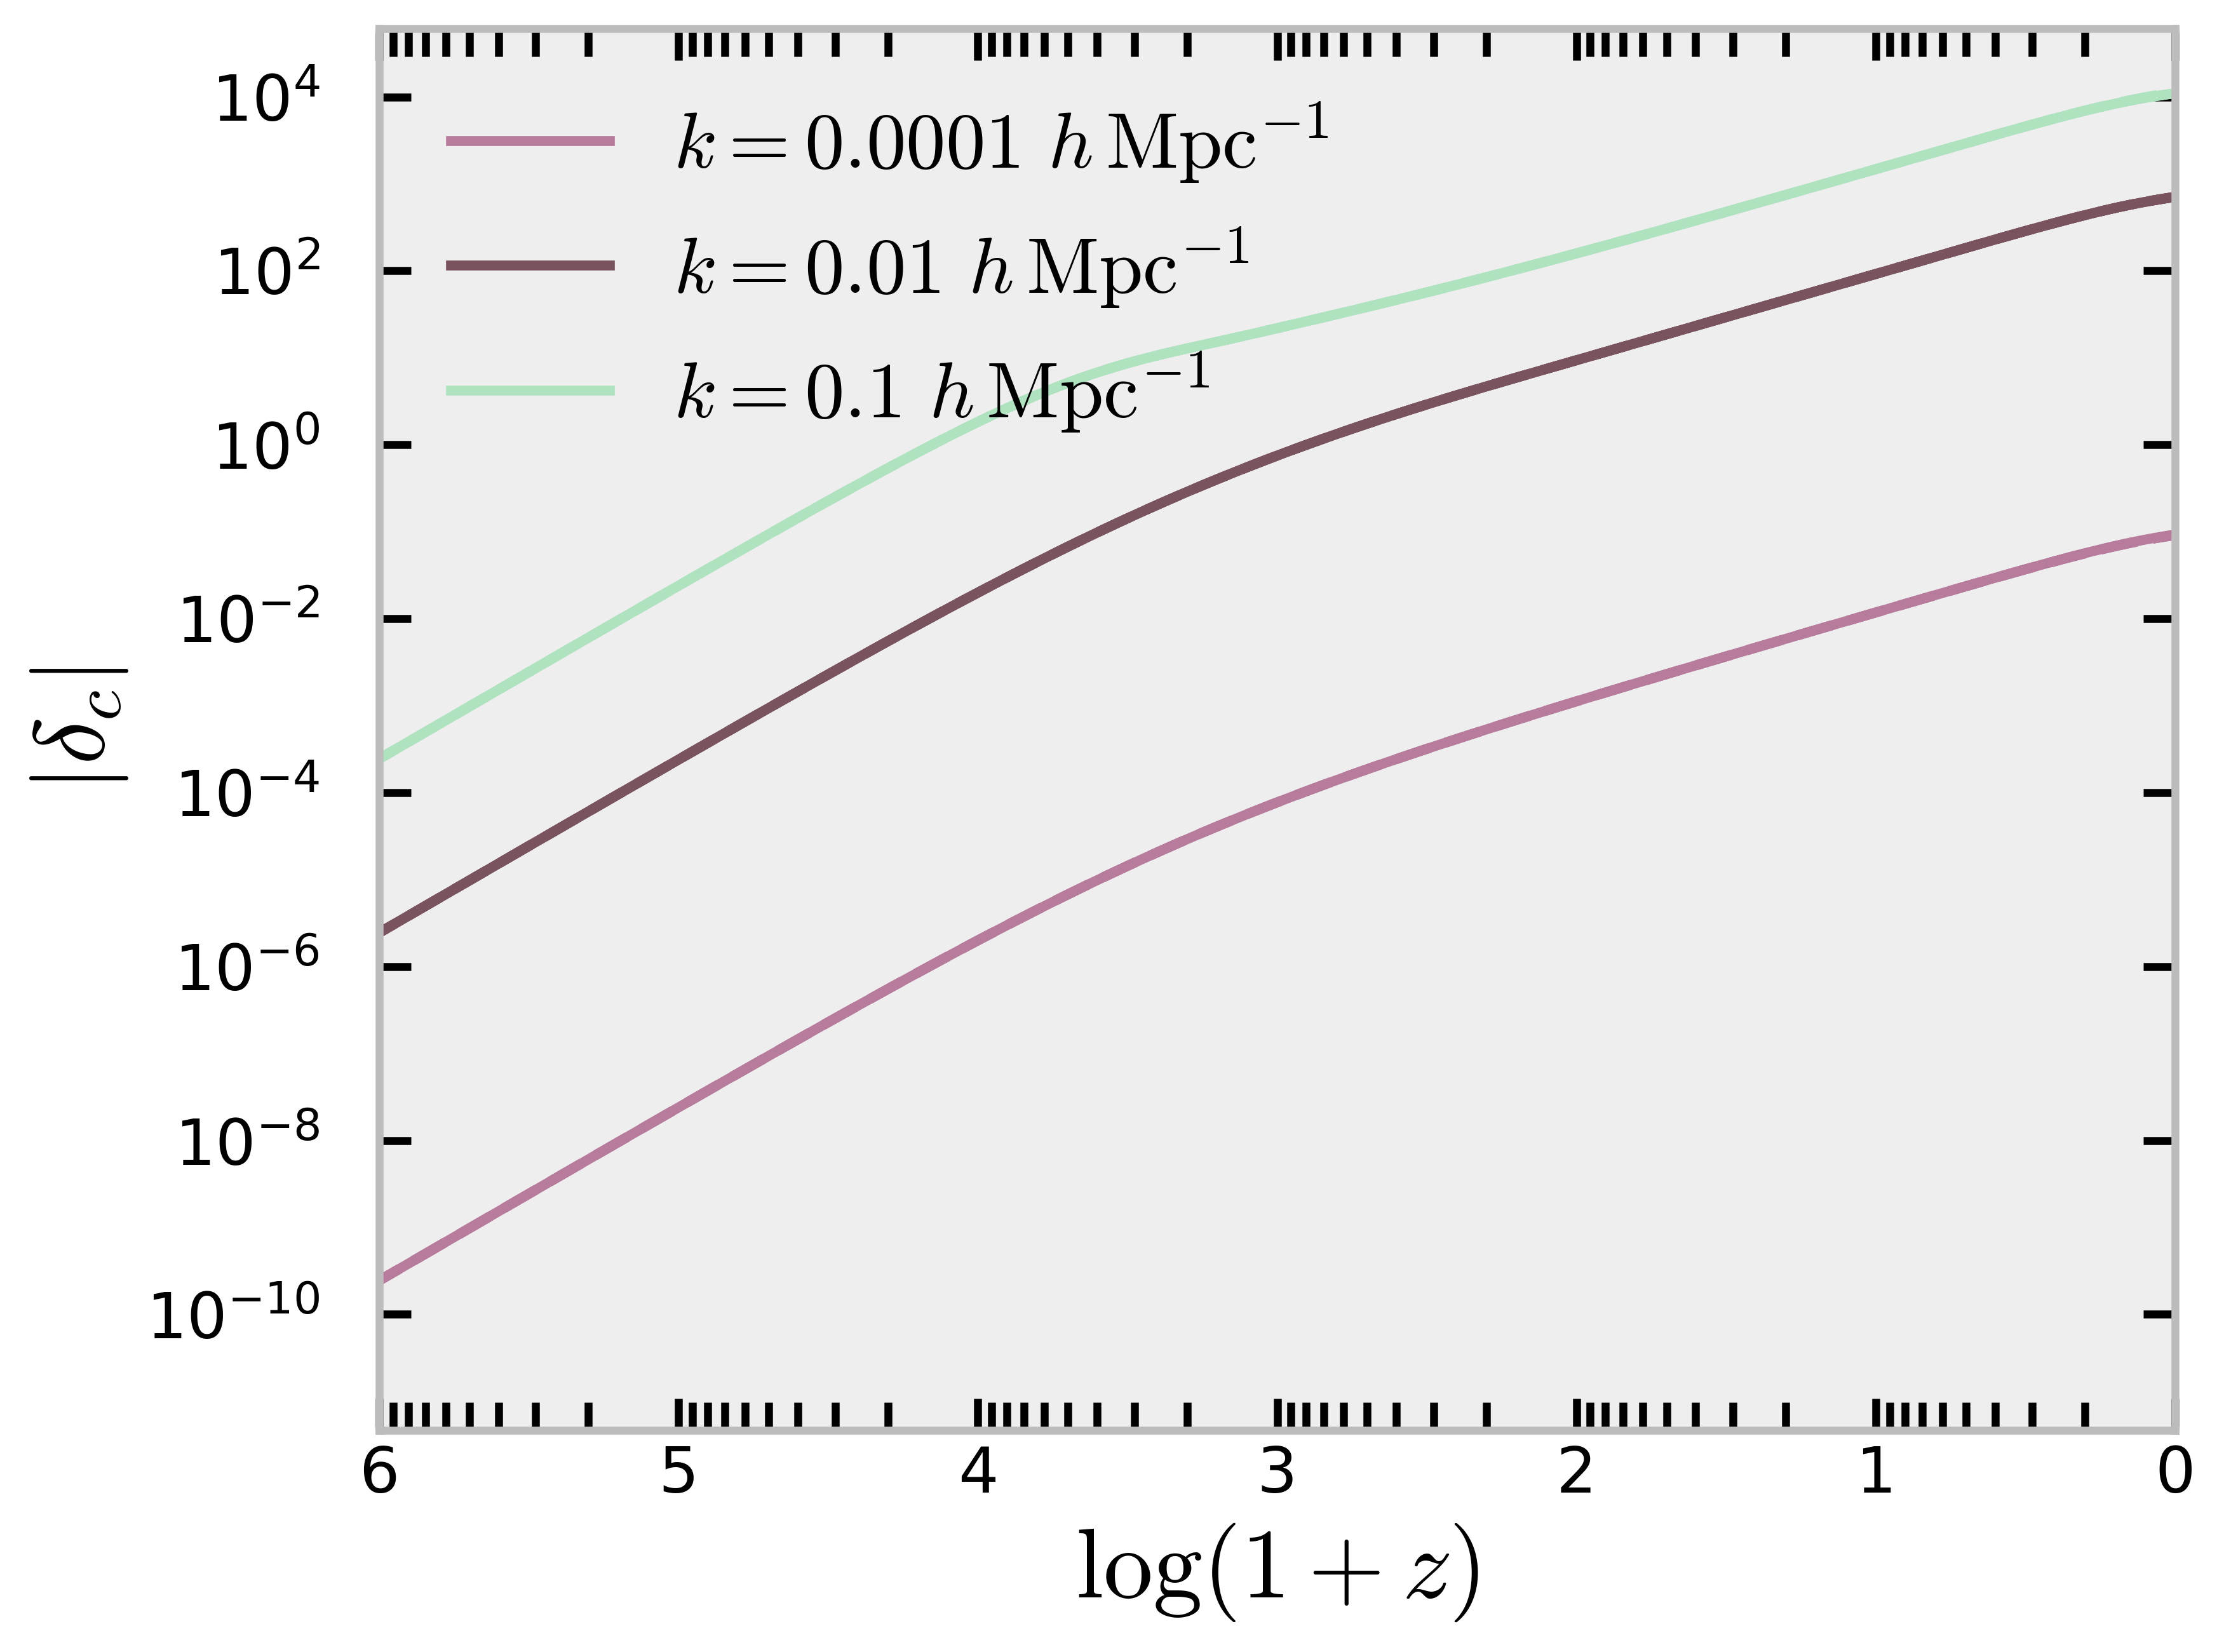

In [ ]:
# fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only

# ls = ['-','--','-.', ':', (0,(5,1))]

# plt.style.use('bmh')
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])


# for ik, index_k in enumerate([0,1,2]):  # loop over k values
#     color_idx = ik  # color depends on k
    
#     for ib, index in enumerate([2,0]):  # loop over beta values
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoPerturb0 = cosmo[0].get_perturbations()
#         cosmoBack = cosmo[index].get_background()

#         a = cosmoPerturb['scalar'][index_k]['a']
#         z = 1/a - 1
#         delta_phi = cosmoPerturb['scalar'][index_k]['delta_phi_scf']
#         delta_phi0 = cosmoPerturb0['scalar'][index_k]['delta_phi_scf']
#         delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']
#         delta_c0 = cosmoPerturb0['scalar'][index_k]['delta_edm']

#         # label only once per k (when ib == 0)
#         label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

#         ax0.plot(1+z, -delta_c,
#                  label=label_str,
#                  lw=lw, ls=ls[ib], c=color[color_idx])
#         print(delta_c[-1])
        
# # ax0.plot(1+z, 1e4*pow(1+z,-1),lw=lw/2, ls='-', c='blue')
# # Set axis labels and scales
# ax0.set_xscale('log')
# ax0.set_yscale('log')
# ax0.set_xlabel(r'$\log(1+z)$', size=25)
# ax0.set_ylabel(r'$|\delta_c|$', size=25)
# ax0.set_xlim(1e6, 1)
# original_labels = ax0.get_xticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_xticklabels(labels)

# # Styling
# ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20}, ncol=1)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# fig.tight_layout()
# # plt.savefig('deltac_ks3_alg_constant.pdf')
# plt.show()


6.7556e-05
k=6.76e-05 index=5 max rel diff=1.507e-14
k=6.76e-05 index=0 max rel diff=3.493e-16
0.0067556000000000005
k=0.00676 index=5 max rel diff=1.326e-13
k=0.00676 index=0 max rel diff=1.268e-12
0.067556
k=0.0676 index=5 max rel diff=1.482e-13
k=0.0676 index=0 max rel diff=1.266e-13


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_14158/1425901102.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)


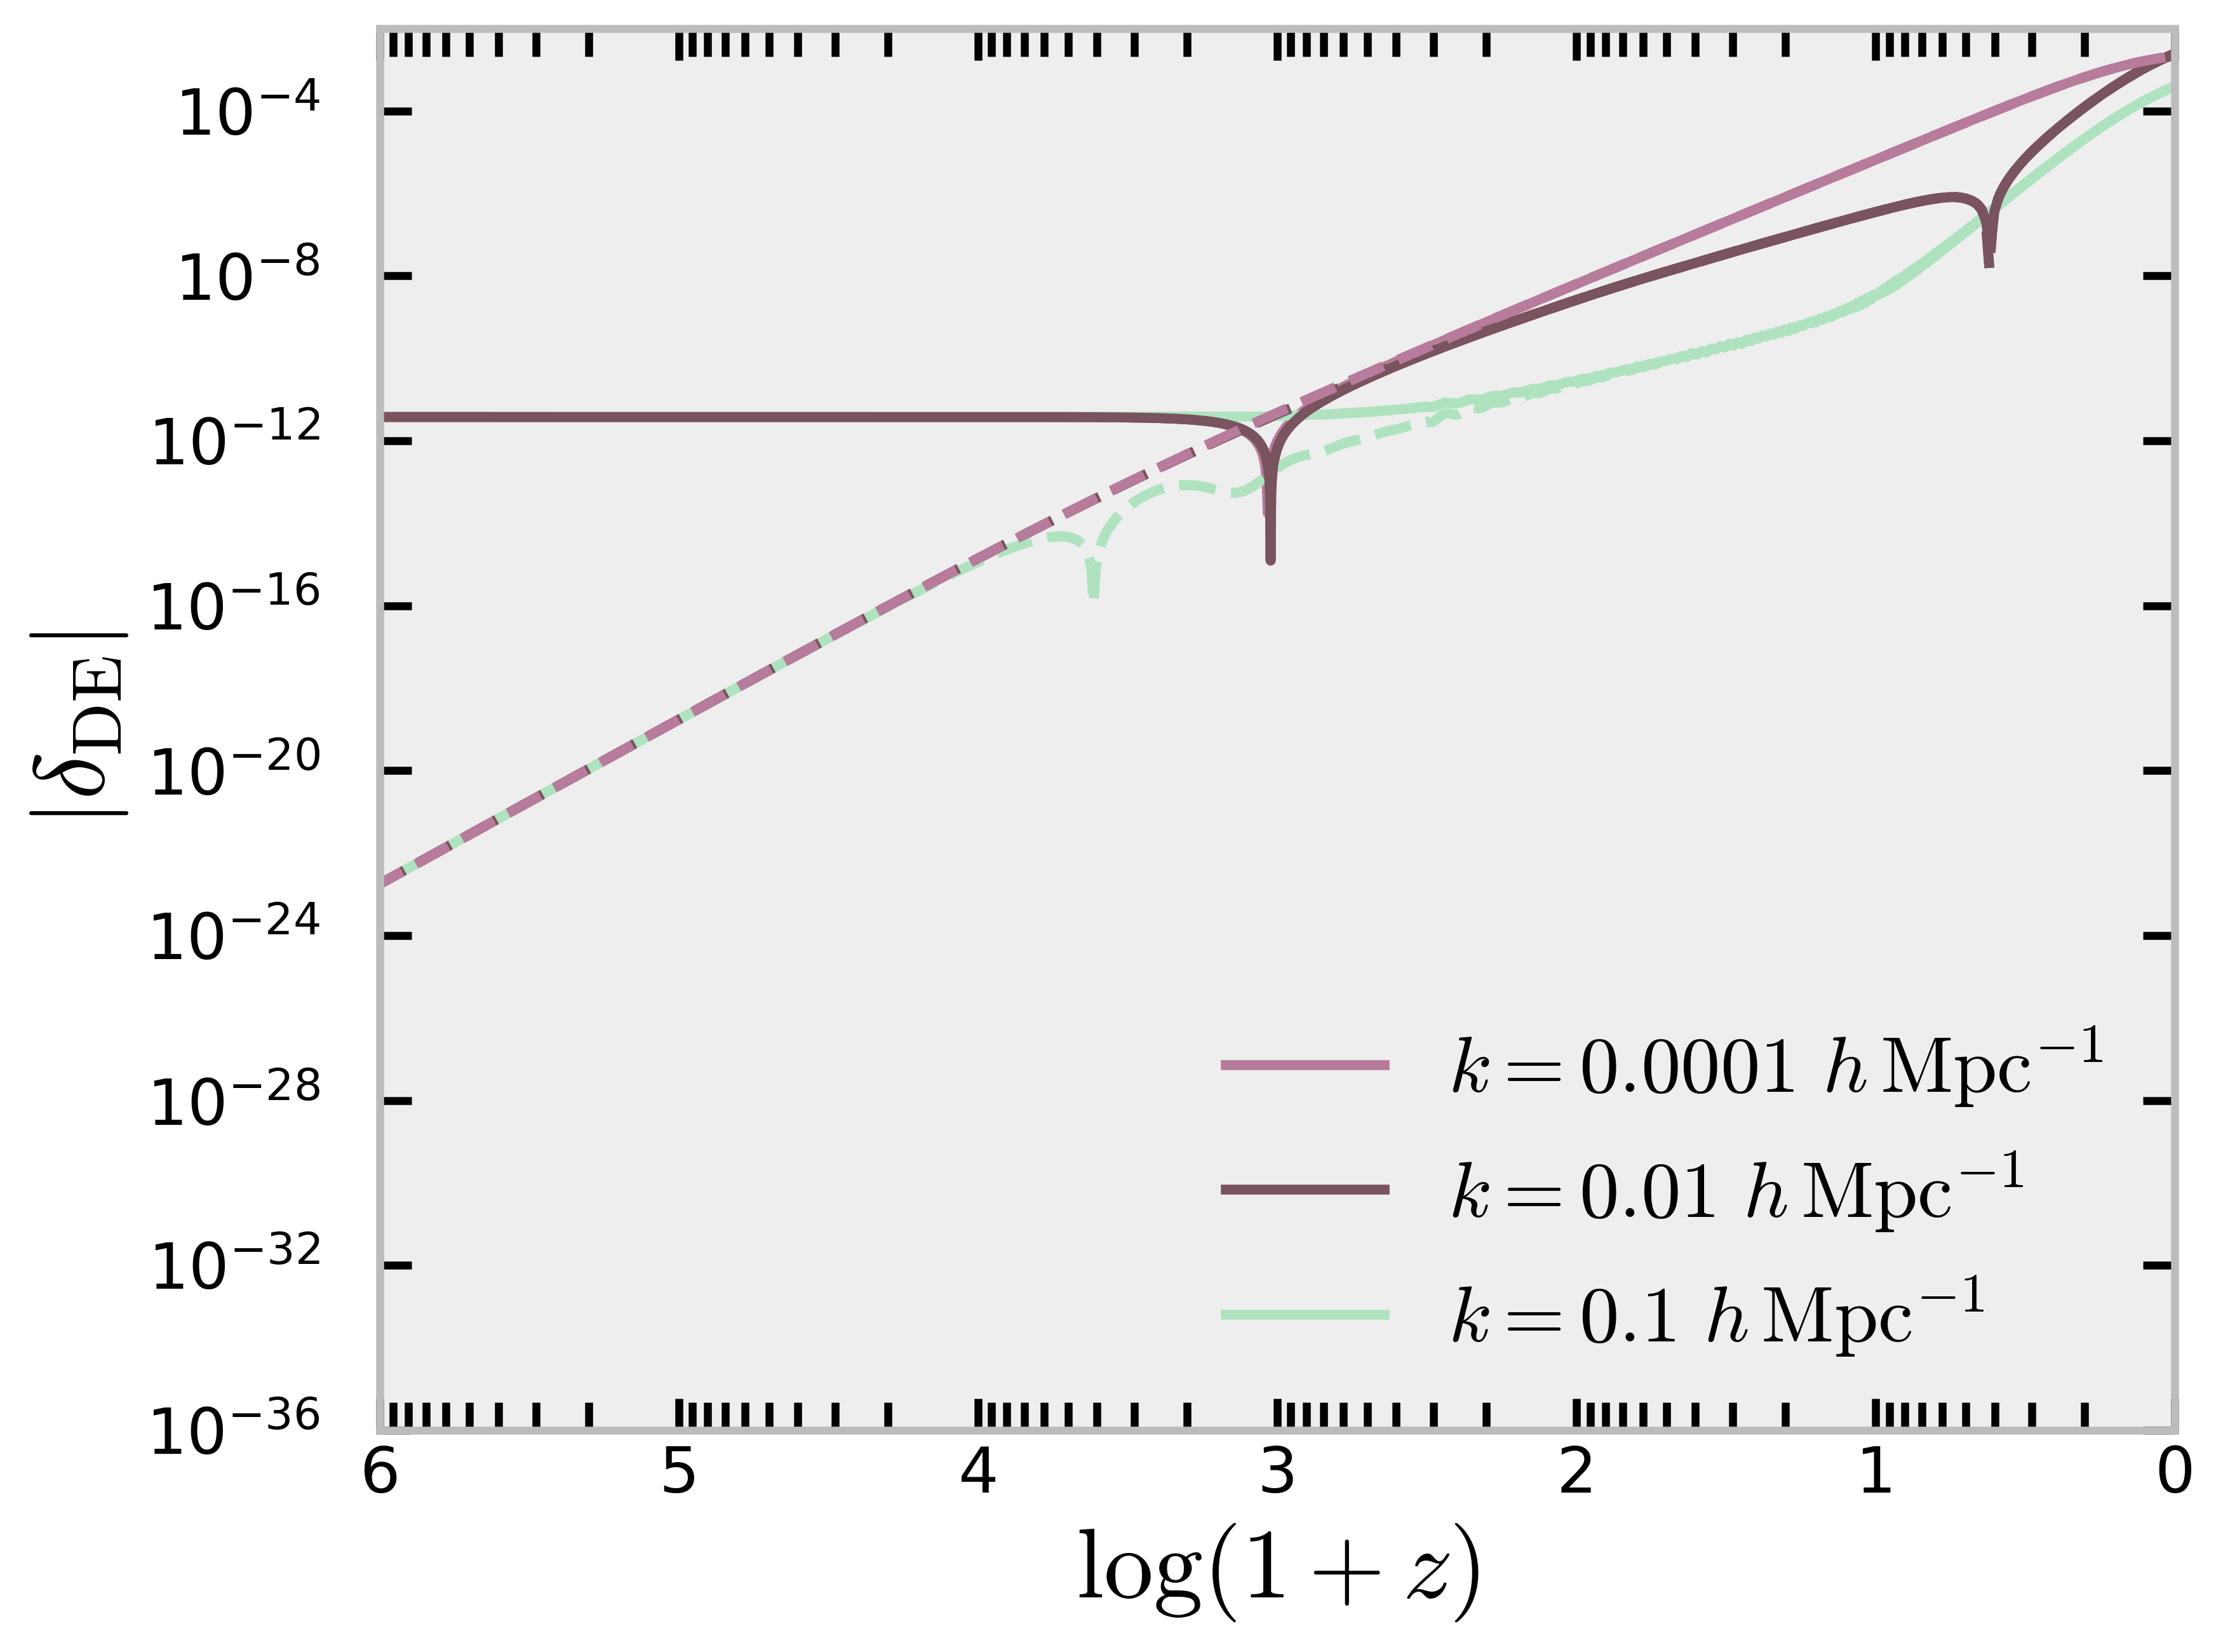

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
# ls = ['-','--','-.', ':', (0,(5,1))]

# def build_interp1d(x, y, kind='cubic', clamp=False):
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y)   # sum y per unique x
#         yu /= cnt               # average duplicates
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# def interp_bg_to_pert(bg, key, a_target, kind='cubic', clamp=False):
#     z_bg = np.asarray(bg['z'])
#     a_bg = 1.0/(1.0 + z_bg)
#     y_bg = np.asarray(bg[key])
#     f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#     return f(a_target)

# def pick_first_key(d, candidates):
#     for k in candidates:
#         if k in d:
#             return k
#     raise KeyError(f"None of the keys found: {candidates}")

# for ik, index_k in enumerate([0, 1, 2]):  # loop over k values
#     color_idx = ik  # color depends on k
#     print(k_sorted[index_k])

#     for ib, index in enumerate([5, 0]):   # loop over beta values
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoPerturb0 = cosmo[0].get_perturbations()
#         cosmoBack = cosmo[index].get_background()

#         pblock = cosmoPerturb['scalar'][index_k]
#         a = pblock['a']                          # perturbation a-grid
#         z = 1/a - 1
#         delta_rho_scf = pblock['delta_rho_scf']
#         delta_phi = pblock['delta_phi_scf']
#         delta_phi_prime = pblock['delta_phi_prime_scf']
#         psi = pblock.get('psi', np.zeros_like(a))
#         Phi = pblock.get('phi', pblock.get('Phi', psi))

#         h0 = h0s[index]
#         delta_s = A0s[index] * (k_sorted[index_k] ** n0s[index])

#         Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
#         Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

#         V_key = pick_first_key(cosmoBack, ["V_scf", "V"])
#         V_on_pert = interp_bg_to_pert(cosmoBack, V_key, a, kind='linear', clamp=True)

#         phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
#         phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

#         f_key = pick_first_key(cosmoBack, ["f_scf", "f"])
#         f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)

#         g_s = f_on_pert
#         delta_rho_DE = (phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert * psi)) / (a**2)
#         delta_rho_DE += delta_phi * Vphi_on_pert + g_s * delta_s

#         # choose the DE background energy density field with fallback
#         bg_de_key = '(.)rho_scf' if '(.)rho_scf' in cosmoBack else '(.)rho_lambda'
#         rho_de_on_pert = interp_bg_to_pert(cosmoBack, bg_de_key, a, kind='linear', clamp=True)

#         # Direct delta_DE definition (to compare with delta_rho_DE/rho_DE)
#         numer = 2.0 * ((a**2) * (delta_phi * Vphi_on_pert + g_s * delta_s) + phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert * psi))
#         denom = 2.0 * (a**2) * rho_de_on_pert
#         eps = 1e-300
#         delta_DE_direct = numer / np.where(np.abs(denom) > eps, denom, np.nan)

#         delta_DE = delta_rho_DE / rho_de_on_pert
#         rel_diff = np.nanmax(np.abs((delta_DE_direct - delta_DE) / np.where(np.abs(delta_DE_direct) > eps, delta_DE_direct, np.nan)))
#         print(f"k={k_sorted[index_k]:.3g} index={index} max rel diff={rel_diff:.3e}")

#         # label only once per k (when ib == 0)
#         label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

#         # If using log y-scale, ensure positivity
#         ax0.plot(1+z, np.abs(delta_DE),
#                  label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])
        

#         # ax0.plot(1+z, 1e-4*pow(1+z,-3),lw=lw/2, ls='-', c='blue')

# # Axes & styling
# ax0.set_xscale('log')
# ax0.set_yscale('log')
# ax0.set_xlabel(r'$\log(1+z)$', size=25)
# ax0.set_ylabel(r'$|\delta_{\rm DE}|$', size=25)

# ax0.set_xlim(1e6, 1)

# #ns-f0 plot 
# # ax0.set_ylim(1e-12, 1e-2)
# # #ns-h0 plot 
# # ax0.set_ylim(1e-24, 1e-2)
# #h0 plot 
# ax0.set_ylim(1e-36, 1e-2)

# ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
# original_labels = ax0.get_xticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_xticklabels(labels)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# fig.tight_layout()
# # plt.savefig('deltade2_ks3_alg_constant.pdf')
# plt.show()


In [16]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
# ls = ['-','--','-.', ':', (0,(5,1))]

# def build_interp1d(x, y, kind='linear', clamp=True):
#     """Return an interp1d callable with sorted, duplicate-free x."""
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y)   # average duplicates
#         yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
#     """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
#     z_bg = np.asarray(bg['z'])
#     a_bg = 1.0/(1.0 + z_bg)
#     y_bg = np.asarray(bg[key])
#     f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#     return f(a_target)

# def pick_first_key(d, candidates):
#     for k in candidates:
#         if k in d:
#             return k
#     raise KeyError(f"None of the keys found: {candidates}")

# for ik, index_k in enumerate([0, 1,2]):  # loop over k values
#     color_idx = ik

#     for ib, index in enumerate([5, 0]):   # loop over beta values
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoBack = cosmo[index].get_background()

#         pblock   = cosmoPerturb['scalar'][index_k]
#         a        = pblock['a']                          # perturbation a-grid
#         z = 1/a - 1
#         delta_rho_scf    = pblock['delta_rho_scf']
#         delta_phi        = pblock['delta_phi_scf']
#         delta_phi_prime  = pblock['delta_phi_prime_scf']
#         psi              = pblock['psi']
#         Phi = pblock.get('phi', pblock.get('Phi', psi))

#         h0 = h0s[index]
#         f0 = f0s[index]
#         delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

#         # --- interpolate background pieces onto pert grid
#         Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
#         Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

#         f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
#         f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)

#         phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
#         phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
#         phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
#         phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

#         H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
#         H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
#         horizon = H_on_pert  # if you decide to plot it

#         # Extract theta_DE (velocity perturbation)
    

#         # term1 = (a*a) * delta_s * (h0*Vphi_on_pert - f0*phi_on_pert)
#         # term2 = phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert*psi)
#         # denom = term1 + term2
#         # eps = 1e-300
#         # cs2_DE = 1.0 - 2.0*term1 / np.where(np.abs(denom) > eps, denom, np.nan)

#         # --- Updated equation for c_s^2_DE
#         # hat{c}_s^2 = 1 - [2 a^2 k^2 delta_s (g_s - h0 V'_phi)] / [a^2 k^2 delta_rho_DE + 3 H_conf phi'^2 theta_DE]
#         k = k_sorted[index_k]
#         H_conformal = a * H_on_pert
#         g_s = f_on_pert  # g_s is the velocity perturbation of the field

#         k_1Mpc = k_sorted[index_k]            # k_sorted is in 1/Mpc (label converts to h/Mpc)

#         theta_DE = (k_1Mpc**2) * (h0*delta_s + delta_phi) / phi_prime_on_pert

#         V_key = pick_first_key(cosmoBack, ["V_scf", "V"])
#         V_on_pert = interp_bg_to_pert(cosmoBack, V_key, a, kind='linear', clamp=True)

#         delta_rho_DE = (phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert * psi)) / (a**2)
#         delta_rho_DE += delta_phi * Vphi_on_pert + g_s * delta_s
        
#         # Numerator: 2 * a^2 * k^2 * delta_s * (g_s - h0 * V'_phi)
#         numerator = 2.0 * (k**2) * delta_s * (g_s - h0 * Vphi_on_pert)
        
#         # Denominator: a^2 * k^2 * delta_rho_scf + 3 * H_conf * phi'^2 * theta_DE
#         term1_denom = (k**2) * delta_rho_DE
#         print(delta_phi_prime)
#         term2_denom = 3.0 * H_conformal * (phi_prime_on_pert**2) * theta_DE/(a**2)
#         denom = term1_denom + term2_denom
        
#         eps = 1e-300
#         cs2_DE = 1.0 - numerator / np.where(np.abs(denom) > eps, denom, np.nan)

#         # label only once per k
#         label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

#         ax0.plot(1+z, cs2_DE, label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])

#         # Optional horizon/k lines:
#         # if ib == 0:
#         #     ax0.plot(a, horizon, lw=lw, ls=':', c=color[color_idx+2])
#         #     ax0.hlines(y=k_sorted[index_k], xmin=a[0], xmax=a[-1], lw=lw, ls='-.', colors=color[color_idx+3])

# # Axes & styling
# ax0.set_xscale('log')
# ax0.set_xlabel(r'$\log(1+z)$', size=25)
# ax0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)

# # #ns-f0 plot 
# # ax0.set_xlim(1e6, 1)
# # ax0.set_ylim(-2.1, 2.1)

# #ns-h0 plot 
# ax0.set_xlim(1e6, 1)
# ax0.set_ylim(-10, 1.6)

# ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20}, ncol=1)
# original_labels = ax0.get_xticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_xticklabels(labels)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# ax0.ticklabel_format(axis='y', style='plain', useOffset=False)

# fig.tight_layout()
# plt.savefig('cs2de2_ks3_alg_constant.pdf')
# plt.show()


In [17]:
# # ============== Plot numerator and denominator components ==============
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# # Pick one case to visualize: k=0, beta=0 and beta=5
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for plot_idx, index in enumerate([5, 0]):  # Two beta values: 5 and 0
#     ax = axes[plot_idx]
    
#     # k index
#     index_k = 0
    
#     cosmoPerturb = cosmo[index].get_perturbations()
#     cosmoBack = cosmo[index].get_background()
    
#     pblock = cosmoPerturb['scalar'][index_k]
#     a = pblock['a']
#     z = 1/a - 1
#     delta_phi = pblock['delta_phi_scf']
#     delta_phi_prime = pblock['delta_phi_prime_scf']
#     psi = pblock['psi']
#     Phi = pblock.get('phi', pblock.get('Phi', psi))
    
#     h0 = h0s[index]
#     delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])
#     k = k_sorted[index_k]
    
#     # Helper functions
#     def build_interp1d(x, y, kind='linear', clamp=True):
#         x = np.asarray(x); y = np.asarray(y)
#         order = np.argsort(x)
#         x = x[order]; y = y[order]
#         xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#         if np.any(cnt > 1):
#             yu = np.zeros_like(xu, dtype=float)
#             np.add.at(yu, inv, y); yu /= cnt
#         else:
#             yu = y
#         fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#         return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)
    
#     def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
#         z_bg = np.asarray(bg['z'])
#         a_bg = 1.0/(1.0 + z_bg)
#         y_bg = np.asarray(bg[key])
#         f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#         return f(a_target)
    
#     def pick_first_key(d, candidates):
#         for k_cand in candidates:
#             if k_cand in d: return k_cand
#         raise KeyError(f"None of the keys found: {candidates}")
    
#     # Interpolate background quantities
#     Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
#     Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)
    
#     f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
#     f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)
    
#     phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
#     phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)
    
#     H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
#     H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
    
#     # Compute intermediate terms
#     H_conformal = a * H_on_pert
#     g_s = f_on_pert
#     theta_DE = (k**2) * (h0*delta_s + delta_phi) / phi_prime_on_pert
    
#     delta_rho_DE = (phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert * Phi)) / (a**2)
#     delta_rho_DE += delta_phi * Vphi_on_pert + g_s * delta_s
    
#     # Numerator and denominator terms
#     numerator = 2.0 * (k**2) * delta_s * (g_s - h0 * Vphi_on_pert)
#     term1_denom = (k**2) * delta_rho_DE
#     term2_denom = 3.0 * H_conformal * (phi_prime_on_pert**2) * theta_DE/(a**2)
#     denom = term1_denom + term2_denom
    
#     # Plot on log scale
#     beta_label = r'$\beta_0 = 0.5$' if index == 5 else r'$\beta_0 = 0$'
#     ax.semilogy(1+z, np.abs(numerator), 'o-', label='|numerator|', linewidth=2, markersize=3, alpha=0.7)
#     ax.semilogy(1+z, np.abs(term1_denom), 's-', label='|term1_denom|', linewidth=2, markersize=3, alpha=0.7)
#     ax.semilogy(1+z, np.abs(term2_denom), '^-', label='|term2_denom|', linewidth=2, markersize=3, alpha=0.7)
#     ax.semilogy(1+z, np.abs(denom), 'D-', label='|denom| (sum)', linewidth=2.5, markersize=4, alpha=0.9)
    
#     ax.set_xscale('log')
#     ax.set_xlabel(r'$1+z$', fontsize=14)
#     ax.set_ylabel('Magnitude', fontsize=14)
#     ax.set_title(f'{beta_label}, $k = {k:.3e}$ Mpc$^{{-1}}$', fontsize=14)
#     ax.legend(fontsize=11, loc='best')
#     ax.grid(True, alpha=0.3, which='both')

# plt.tight_layout()
# plt.savefig('numerator_denominator_components.pdf', dpi=150)
# plt.show()

# print(f"\nNumerator range: [{np.min(np.abs(numerator)):.3e}, {np.max(np.abs(numerator)):.3e}]")
# print(f"Term1_denom range: [{np.min(np.abs(term1_denom)):.3e}, {np.max(np.abs(term1_denom)):.3e}]")
# print(f"Term2_denom range: [{np.min(np.abs(term2_denom)):.3e}, {np.max(np.abs(term2_denom)):.3e}]")
# print(f"Denom range: [{np.min(np.abs(denom)):.3e}, {np.max(np.abs(denom)):.3e}]")
# print(f"\nRatio |denom|/|numerator|: [{np.min(np.abs(denom)/np.maximum(np.abs(numerator), 1e-100)):.3e}, {np.max(np.abs(denom)/np.maximum(np.abs(numerator), 1e-100)):.3e}]")


In [18]:
# #print(k_sorted)
# index_k_list = [0]
# label = [r'$\theta_c$','','','','']

# lw = 2.5
# ls = ['--','-','-.', ':', '-']
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# fig = plt.figure(figsize=(8,6))
# ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
# ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

# plt.subplots_adjust(hspace=0,wspace=0.)

# def interp_monotonic(x, y, kind='linear', clamp=True):
#     x = np.asarray(x); y = np.asarray(y)
#     o = np.argsort(x); x=x[o]; y=y[o]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt>1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y); yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# # --- choose mode and build reference interpolator once ---
# index_k = 0
# print(k_sorted[index_k])
# std = standard.get_perturbations()['scalar'][index_k]
# a0 = std['a']
# z0 = 1/a0 - 1
# theta0 = std['theta_cdm']

# # plot the reference on its own grid
# ax0.plot(1+z0, theta0, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1.5)

# # interpolator θ_c^ref(a)
# f_theta0 = interp_monotonic(a0, theta0, kind='linear', clamp=True)

# # --- loop over models and compare to reference on the SAME grid ---
# runs = [0,1,2,3,4]
# for j, index in enumerate(runs):
#     blk = cosmo[index].get_perturbations()['scalar'][index_k]
#     a   = blk['a']
#     z   = 1/a - 1
#     th  = blk['theta_edm']

#     # reference evaluated on THIS grid -> shapes match
#     theta0_on_a = f_theta0(a)

#     # styles/colors (robust cycling)
#     ls_j    = ls[j % len(ls)]
#     color_j = color[j % len(color)]
#     label_j = rf'$g_0 = {f0s[index]:.3f}$' if index < len(n0s) else rf'$i={index}$'

#     # top panel
#     ax0.plot(1+z, th, label=label_j, lw=lw, ls=ls_j, c=color_j)

#     # bottom panel: percent difference with divide-by-zero guard
#     eps   = 1e-300
#     denom = np.where(np.abs(theta0_on_a) > eps, theta0_on_a, np.nan)
#     rel   = 100.0 * (th - theta0_on_a) / denom
#     ax1.plot(1+z, rel, lw=lw, ls=ls_j, c=color_j)
#     #ax0.plot(1+z, np.abs(cosmoPerturb['scalar'][index_k]['delta_rho_scf'])*1e-4, c='k', ls='-', label = r'$\delta {\phi}$',lw=1.5)
#     ax0.set_xticklabels([-1,0,1,2,3])

#     ax0.set_ylabel(label[index], size=25)
#     ax1.set_xlabel(r'$1+z$', size=25)
#     #ax0.set_xlim(1e5,1)
#     # ax0.set_ylim(1e-3,1)
#     #ax0.set_title('k = '+str(k_sorted[index_k]), size=20)
#     ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
#     for tick in ax0.xaxis.get_major_ticks():
#         tick.set_pad(10)
#     for tick in ax0.yaxis.get_major_ticks():
#         tick.set_pad(10)    


# ax0.set_xscale('linear');ax0.set_yscale('linear')
# ax1.set_xscale('linear');ax1.set_yscale('linear')

# ax0.set_ylabel(r'$\theta_{\rm c}$', size=25,labelpad=30)
# ax1.set_ylabel(r'$ \frac{\Delta \theta_{\rm c}}{\theta_{\rm c}}\, [\%]$', size=25,labelpad=10)

# # #ns-f0 plot 
# # ax0.set_ylim(0., 2.2)
# # ax1.set_xlim(3,1)
# # ax0.set_ylim([0.6,1.4])
# # ax1.set_ylim(-70,10)

# #h0 plot 
# # ax0.set_ylim(0., 2.1)
# ax1.set_xlim(3,1)
# # ax1.set_ylim(-90,90)

# ax1.set_yticks([i for i in np.linspace(-60,60,3)])
# ax1.set_xticks([i for i in np.linspace(3,1,5)])

    
# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# # ax0.set_xscale('log')
# # #ax0.set_yscale('log')
# # original_labels = ax0.get_xticks()
# # labels = []
# # for label in original_labels:
# #     labels.append(int(np.log10(label)))
# # ax0.set_xticklabels(labels)

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )
# ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
# #ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format
# ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

# ax0.legend(loc='lower left', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=1,bbox_to_anchor=(0.0, -0.05))
# plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 20
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# plt.savefig('thetac_alg_constant.pdf')
# #, transparent=True)
# plt.show()


1.35112
0.0
theta0 0.0
theta0 -3.955128399252291
theta0 -11.865385197739498
theta0 7.910256798491153
theta0 15.820513597021566


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


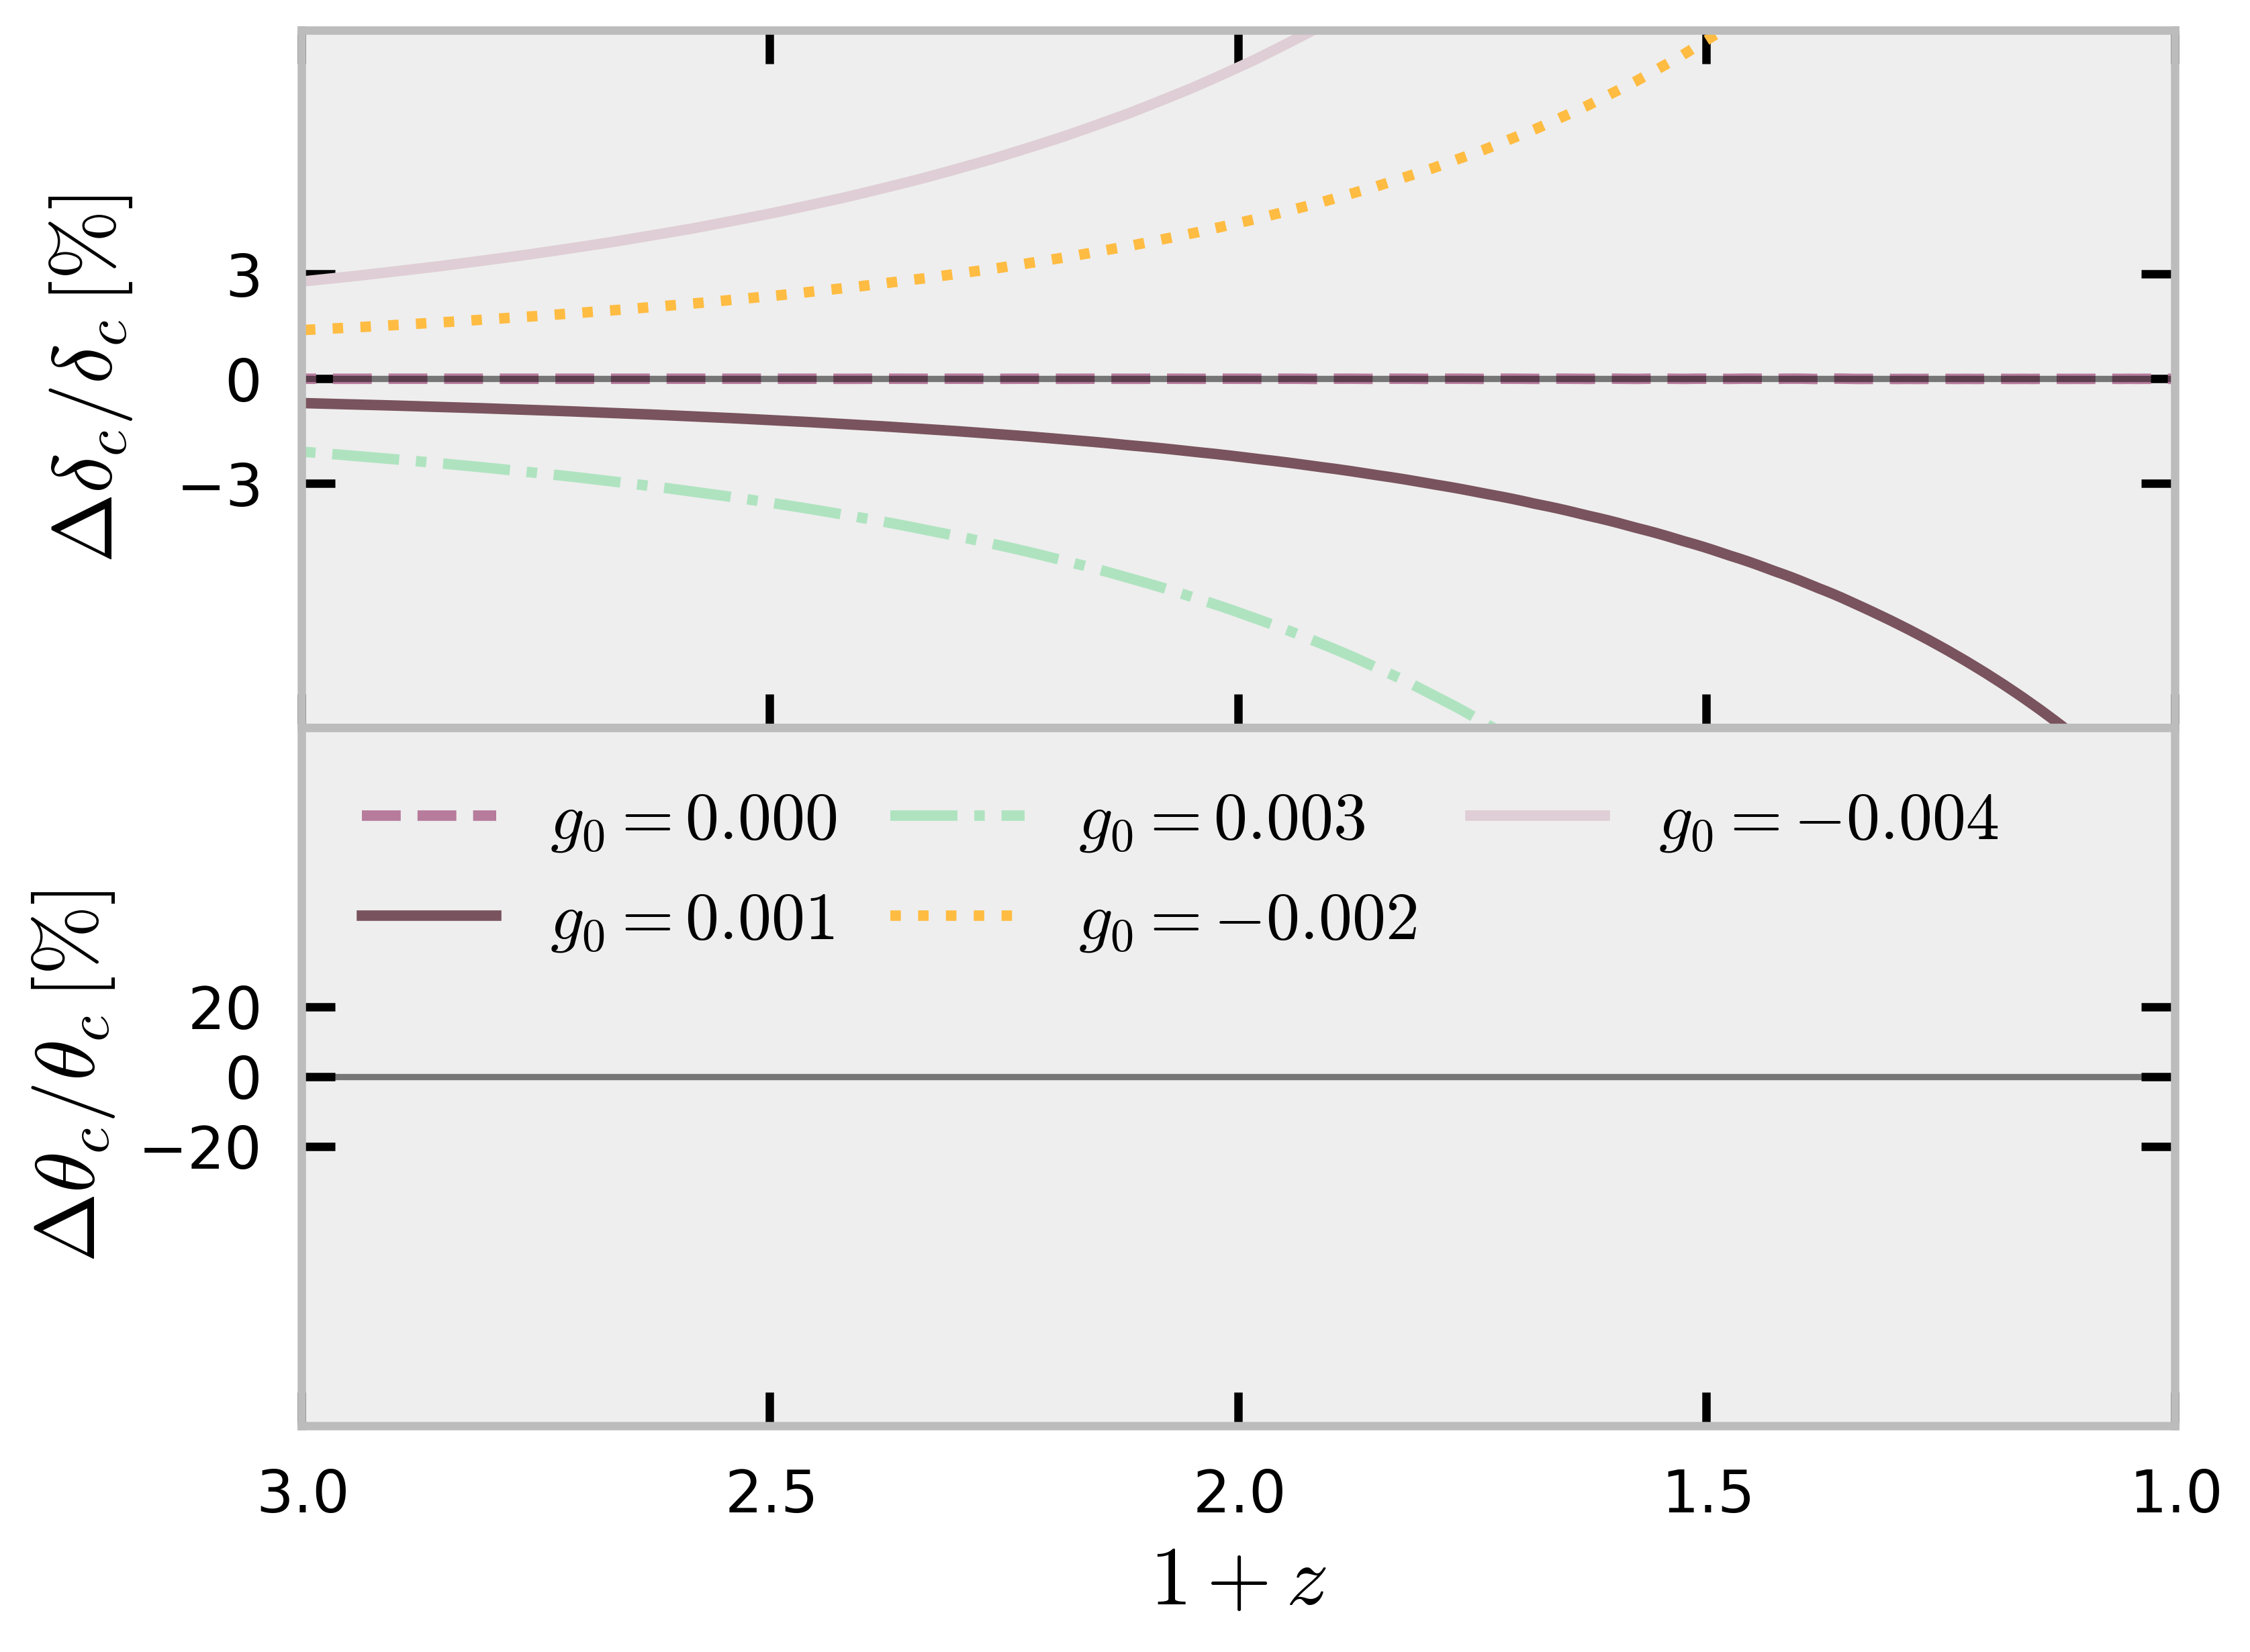

In [19]:
# Two-panel plot: Relative differences for delta_c and theta_c
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((2,1),(0,0), rowspan=1)
ax1 = plt.subplot2grid((2,1),(1,0), rowspan=1,sharex = ax0)

# Helper function for interpolation
def interp_monotonic(x, y, kind='linear', clamp=True):
    x = np.asarray(x); y = np.asarray(y)
    o = np.argsort(x); x=x[o]; y=y[o]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt>1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y); yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# ========== Panel 1: delta_c relative differences ==========
index_k = 6
print(k_sorted[index_k])
standardPerturb = standard.get_perturbations()
a0 = standardPerturb['scalar'][index_k]['a']
z0 = 1/a0 - 1
delta_c0 = standardPerturb['scalar'][index_k]['delta_cdm']
f_delta0_of_a = interp_monotonic(a0, delta_c0, kind='linear', clamp=True)

for index in [0,1,2,3,4]:
    cosmoPerturb = cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z = 1/a - 1
    delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']
    delta_c0_on_a = f_delta0_of_a(a)
    
    eps = 1e-300
    denom = np.where(np.abs(delta_c0_on_a) > eps, delta_c0_on_a, np.nan)
    rel = 100.0 * (delta_c - delta_c0_on_a) / denom
    
    ax0.plot(1+z, rel, label=rf'$g_0 = {f0s[index]:.3f}$', 
             lw=lw, ls=ls[index], c=color[index])

ax0.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax0.set_xscale('linear')
ax0.set_yscale('linear')
ax0.set_ylabel(r'$\Delta \delta_c/\delta_c\, [\%]$', size=20, labelpad=10)
ax0.ticklabel_format(axis='y', style='plain')
ax0.tick_params(axis='both', which='both', labelsize=14)
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
plt.setp(ax0.get_xticklabels(), visible=False)

# ========== Panel 2: theta_c relative differences ==========
index_k = 6
std = standard.get_perturbations()['scalar'][index_k]
a0 = std['a']
z0 = 1/a0 - 1
theta0 = std['theta_cdm']
print(theta0[-1])
f_theta0 = interp_monotonic(a0, theta0, kind='linear', clamp=True)

for index in [0,1,2,3,4]:
    blk = cosmo[index].get_perturbations()['scalar'][index_k]
    a = blk['a']
    z = 1/a - 1
    th = blk['theta_edm']
    print('theta0',th[-1])
    theta0_on_a = f_theta0(a)
    
    eps = 1e-300
    denom = np.where(np.abs(theta0_on_a) > eps, theta0_on_a, np.nan)
    rel = 100.0 * (th - theta0_on_a) / denom
    
    ax1.plot(1+z, rel, label=rf'$g_0 = {f0s[index]:.3f}$', 
             lw=lw, ls=ls[index], c=color[index])

ax1.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax1.set_xscale('linear')
ax1.set_yscale('linear')
ax1.set_xlim(3, 1)
ax1.set_xticks([i for i in np.linspace(3,1,5)])
ax1.set_ylim(-100, 100)
ax1.set_yticks([i for i in np.linspace(-20,20,3)])
ax0.set_ylim(-10, 10)
ax0.set_yticks([i for i in np.linspace(-3,3,3)])

ax1.set_xlabel(r'$1+z$', size=20)
ax1.set_ylabel(r'$\Delta \theta_c/\theta_c\, [\%]$', size=20, labelpad=5)
ax1.ticklabel_format(axis='y', style='plain')
ax1.tick_params(axis='x', which='both', top=False, labelsize=14)
ax1.tick_params(axis='y', which='both', labelsize=14)
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
ax1.legend(loc='upper left', frameon=False, prop={'size': 16}, ncol=3, columnspacing=0.8)

# Adjust tick padding for both panels
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(10)

plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig('delta_theta_rel_diff_alg_constant.pdf', transparent=True)
plt.show()


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


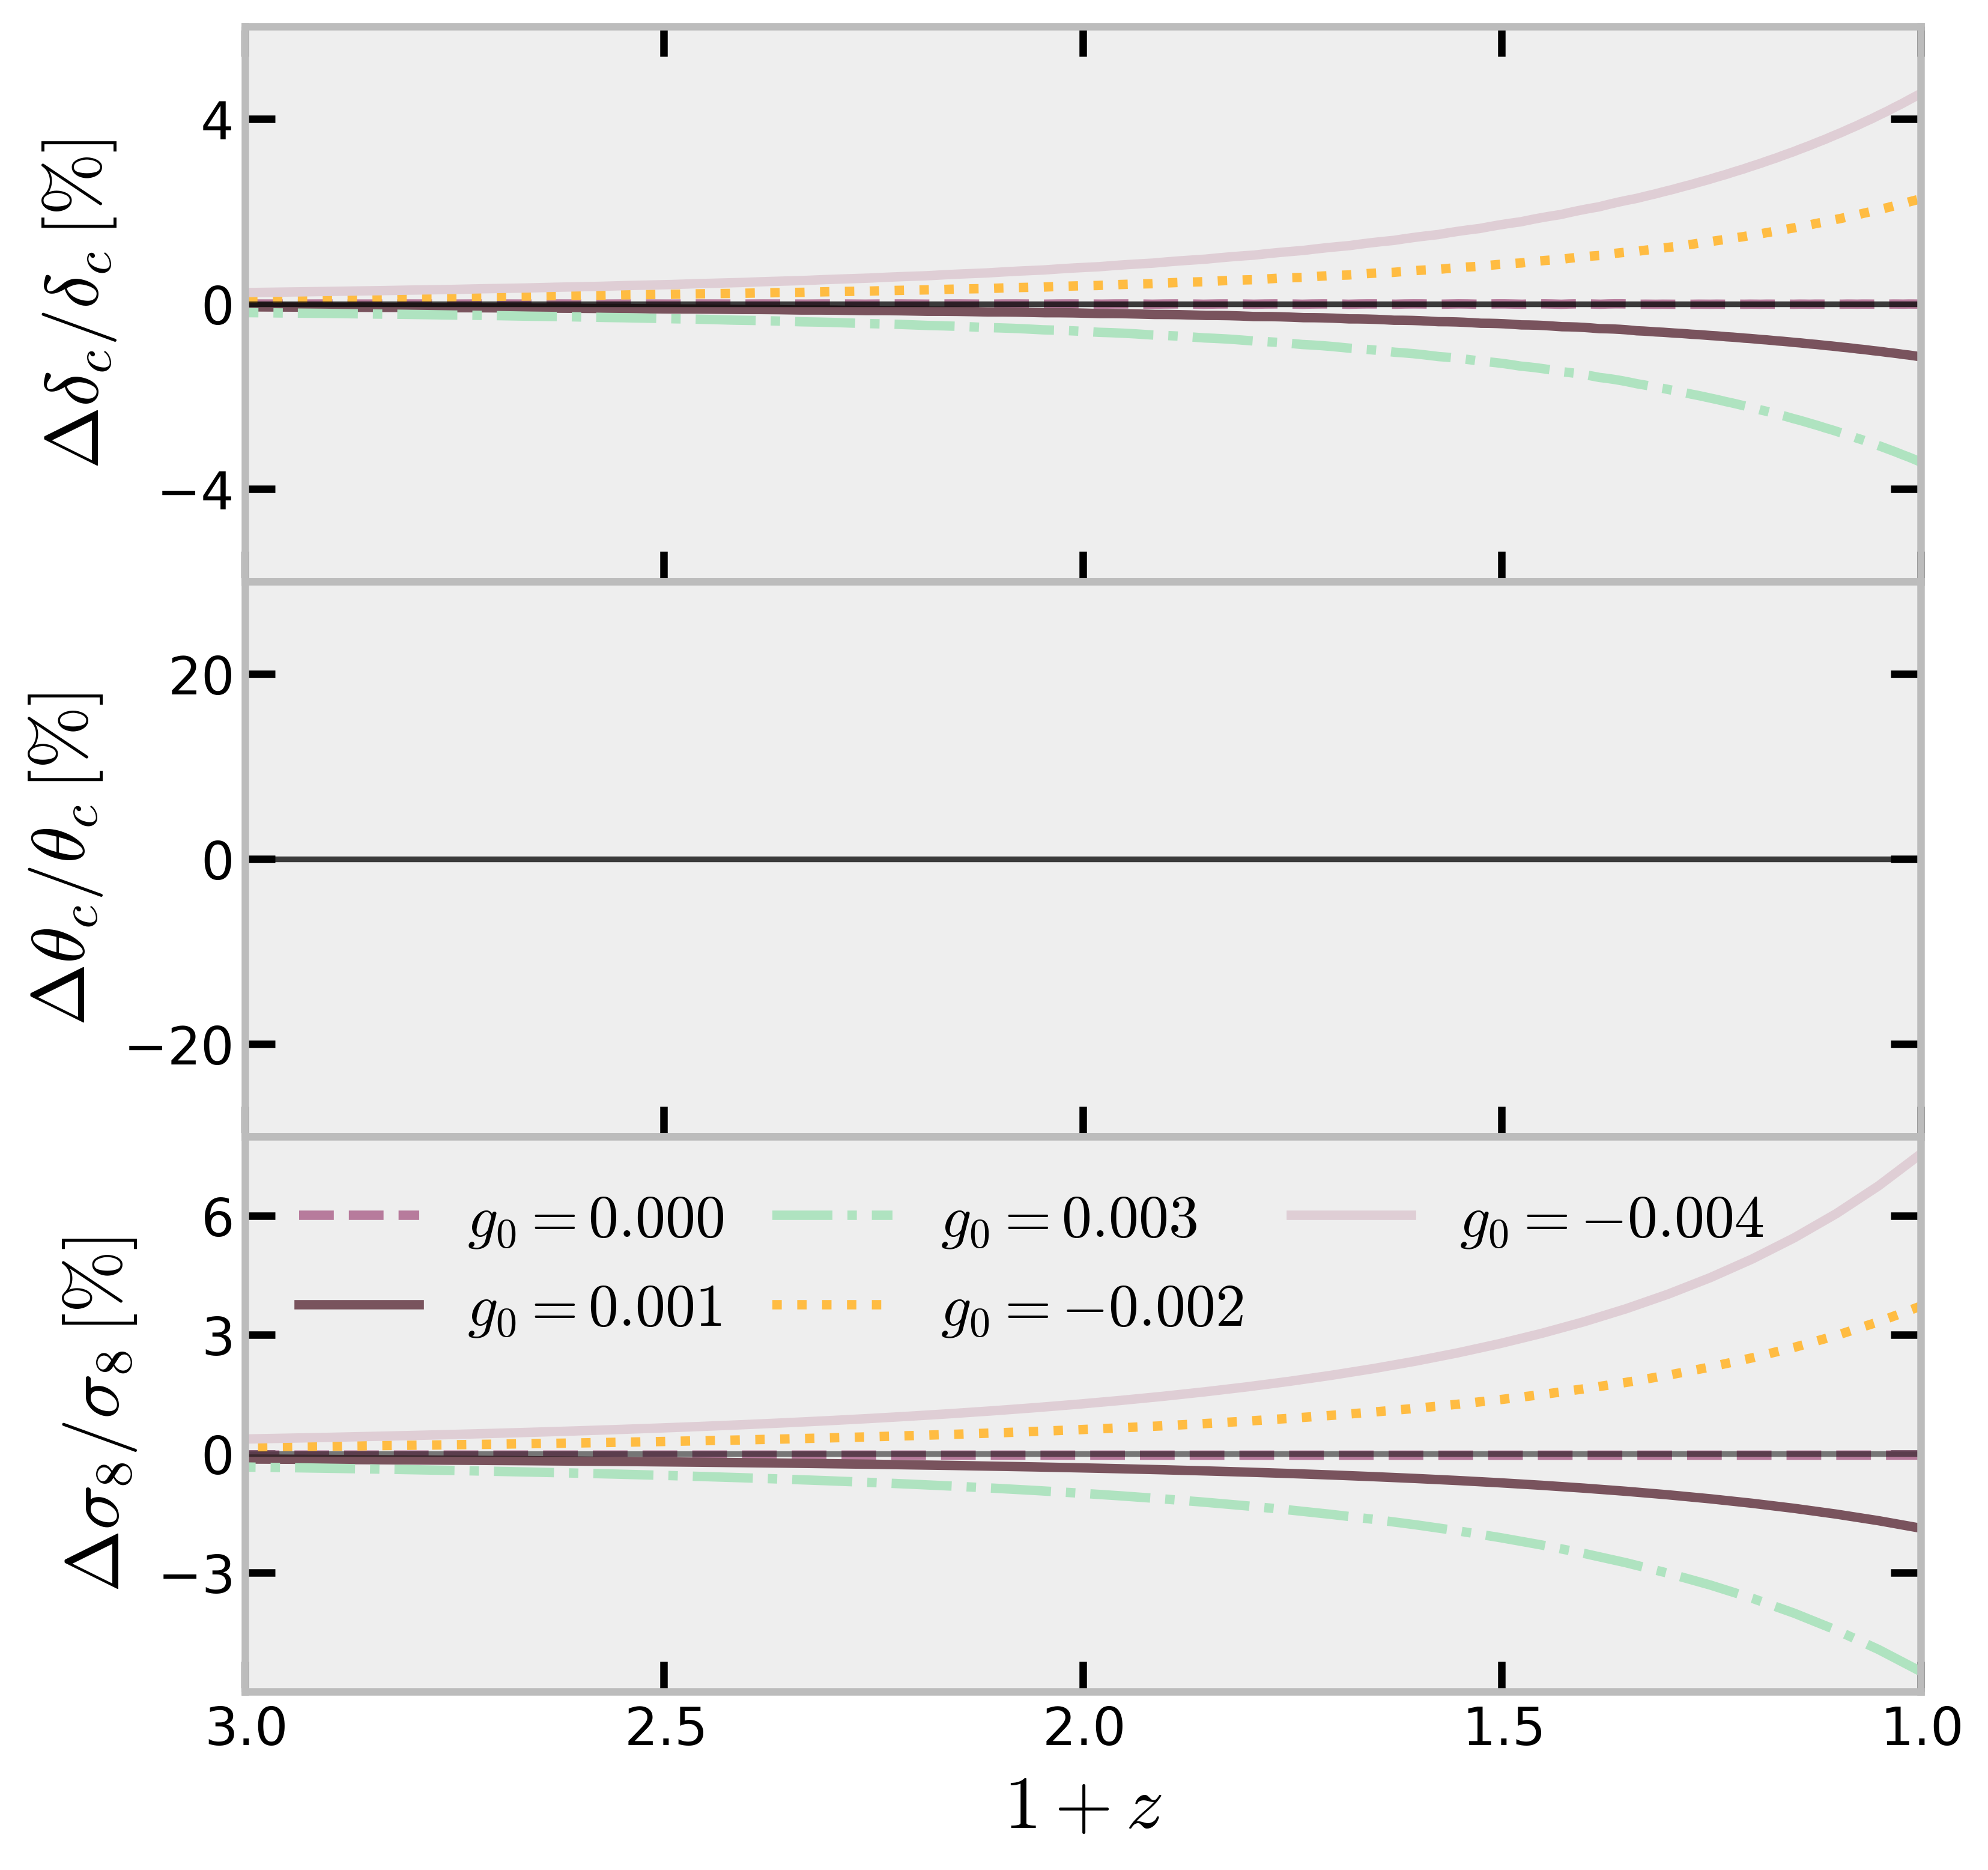

In [20]:
# Three-panel plot: delta_c, theta_c, and sigma8 relative differences
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])
lw = 2.5
ls = ['--','-','-.', ':', '-']
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]})

# Panel 1: delta_c relative difference
index_k = 3
standardPerturb = standard.get_perturbations()
a0 = standardPerturb['scalar'][index_k]['a']
z0 = 1/a0 - 1
delta_c0 = standardPerturb['scalar'][index_k]['delta_cdm']
def interp_monotonic(x, y, kind='linear', clamp=True):
    x = np.asarray(x); y = np.asarray(y)
    o = np.argsort(x); x=x[o]; y=y[o]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt>1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y); yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)
f_delta0_of_a = interp_monotonic(a0, delta_c0, kind='linear', clamp=True)
for index in [0,1,2,3,4]:
    cosmoPerturb = cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z = 1/a - 1
    delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']
    delta_c0_on_a = f_delta0_of_a(a)
    eps = 1e-300
    denom = np.where(np.abs(delta_c0_on_a) > eps, delta_c0_on_a, np.nan)
    rel = 100.0 * (delta_c - delta_c0_on_a) / denom
    ax0.plot(1+z, rel, label=rf'$g_0 = {f0s[index]:.3f}$', lw=lw, ls=ls[index], c=color[index])

# Panel 2: theta_c relative difference (always use theta_cdm for both standard and models)
std = standard.get_perturbations()['scalar'][index_k]
a0 = std['a']
theta0 = std['theta_cdm']
f_theta0 = interp_monotonic(a0, theta0, kind='linear', clamp=True)
for index in [0,1,2,3,4]:
    blk = cosmo[index].get_perturbations()['scalar'][index_k]
    a = blk['a']
    z = 1/a - 1
    th = blk['theta_edm']
    theta0_on_a = f_theta0(a)
    eps = 1e-300
    denom = np.where(np.abs(theta0_on_a) > eps, theta0_on_a, np.nan)
    rel = 100.0 * (th - theta0_on_a) / denom
    ax1.plot(1+z, rel, label=rf'$g_0 = {f0s[index]:.3f}$', lw=lw, ls=ls[index], c=color[index])
ax1.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax1.set_ylabel(r'$\Delta \theta_c/\theta_c\, [\%]$', size=16, labelpad=5)
ax1.set_ylim(-20, 20)
ax1.set_yticks([i for i in np.linspace(-15,15,3)])
ax1.tick_params(axis='both', which='both', labelsize=12)
plt.setp(ax1.get_xticklabels(), visible=False)

# Panel 3: sigma8 ratio (as in s8_alg_constant_ratio)
s8_std = float(standard.sigma8())
z_grid = np.linspace(1, 11, 200) 
z_grid2 = np.linspace(0, 10, 200) 
R8 = 8.0/cosmo[index].h()
R80 = 8.0/standard.h()
for index in [0,1,2,3,4]:
    s8_z = np.array([cosmo[index].sigma(R8, z) for z in z_grid2])
    s8_std_z = np.array([standard.sigma(R80,z) for z in z_grid2])
    denom = np.where(np.abs(s8_std_z) > eps, s8_std_z, np.nan)
    rel = 100.0 * (s8_z - s8_std_z) / denom
    ax2.plot(z_grid, rel, label=rf'$g_0 = {f0s[index]:.3f}$', lw=lw, ls=ls[index], c=color[index])

ax0.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax0.set_ylabel(r'$\Delta \delta_c/\delta_c\, [\%]$', size=16, labelpad=10)
ax0.tick_params(axis='both', which='both', labelsize=12)
plt.setp(ax0.get_xticklabels(), visible=False)

ax0.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax0.set_xscale('linear')
ax0.set_yscale('linear')
ax0.set_ylim(-6, 6)
ax0.set_yticks([i for i in np.linspace(-4,4,3)])
ax0.set_ylabel(r'$\Delta \delta_c/\delta_c\, [\%]$', size=20, labelpad=10)
ax0.ticklabel_format(axis='y', style='plain')
ax0.tick_params(axis='both', which='both', labelsize=14)
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=True)
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=True)
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
plt.setp(ax0.get_xticklabels(), visible=False)
  
ax1.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax1.set_xscale('linear')
ax1.set_yscale('linear')
ax1.set_xlim(3, 1)
ax1.set_xticks([i for i in np.linspace(3,1,5)])
ax1.set_ylim(-30, 30)
ax1.set_yticks([i for i in np.linspace(-20,20,3)])

ax2.set_xlabel(r'$1+z$', size=20)
ax1.set_ylabel(r'$\Delta \theta_c/\theta_c\, [\%]$', size=20, labelpad=5)
ax1.ticklabel_format(axis='y', style='plain')
ax1.tick_params(axis='x', which='both', top=False, labelsize=14)
ax1.tick_params(axis='y', which='both', labelsize=14)
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
ax2.legend(loc='upper left', frameon=False, prop={'size': 16}, ncol=3, columnspacing=0.8)
plt.setp(ax1.get_xticklabels(), visible=False)
ax2.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax2.set_ylabel(r'$\Delta\sigma_8/\sigma_8\, [\%]$', size=20, labelpad=5)
ax2.set_ylim(-6, 8)
ax2.set_yticks([i for i in np.linspace(-3,6,4)])
ax2.tick_params(axis='both', which='both', labelsize=12)
ax2.set_xlim(3, 1)
ax2.ticklabel_format(axis='y', style='plain')
ax2.tick_params(axis='x', which='both', top=False, labelsize=14)
ax2.tick_params(axis='y', which='both', labelsize=14)
ax2.xaxis.set_tick_params(which='major', size=8, width=2, direction='in')
ax2.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in')
ax2.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax2.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)

fig.subplots_adjust(hspace=0)
# fig.tight_layout()
# ax0.legend(loc='upper left', frameon=False, prop={'size': 12}, ncol=2, columnspacing=0.8)
plt.savefig('delta_theta_s8_rel_diff_alg_constant.pdf', transparent=True)
plt.show()


In [21]:
# # Transfer function for $|\delta_{DE}|^2$, normalized to uncoupled case (cosmo[0])
# plt.figure(figsize=(8,6))
# lw = 2.5
# ls = ['--','-','-.', ':', '-']

# def get_delta_DE_today(cosmo_model, ik):
#     cosmoPerturb = cosmo_model.get_perturbations()
#     pblock = cosmoPerturb['scalar'][ik]
#     a = pblock['a']
#     idx_today = np.argmin(np.abs(a - 1.0))
#     delta_DE = pblock['delta_phi_scf'][idx_today] if 'delta_phi_scf' in pblock else np.nan
#     return delta_DE

# # Uncoupled reference: cosmo[0]
# lcdm_deltaDE_today = [get_delta_DE_today(cosmo[0], ik) for ik in range(n_modes)]

# for idx, model in enumerate(cosmo[:5]):
#     model_deltaDE_today = [get_delta_DE_today(model, ik) for ik in range(n_modes)]
#     # Use the minimum length to avoid mismatch
#     min_len = min(len(k_sorted), len(model_deltaDE_today), len(lcdm_deltaDE_today))
#     ratio = (np.abs(model_deltaDE_today[:min_len])**2) / (np.abs(lcdm_deltaDE_today[:min_len])**2)
#     plt.plot(k_sorted[:min_len], ratio, label=rf'$h_0 = {h0s[idx]:.2f}$', lw=lw, ls=ls[idx], c=color[idx])

# plt.axhline(1, color='k', ls=':', lw=1.5, alpha=0.5)
# plt.xscale('log')
# plt.xlabel(r'$k$ [1/Mpc]', size=20)
# plt.ylabel(r'$|\delta_{DE}|^2/|\delta_{DE}^{\mathrm{uncoupled}}|^2$', size=20)
# plt.title(r'Transfer function for $|\delta_{DE}|^2$ at $z=0$')
# plt.legend(loc='best', frameon=False, prop={'size': 16})
# plt.tight_layout()
# plt.savefig('delta_tf_de_alg_constant.pdf', transparent=True)
# plt.show()

In [22]:
# # Plot: |delta_edm|^2 / |delta_DE|^2 for all models at z=0
# plt.figure(figsize=(8,6))
# lw = 2.5
# ls = ['--','-','-.', ':', '-']

# def get_delta_DE_today(cosmo_model, ik):
#     cosmoPerturb = cosmo_model.get_perturbations()
#     pblock = cosmoPerturb['scalar'][ik]
#     a = pblock['a']
#     idx_today = np.argmin(np.abs(a - 1.0))
#     delta_DE = pblock['delta_phi_scf'][idx_today] if 'delta_phi_scf' in pblock else np.nan
#     return delta_DE

# # Reference: uncoupled case (cosmo[0])
# n_modes0 = len(cosmo[0].get_perturbations()['scalar'])
# min_len0 = min(len(k_sorted), n_modes0)
# delta_edm_uncoupled = [cosmo[0].get_perturbations()['scalar'][ik]['delta_edm'][-1] for ik in range(min_len0)]
# delta_DE_uncoupled = [get_delta_DE_today(cosmo[0], ik) for ik in range(min_len0)]

# for idx, index in enumerate([0,1,2,3,4]):
#     cosmoPerturb = cosmo[index].get_perturbations()
#     n_modes_model = len(cosmoPerturb['scalar'])
#     min_len = min(len(k_sorted), n_modes_model)
#     delta_edm_today = [cosmoPerturb['scalar'][ik]['delta_edm'][-1] for ik in range(min_len)]
#     delta_DE_today = [get_delta_DE_today(cosmo[index], ik) for ik in range(min_len)]
#     ratio_delta = (np.abs(delta_edm_today)**2) / (np.abs(delta_DE_today)**2)
#     plt.plot(k_sorted[:min_len], 1/ratio_delta, label=rf'$h_0={h0s[index]:.2f}$', lw=lw, ls=ls[idx], c=color[idx])

# plt.xscale('log')
# plt.xlabel(r'$k$ [1/Mpc]', size=20)
# plt.ylabel(r'$|\delta_{DE}|^2/|\delta_\mathrm{edm}|^2$', size=20)
# plt.title(r'$|\delta_{DE}|^2/|\delta_\mathrm{edm}|^2$ at $z=0$')
# plt.legend(loc='best', frameon=False, prop={'size': 14})
# plt.tight_layout()
# plt.savefig('delta_de_dm_alg_constant.pdf', transparent=True)
# plt.show()

# # Plot: |(rho_edm+p_edm)theta_edm|^2 / |(rho_DE+p_DE)theta_DE|^2 for all models at z=0
# plt.figure(figsize=(8,6))

# def get_rhop_theta_DE_today(cosmo_model, cosmoBack, ik, h0, A0, n0):
#     cosmoPerturb = cosmo_model.get_perturbations()
#     pblock = cosmoPerturb['scalar'][ik]
#     a = pblock['a']
#     idx_today = np.argmin(np.abs(a - 1.0))
#     delta_phi = pblock['delta_phi_scf'][idx_today] if 'delta_phi_scf' in pblock else np.nan
#     phi_prime_key = ["phi'_scf", 'phi_prime_scf']
#     phi_prime_key_actual = None
#     for k in phi_prime_key:
#         if k in cosmoBack:
#             phi_prime_key_actual = k
#             break
#     phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key_actual, a, kind='linear', clamp=True)[idx_today]
#     delta_s = A0 * pow(k_sorted[ik], n0)
#     eps = 1e-300
#     theta_DE = (k_sorted[ik]**2) * (h0*delta_s + delta_phi) / (phi_prime_on_pert if np.abs(phi_prime_on_pert) > eps else np.nan)
#     rho_de_on_pert = interp_bg_to_pert(cosmoBack, '(.)rho_scf', a, kind='linear', clamp=True)[idx_today]
#     p_de_on_pert = interp_bg_to_pert(cosmoBack, '(.)p_scf', a, kind='linear', clamp=True)[idx_today]
#     return (rho_de_on_pert + p_de_on_pert) * theta_DE

# def get_rhop_theta_edm_today(cosmo_model, cosmoBack, ik):
#     cosmoPerturb = cosmo_model.get_perturbations()
#     pblock = cosmoPerturb['scalar'][ik]
#     a = pblock['a']
#     idx_today = np.argmin(np.abs(a - 1.0))
#     theta_edm = pblock['theta_edm'][idx_today] if 'theta_edm' in pblock else np.nan
#     rho_edm_on_pert = interp_bg_to_pert(cosmoBack, '(.)rho_edm', a, kind='linear', clamp=True)[idx_today]
#     p_edm_on_pert = interp_bg_to_pert(cosmoBack, '(.)p_edm', a, kind='linear', clamp=True)[idx_today] if 'p_edm' in cosmoBack else 0.0
#     return (rho_edm_on_pert + p_edm_on_pert) * theta_edm

# # Reference: uncoupled case (cosmo[0])
# n_modes0 = len(cosmo[0].get_perturbations()['scalar'])
# min_len0 = min(len(k_sorted), n_modes0)
# rhop_theta_edm_uncoupled = [get_rhop_theta_edm_today(cosmo[0], cosmo[0].get_background(), ik) for ik in range(min_len0)]
# rhop_theta_DE_uncoupled = [get_rhop_theta_DE_today(cosmo[0], cosmo[0].get_background(), ik, h0s[0], A0s[0], n0s[0]) for ik in range(min_len0)]

# for idx, index in enumerate([0,1,2,3,4]):
#     cosmoPerturb = cosmo[index].get_perturbations()
#     cosmoBack = cosmo[index].get_background()
#     n_modes_model = len(cosmoPerturb['scalar'])
#     min_len = min(len(k_sorted), n_modes_model)
#     rhop_theta_edm_today = [get_rhop_theta_edm_today(cosmo[index], cosmoBack, ik) for ik in range(min_len)]
#     rhop_theta_DE_today = [get_rhop_theta_DE_today(cosmo[index], cosmoBack, ik, h0s[index], A0s[index], n0s[index]) for ik in range(min_len)]
#     ratio_theta = (np.abs(rhop_theta_edm_today)**2) / (np.abs(rhop_theta_DE_today)**2)
#     plt.plot(k_sorted[:min_len], 1/ratio_theta, label=rf'$h_0={h0s[index]:.2f}$', lw=lw, ls=ls[idx], c=color[idx])

# plt.xscale('log')
# plt.xlabel(r'$k$ [1/Mpc]', size=20)
# plt.ylabel(r'$|(\rho_{DE}+p_{DE})\theta_{DE}|^2/|(\rho_\mathrm{edm}+p_\mathrm{edm})\theta_\mathrm{edm}|^2$', size=18)
# plt.title(r'$|(\rho_{DE}+p_{DE})\theta_{DE}|^2/|(\rho_\mathrm{edm}+p_\mathrm{edm})\theta_\mathrm{edm}|^2$ at $z=0$')
# plt.legend(loc='best', frameon=False, prop={'size': 14})
# plt.tight_layout()
# plt.savefig('dtheta_de_dm_alg_constant.pdf', transparent=True)
# plt.show()


In [23]:
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# lw = 2.5
# ls = ['--','-','-.', ':', '-']
# boolean = globals().get('boolean', False)
# if 'color' not in globals():
#     color = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4'])

# fig = plt.figure(figsize=(8,6))
# ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
# ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)
# plt.subplots_adjust(hspace=0,wspace=0.)

# R8 = 8.0 / h 

# # ---------------- ΛCDM reference ----------------
# standard_perturbations = standard.get_perturbations()
# background_zm = standard_background['z'] + 1.0
# background_H  = standard_background['H [1/Mpc]']
# background_zm2 = background_zm[::-1]
# background_H2  = background_H[::-1]

# pert_a   = np.array(standard_perturbations['scalar'][3]['a'])  # index_k=3
# pert_zm  = 1.0/pert_a
# pert_delta_mtot        = np.array(standard_perturbations['scalar'][3]['delta_mtot'])
# pert_delta_mtot_prime  = np.array(standard_perturbations['scalar'][3]['delta_mtot_prime'])

# pert_zm2               = pert_zm[::-1]
# pert_a2                = pert_a[::-1]
# pert_delta_mtot2       = pert_delta_mtot[::-1]
# pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

# a_int   = interp1d(pert_zm2, pert_a2, kind='linear', bounds_error=False, fill_value="extrapolate")
# H_int   = interp1d(background_zm2, background_H2, kind='cubic',   bounds_error=False, fill_value="extrapolate")
# dprime_int = interp1d(pert_zm2, pert_delta_mtot_prime2, kind='linear', bounds_error=False, fill_value="extrapolate")

# delta_mtot0 = float(pert_delta_mtot[-1])
# s8_std = float(standard.sigma8())
# z_grid2 = np.linspace(0, 10, 200) 
# z_grid3 = np.linspace(1, 11, 200) 
# sig8_std = np.array([standard.sigma(R8, z) for z in z_grid2])

# for i in [3]:  # --------------------------------------------> values of k-scales
#     index_k = i
#     print('k =', k_sorted[index_k])
#     style = 0

#     # ---------------- Coupled models ----------------
#     for index in [0,1,2,3,4]:  # --------------------------------------------> values of beta
#         # Background arrays (use increasing 1+z for interpolation)
#         background_zm = cosmo_background[index]['z'] + 1.0
#         background_H  = cosmo_background[index]['H [1/Mpc]']
#         background_zm2 = background_zm[::-1]  # increasing
#         background_H2  = background_H[::-1]

#         # Perturbation arrays (use increasing 1+z for interpolation)
#         pert_a   = np.array(cosmo_perturbations[index]['scalar'][index_k]['a'])
#         pert_zm  = 1.0/pert_a
#         pert_delta_mtot        = np.array(cosmo_perturbations[index]['scalar'][index_k]['delta_mtot'])
#         pert_delta_mtot_prime  = np.array(cosmo_perturbations[index]['scalar'][index_k]['delta_mtot_prime'])

#         # reverse to increasing 1+z for interp x-grid
#         pert_zm2               = pert_zm[::-1]
#         pert_a2                = pert_a[::-1]
#         pert_delta_mtot2       = pert_delta_mtot[::-1]
#         pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

#         # Interpolators (safe at bounds; no repeated rebuild inside loop)
#         a_int   = interp1d(pert_zm2, pert_a2, kind='linear', bounds_error=False, fill_value="extrapolate")
#         H_int   = interp1d(background_zm2, background_H2, kind='cubic',   bounds_error=False, fill_value="extrapolate")
#         dprime_int = interp1d(pert_zm2, pert_delta_mtot_prime2, kind='linear', bounds_error=False, fill_value="extrapolate")

#         # Normalizations
#         delta_mtot0 = float(pert_delta_mtot[-1])  # at z=0 (a ~ 1)
#         s8 = float(cosmo[index].sigma8())
    
#         # Compute on the native pert grid (all points, including last)
#         z_grid = pert_zm2  # 1+z
#         R8 = 8.0 / cosmo[index].h()
#         sig8 = np.array([cosmo[index].sigma(R8, z) for z in z_grid2])

#         # print(index, np.min(sig8), np.max(sig8), np.any(~np.isfinite(sig8)))
#         # fσ8 = (σ8/δ0) * δ' / (a H) ; where δ' is dδ/dτ, H is physical H[1/Mpc]
#         imax = np.argmax(sig8)
#         print(index, z_grid2[imax], sig8[imax])
#         if index==3: print(s8)

#         fs8_vals = (s8 / delta_mtot0) * (dprime_int(z_grid) / (H_int(z_grid) * a_int(z_grid)))

#         ax0.plot(z_grid3, sig8,
#                 label=rf'$g_0 = {f0s[index]:.3f}$' if index < len(n0s) else rf'$i={index}$',
#                 lw=lw, ls=ls[style % len(ls)], c=color[style % len(color)])
#         rel = 100.0 * (sig8 - sig8_std) / sig8_std
#         ax1.plot(z_grid3, rel, lw=lw, ls=ls[style % len(ls)], c=color[style % len(color)])
#         style += 1

#     ax0.plot(z_grid3, sig8_std, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1)

# # --------------- Axes, ticks, legend, save ---------------
# ax0.set_ylabel(r'$\sigma_8$', size=25, labelpad=30)
# ax1.set_ylabel(r'$\frac{\Delta \sigma_8}{\sigma_8} \, [\ \%]$', size=25, labelpad=10)
# ax1.set_xlabel(r'$1+z$', size=25)

# #ns-f0 plot 
# ax0.set_xlim(3., 1.)   # high z (left) -> low z (right)
# ax0.set_ylim(0.2, 1.2)
# ax1.set_ylim(-30, 40)
# ax1.set_yticks([-20, 20, 0])
# ax1.set_xticks([i for i in np.linspace(3,1,5)])

# ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
# ax1.ticklabel_format(axis='y', style='plain', useMathText=True)
# ax0.tick_params(axis='both', which='major', labelsize=15, width=1.1)
# ax1.tick_params(axis='both', which='major', labelsize=15, width=1.1)
# for tick in ax0.xaxis.get_major_ticks(): tick.set_pad(10)
# for tick in ax0.yaxis.get_major_ticks(): tick.set_pad(10)
# for tick in ax1.xaxis.get_major_ticks(): tick.set_pad(10)
# for tick in ax1.yaxis.get_major_ticks(): tick.set_pad(10)
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=True)
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=True)
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=True)
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=True)
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
# ax0.legend(loc='best', frameon=boolean, prop={'size': 20}, ncol=2)
# plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 18
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# plt.savefig('s8_alg_constant_ratio.pdf', transparent=True)
# plt.show()

0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185
0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185
0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185
0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185

0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185

0.0 0.001
meff =  3.384987736011011e-05
H =  0.00023150487702404185



/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_14158/3809464473.py:264: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


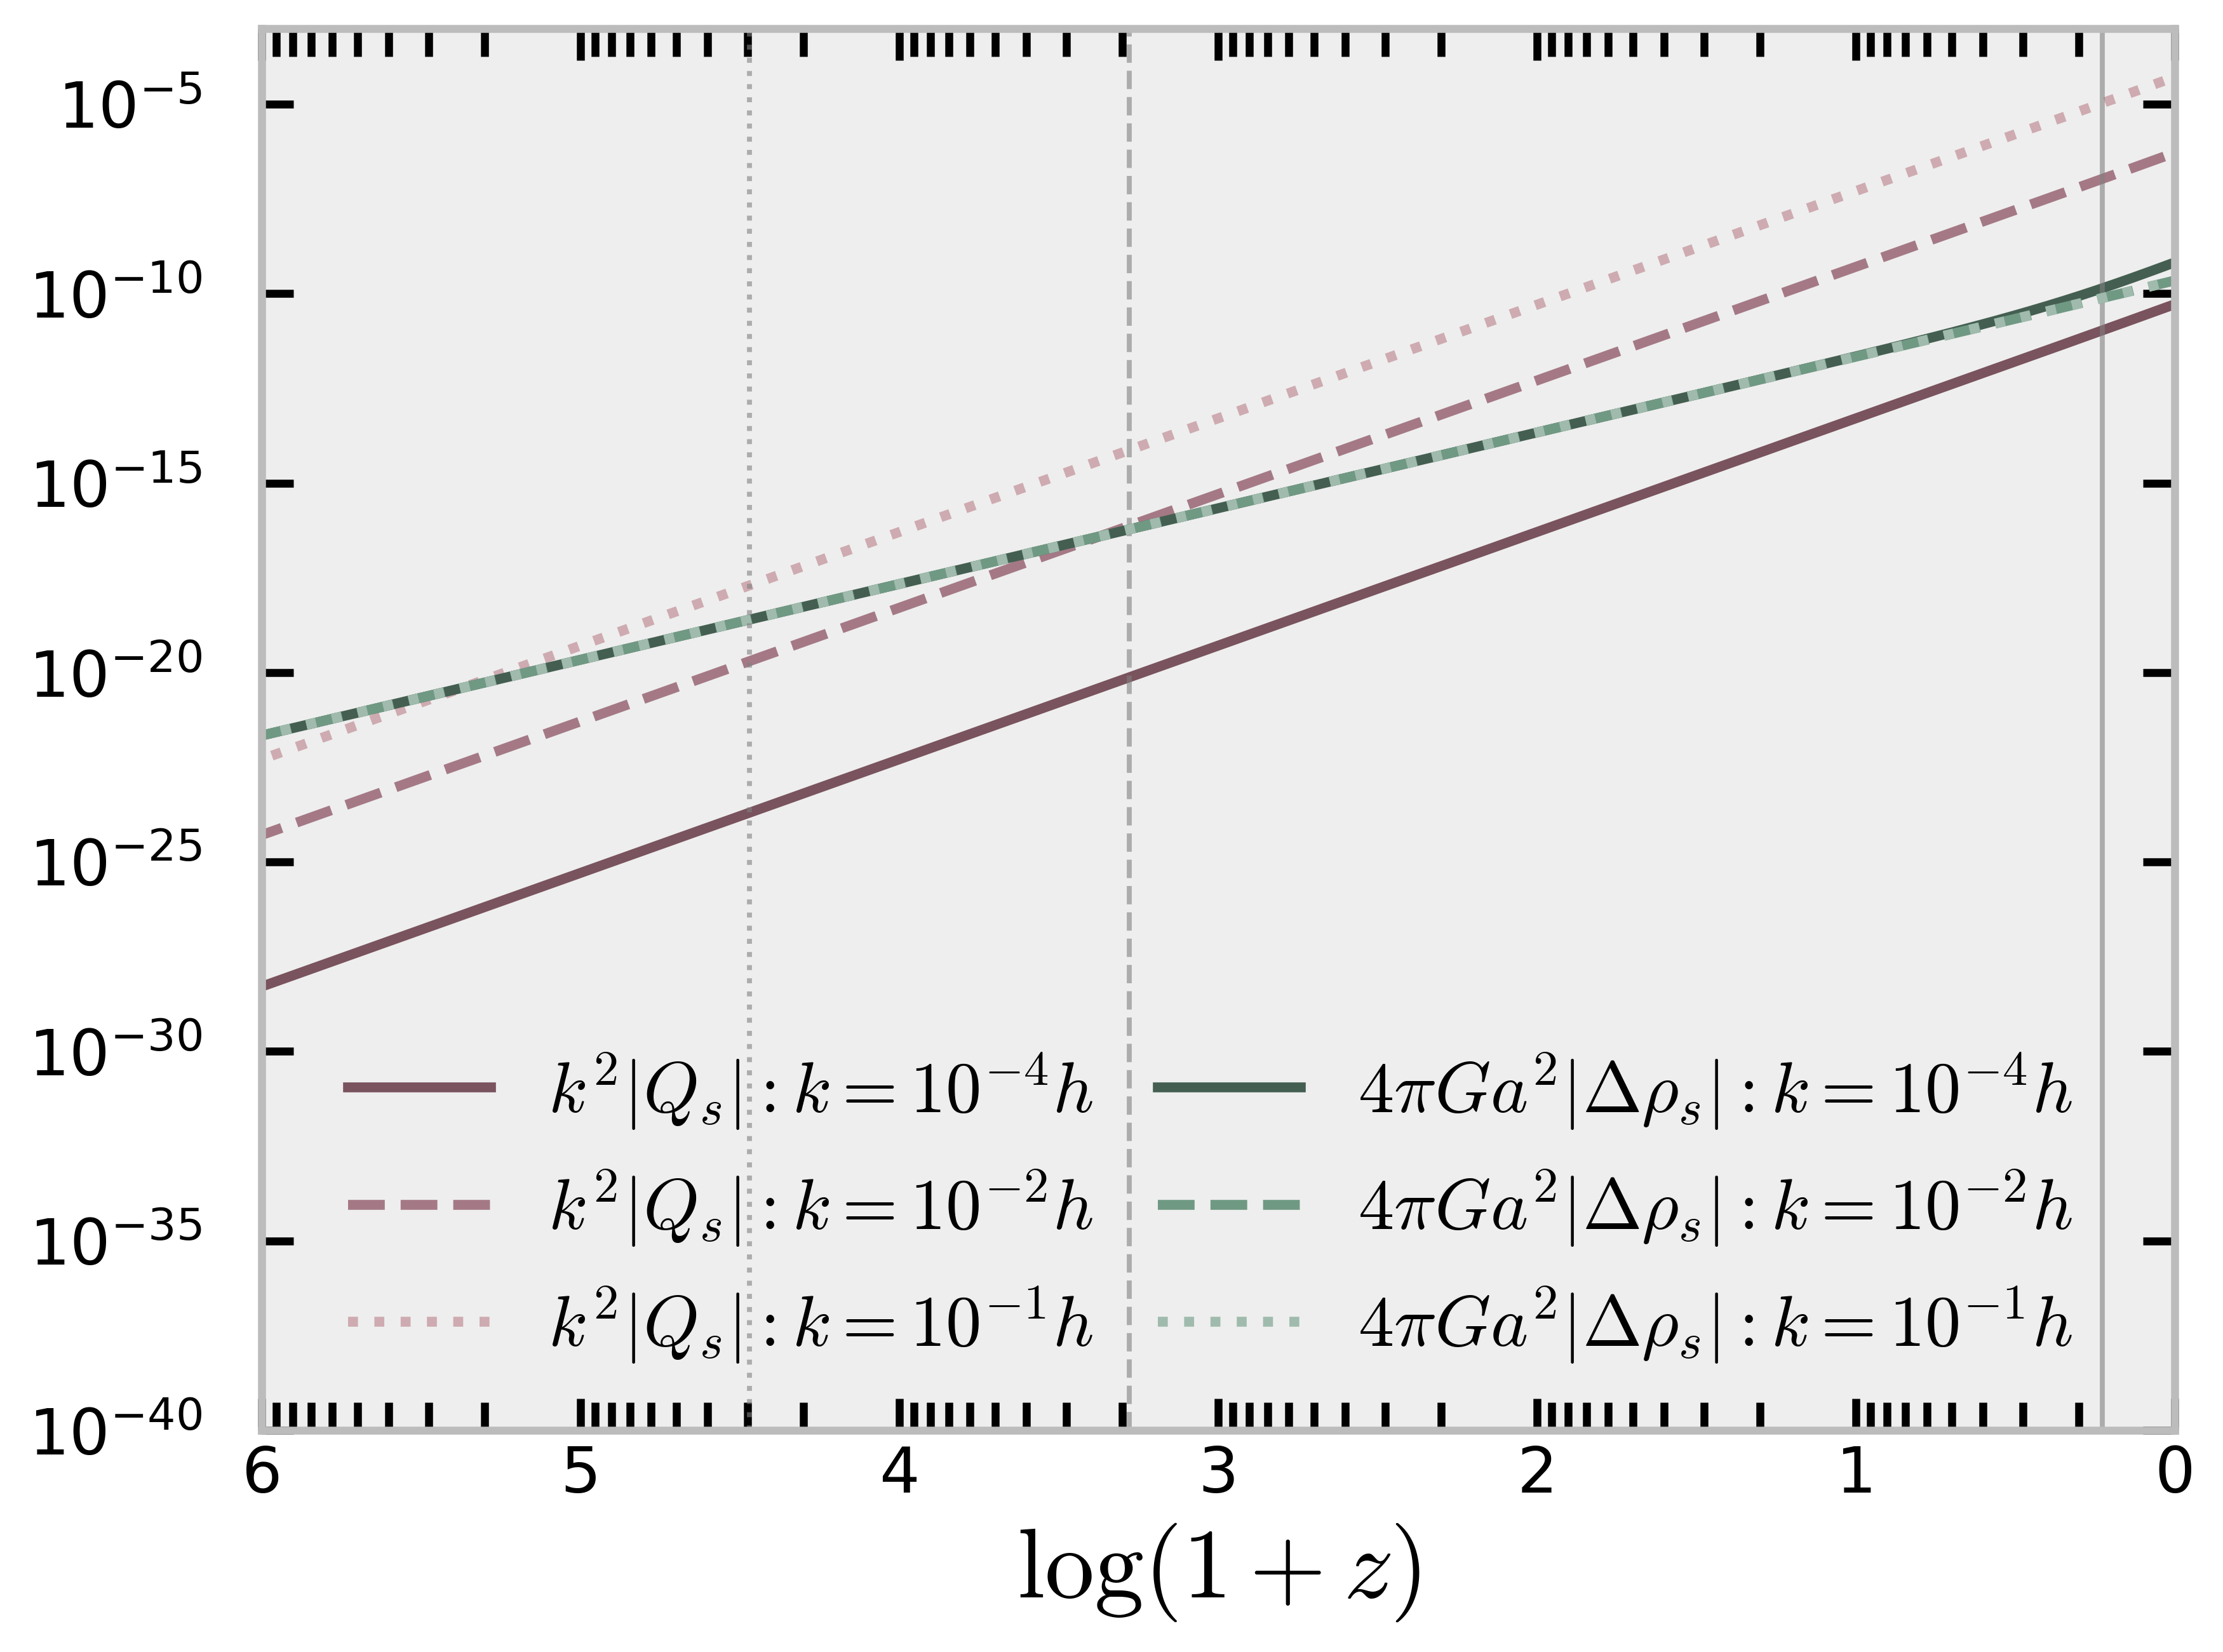

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--',':', ':', (0,(5,1))]

color = ['#B77B9C','#79535D','#AFE3C0','#FFBC42', '#DFCED5']
color2 =  ['#79535D','#A47985','#CEABB1','#445F51','#709984','#A0BBAD']

def build_interp1d(x, y, kind='linear', clamp=True):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # average duplicates
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
    """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")

# Color palette for the 3 quantities (same color repeated for each quantity across k values)
quantity_colors = ['C0', 'C1', 'C2']  # You can replace with specific colors like ['red', 'blue', 'green']
color_idx = 0
for ik, index_k in enumerate([0,1,2]):  # loop over k values
    # Line style: solid for first k, dashed for second k
    linestyle = ['-', '--', ':'][ik]
    

    for ib, index in enumerate([1]):   # loop over beta values
    
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack0 = cosmo[0].get_background()

        pblock   = cosmoPerturb['scalar'][index_k]
        pblock0   = cosmoPerturb0['scalar'][index_k]
        a        = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        a0        = pblock0['a']                          # perturbation a-grid
        z0 = 1/a0 - 1
        delta_rho_scf    = pblock['delta_rho_scf']
        delta_phi        = pblock['delta_phi_scf']
        delta_phi_prime  = pblock['delta_phi_prime_scf']
        psi              = pblock['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        print(h0,f0)
        n0 = n0s[index]
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
        f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)
        df_key = pick_first_key(cosmoBack, ["f'_scf", "f'_scf", "f'_scf"])
        f_prime_on_pert = interp_bg_to_pert(cosmoBack, df_key, a, kind='linear', clamp=True)

        Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
        Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
        rho_c_key0 = pick_first_key(cosmoBack0, ["(.)rho_edm"])
        rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
        rho_c_on_pert0 = interp_bg_to_pert(cosmoBack0, rho_c_key0, a0, kind='linear', clamp=True)
        
        rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
        rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
        horizon = H_on_pert  # if you decide to plot it
        # print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))
        # print(Vphiphi_on_pert[-1])

        delta_c = pblock['delta_cdm']   # check your key name
        S_m = np.abs(1.5*a**2 * rho_c_on_pert * delta_c)
        delta_c0 = pblock0['delta_cdm']   # check your key name
        S_m0 = np.abs(1.5*a0**2 * rho_c_on_pert0 * delta_c0)
        S_m2 = np.abs(1.5*a**2 * rho_c_on_pert)
        # print(S_m[-1])
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])
        # print(delta_s)

        kphys = k_sorted[index_k]/0.67556
        k = k_sorted[index_k]


        Qs = np.abs(k*k * (f_on_pert - h0*Vphi_on_pert)*delta_s/rho_c_on_pert)
        print('meff = ',np.sqrt(Vphiphi_on_pert[-1]))
        print(r'H = ',H_on_pert[-1])
        rhos = np.abs(1.5*a**2*(f_on_pert - Vphi_on_pert*(a*a*f_on_pert + k*k*h0)/(k*k + a*a*Vphiphi_on_pert)))
        rhos1 = np.abs(1.5*a**2*(f_on_pert))
        rhos2 = np.abs(1.5*a**2*(Vphi_on_pert*(a*a*f_prime_on_pert)/(k*k + a*a*Vphiphi_on_pert)))
    
        exp = int(np.round(np.log10(kphys)))
        # label only once per k
        # label_str1 = fr'$k^2 |Q_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str3 = fr'$4 \pi G a^2 |\delta \rho_c|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        label_str1 = fr'$k^2 |Q_s|: k = 10^{{{exp}}} h$' if ib == 0 else None
        label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s|: k = 10^{{{exp}}} h$' if ib == 0 else None
        label_str3 = fr'$4 \pi G a^2 |\rho_c \delta_c|: k = 10^{{{exp}}} h$' if ib == 0 else None

        ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=linestyle, c=color2[color_idx])
        # ax0.plot(1+z, rhos, label=label_str2, lw=lw, ls=linestyle, c=color[color_idx+2])
        # ax0.plot(1+z0, S_m0, label=label_str3, lw=lw, ls=linestyle, c=color[color_idx+2])
        # ax0.plot(1+z, rhos1, label=label_str2, lw=lw, ls=linestyle, c='red')
        # ax0.plot(1+z, rhos2, label=label_str2, lw=lw, ls=linestyle, c='blue')

        color_idx +=1
for ik, index_k in enumerate([0,1,2]):  # loop over k values
    # Line style: solid for first k, dashed for second k
    linestyle = ['-', '--', ':'][ik]
    

    for ib, index in enumerate([1]):   # loop over beta values
    
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack0 = cosmo[0].get_background()

        pblock   = cosmoPerturb['scalar'][index_k]
        pblock0   = cosmoPerturb0['scalar'][index_k]
        a        = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        a0        = pblock0['a']                          # perturbation a-grid
        z0 = 1/a0 - 1
        delta_rho_scf    = pblock['delta_rho_scf']
        delta_phi        = pblock['delta_phi_scf']
        delta_phi_prime  = pblock['delta_phi_prime_scf']
        psi              = pblock['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        print(h0,f0)
        n0 = n0s[index]
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
        f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)
        df_key = pick_first_key(cosmoBack, ["f'_scf", "f'_scf", "f'_scf"])
        f_prime_on_pert = interp_bg_to_pert(cosmoBack, df_key, a, kind='linear', clamp=True)

        Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
        Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
        rho_c_key0 = pick_first_key(cosmoBack0, ["(.)rho_edm"])
        rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
        rho_c_on_pert0 = interp_bg_to_pert(cosmoBack0, rho_c_key0, a0, kind='linear', clamp=True)
        
        rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
        rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
        horizon = H_on_pert  # if you decide to plot it
        # print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))
        # print(Vphiphi_on_pert[-1])

        delta_c = pblock['delta_cdm']   # check your key name
        S_m = np.abs(1.5*a**2 * rho_c_on_pert * delta_c)
        delta_c0 = pblock0['delta_cdm']   # check your key name
        S_m0 = np.abs(1.5*a0**2 * rho_c_on_pert0 * delta_c0)
        S_m2 = np.abs(1.5*a**2 * rho_c_on_pert)
        # print(S_m[-1])
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])
        # print(delta_s)

        kphys = k_sorted[index_k]/0.67556
        k = k_sorted[index_k]


        Qs = np.abs(k*k * (f_on_pert - h0*Vphi_on_pert)*delta_s/rho_c_on_pert)
        print('meff = ',np.sqrt(Vphiphi_on_pert[-1]))
        print(r'H = ',H_on_pert[-1])
        rhos = np.abs(1.5*a**2*(f_on_pert - Vphi_on_pert*(a*a*f_on_pert + k*k*h0)/(k*k + a*a*Vphiphi_on_pert)))
        rhos1 = np.abs(1.5*a**2*(f_on_pert))
        rhos2 = np.abs(1.5*a**2*(Vphi_on_pert*(a*a*f_prime_on_pert)/(k*k + a*a*Vphiphi_on_pert)))
    
        exp = int(np.round(np.log10(kphys)))

        # label only once per k
        # label_str1 = fr'$k^2 |Q_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str3 = fr'$4 \pi G a^2 |\delta \rho_c|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        label_str1 = fr'$k^2 |Q_s|: k = 10^{{{exp}}} h$' if ib == 0 else None
        label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s|: k = 10^{{{exp}}} h$' if ib == 0 else None
        label_str3 = fr'$4 \pi G a^2 |\rho_c \delta_c|: k = 10^{{{exp}}} h$' if ib == 0 else None

        # ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=linestyle, c=color[color_idx+1])
        ax0.plot(1+z, rhos, label=label_str2, lw=lw, ls=linestyle, c=color2[color_idx])
        # ax0.plot(1+z0, S_m0, label=label_str3, lw=lw, ls=linestyle, c=color[color_idx+2])
        # ax0.plot(1+z, rhos1, label=label_str2, lw=lw, ls=linestyle, c='red')
        # ax0.plot(1+z, rhos2, label=label_str2, lw=lw, ls=linestyle, c='blue')
        color_idx +=1
        
        # Add vertical line for horizon entry (where aH = k)
        if ib == 0:
            # Find where a*H_on_pert equals kphys
            idx_horizon = np.argmin(np.abs(H_on_pert*a - k))
            z_horizon = z[idx_horizon]
            # Use dotted style for better visibility on vertical lines
            horizon_style = ['-', '--', ':'][ik]
            ax0.axvline(1+z_horizon, lw=lw/2, ls=horizon_style, c='gray', alpha=0.6)
        print()

# ax0.plot(1+z, 1e-4*pow(1+z,-2),lw=lw/2, ls='-', c='blue')

# Axes & styling
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
#x0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)
ax0.set_xlim(1e6, 1)
#ax0.set_ylim(1e-23, 1e5)
ax0.set_ylim(1e-40, 1e-3)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 18}, ncol=2,columnspacing=0.9,bbox_to_anchor=(0.98, 0.0))
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

fig.tight_layout()
plt.savefig('comp_alg_constant.pdf')
plt.show()

In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
# ls = ['-','--',':', ':', (0,(5,1))]

# def build_interp1d(x, y, kind='linear', clamp=True):
#     """Return an interp1d callable with sorted, duplicate-free x."""
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y)   # average duplicates
#         yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
#     """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
#     z_bg = np.asarray(bg['z'])
#     a_bg = 1.0/(1.0 + z_bg)
#     y_bg = np.asarray(bg[key])
#     f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#     return f(a_target)

# def pick_first_key(d, candidates):
#     for k in candidates:
#         if k in d:
#             return k
#     raise KeyError(f"None of the keys found: {candidates}")

# # Color palette for the 3 quantities (same color repeated for each quantity across k values)
# quantity_colors = ['C0', 'C1', 'C2']  # You can replace with specific colors like ['red', 'blue', 'green']
# color_idx = 0
# for ik, index_k in enumerate([0,1,2]):  # loop over k values
#     # Line style: solid for first k, dashed for second k
#     linestyle = ['-', '--', ':'][ik]
    

#     for ib, index in enumerate([1]):   # loop over beta values
    
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoBack = cosmo[index].get_background()
#         cosmoPerturb0 = cosmo[0].get_perturbations()
#         cosmoBack0 = cosmo[0].get_background()

#         pblock   = cosmoPerturb['scalar'][index_k]
#         pblock0   = cosmoPerturb0['scalar'][index_k]
#         a        = pblock['a']                          # perturbation a-grid
#         z = 1/a - 1
#         a0        = pblock0['a']                          # perturbation a-grid
#         z0 = 1/a0 - 1
#         delta_rho_scf    = pblock['delta_rho_scf']
#         delta_phi        = pblock['delta_phi_scf']
#         delta_phi_prime  = pblock['delta_phi_prime_scf']
#         psi              = pblock['psi']

#         h0 = h0s[index]
#         f0 = f0s[index]
#         print(h0,f0)
#         n0 = n0s[index]
#         delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

#         # --- interpolate background pieces onto pert grid
#         Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
#         Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

#         f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
#         f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)
#         df_key = pick_first_key(cosmoBack, ["f'_scf", "f'_scf", "f'_scf"])
#         f_prime_on_pert = interp_bg_to_pert(cosmoBack, df_key, a, kind='linear', clamp=True)

#         Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
#         Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

#         phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
#         phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
#         phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
#         phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

#         rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
#         rho_c_key0 = pick_first_key(cosmoBack0, ["(.)rho_edm"])
#         rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
#         rho_c_on_pert0 = interp_bg_to_pert(cosmoBack0, rho_c_key0, a0, kind='linear', clamp=True)
        
#         rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
#         rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

#         H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
#         H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
#         horizon = H_on_pert  # if you decide to plot it
#         # print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))
#         # print(Vphiphi_on_pert[-1])

#         delta_c = pblock['delta_cdm']   # check your key name
#         S_m = np.abs(1.5*a**2 * rho_c_on_pert * delta_c)
#         delta_c0 = pblock0['delta_cdm']   # check your key name
#         S_m0 = np.abs(1.5*a0**2 * rho_c_on_pert0 * delta_c0)
#         S_m2 = np.abs(1.5*a**2 * rho_c_on_pert)
#         # print(S_m[-1])
#         delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])
#         # print(delta_s)

#         kphys = k_sorted[index_k]/0.67556
#         k = k_sorted[index_k]


#         Qs = np.abs(k*k * (f_on_pert - h0*Vphi_on_pert)*delta_s/rho_c_on_pert)
#         print('meff = ',np.sqrt(Vphiphi_on_pert[-1]))
#         print(r'H = ',H_on_pert[-1])
#         rhos = np.abs(1.5*a**2*(f_on_pert - Vphi_on_pert*(a*a*f_on_pert + k*k*h0)/(k*k + a*a*Vphiphi_on_pert)))
#         rhos1 = np.abs(1.5*a**2*(f_on_pert))
#         rhos2 = np.abs(1.5*a**2*(Vphi_on_pert*(a*a*f_prime_on_pert)/(k*k + a*a*Vphiphi_on_pert)))
    

#         # label only once per k
#         # label_str1 = fr'$k^2 |Q_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
#         # label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
#         # label_str3 = fr'$4 \pi G a^2 |\delta \rho_c|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
#         label_str1 = fr'$k^2 |Q_s|: k = {(kphys):.3g} h$' if ib == 0 else None
#         label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s|: k = {(kphys):.3g} h$' if ib == 0 else None
#         label_str3 = fr'$4 \pi G a^2 |\rho_c \delta_c|: k = {(kphys):.3g} h$' if ib == 0 else None

#         ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=linestyle, c=color[color_idx+1])
#         ax0.plot(1+z, rhos, label=label_str2, lw=lw, ls=linestyle, c=color[color_idx+2])
#         # ax0.plot(1+z0, S_m0, label=label_str3, lw=lw, ls=linestyle, c=color[color_idx+2])
#         # ax0.plot(1+z, rhos1, label=label_str2, lw=lw, ls=linestyle, c='red')
#         # ax0.plot(1+z, rhos2, label=label_str2, lw=lw, ls=linestyle, c='blue')
        
#         # Add vertical line for horizon entry (where aH = k)
#         if ib == 0:
#             # Find where a*H_on_pert equals kphys
#             idx_horizon = np.argmin(np.abs(H_on_pert*a - k))
#             z_horizon = z[idx_horizon]
#             # Use dotted style for better visibility on vertical lines
#             horizon_style = ['-', '--', ':'][ik]
#             ax0.axvline(1+z_horizon, lw=lw/2, ls=horizon_style, c='gray', alpha=0.6)
#         print()

# # ax0.plot(1+z, 1e-4*pow(1+z,-2),lw=lw/2, ls='-', c='blue')

# # Axes & styling
# ax0.set_xscale('log')
# ax0.set_yscale('log')
# ax0.set_xlabel(r'$\log(1+z)$', size=25)
# #x0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)
# ax0.set_xlim(1e6, 1)
# #ax0.set_ylim(1e-23, 1e5)
# ax0.set_ylim(1e-40, 1e-3)
# ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax0.legend(loc='lower right', frameon=boolean, prop={'size': 18}, ncol=1)
# original_labels = ax0.get_xticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_xticklabels(labels)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# fig.tight_layout()
# plt.savefig('comp_alg_constant.pdf')
# plt.show()

0.0 0.001
5.297735560910201e-11
2.229550321224149e-09
0.0 0.001
5.297735560910201e-07
1.63526329713862e-05
0.0 0.001
5.297735560910202e-05
0.0002584893007319411


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_14158/4095250457.py:163: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


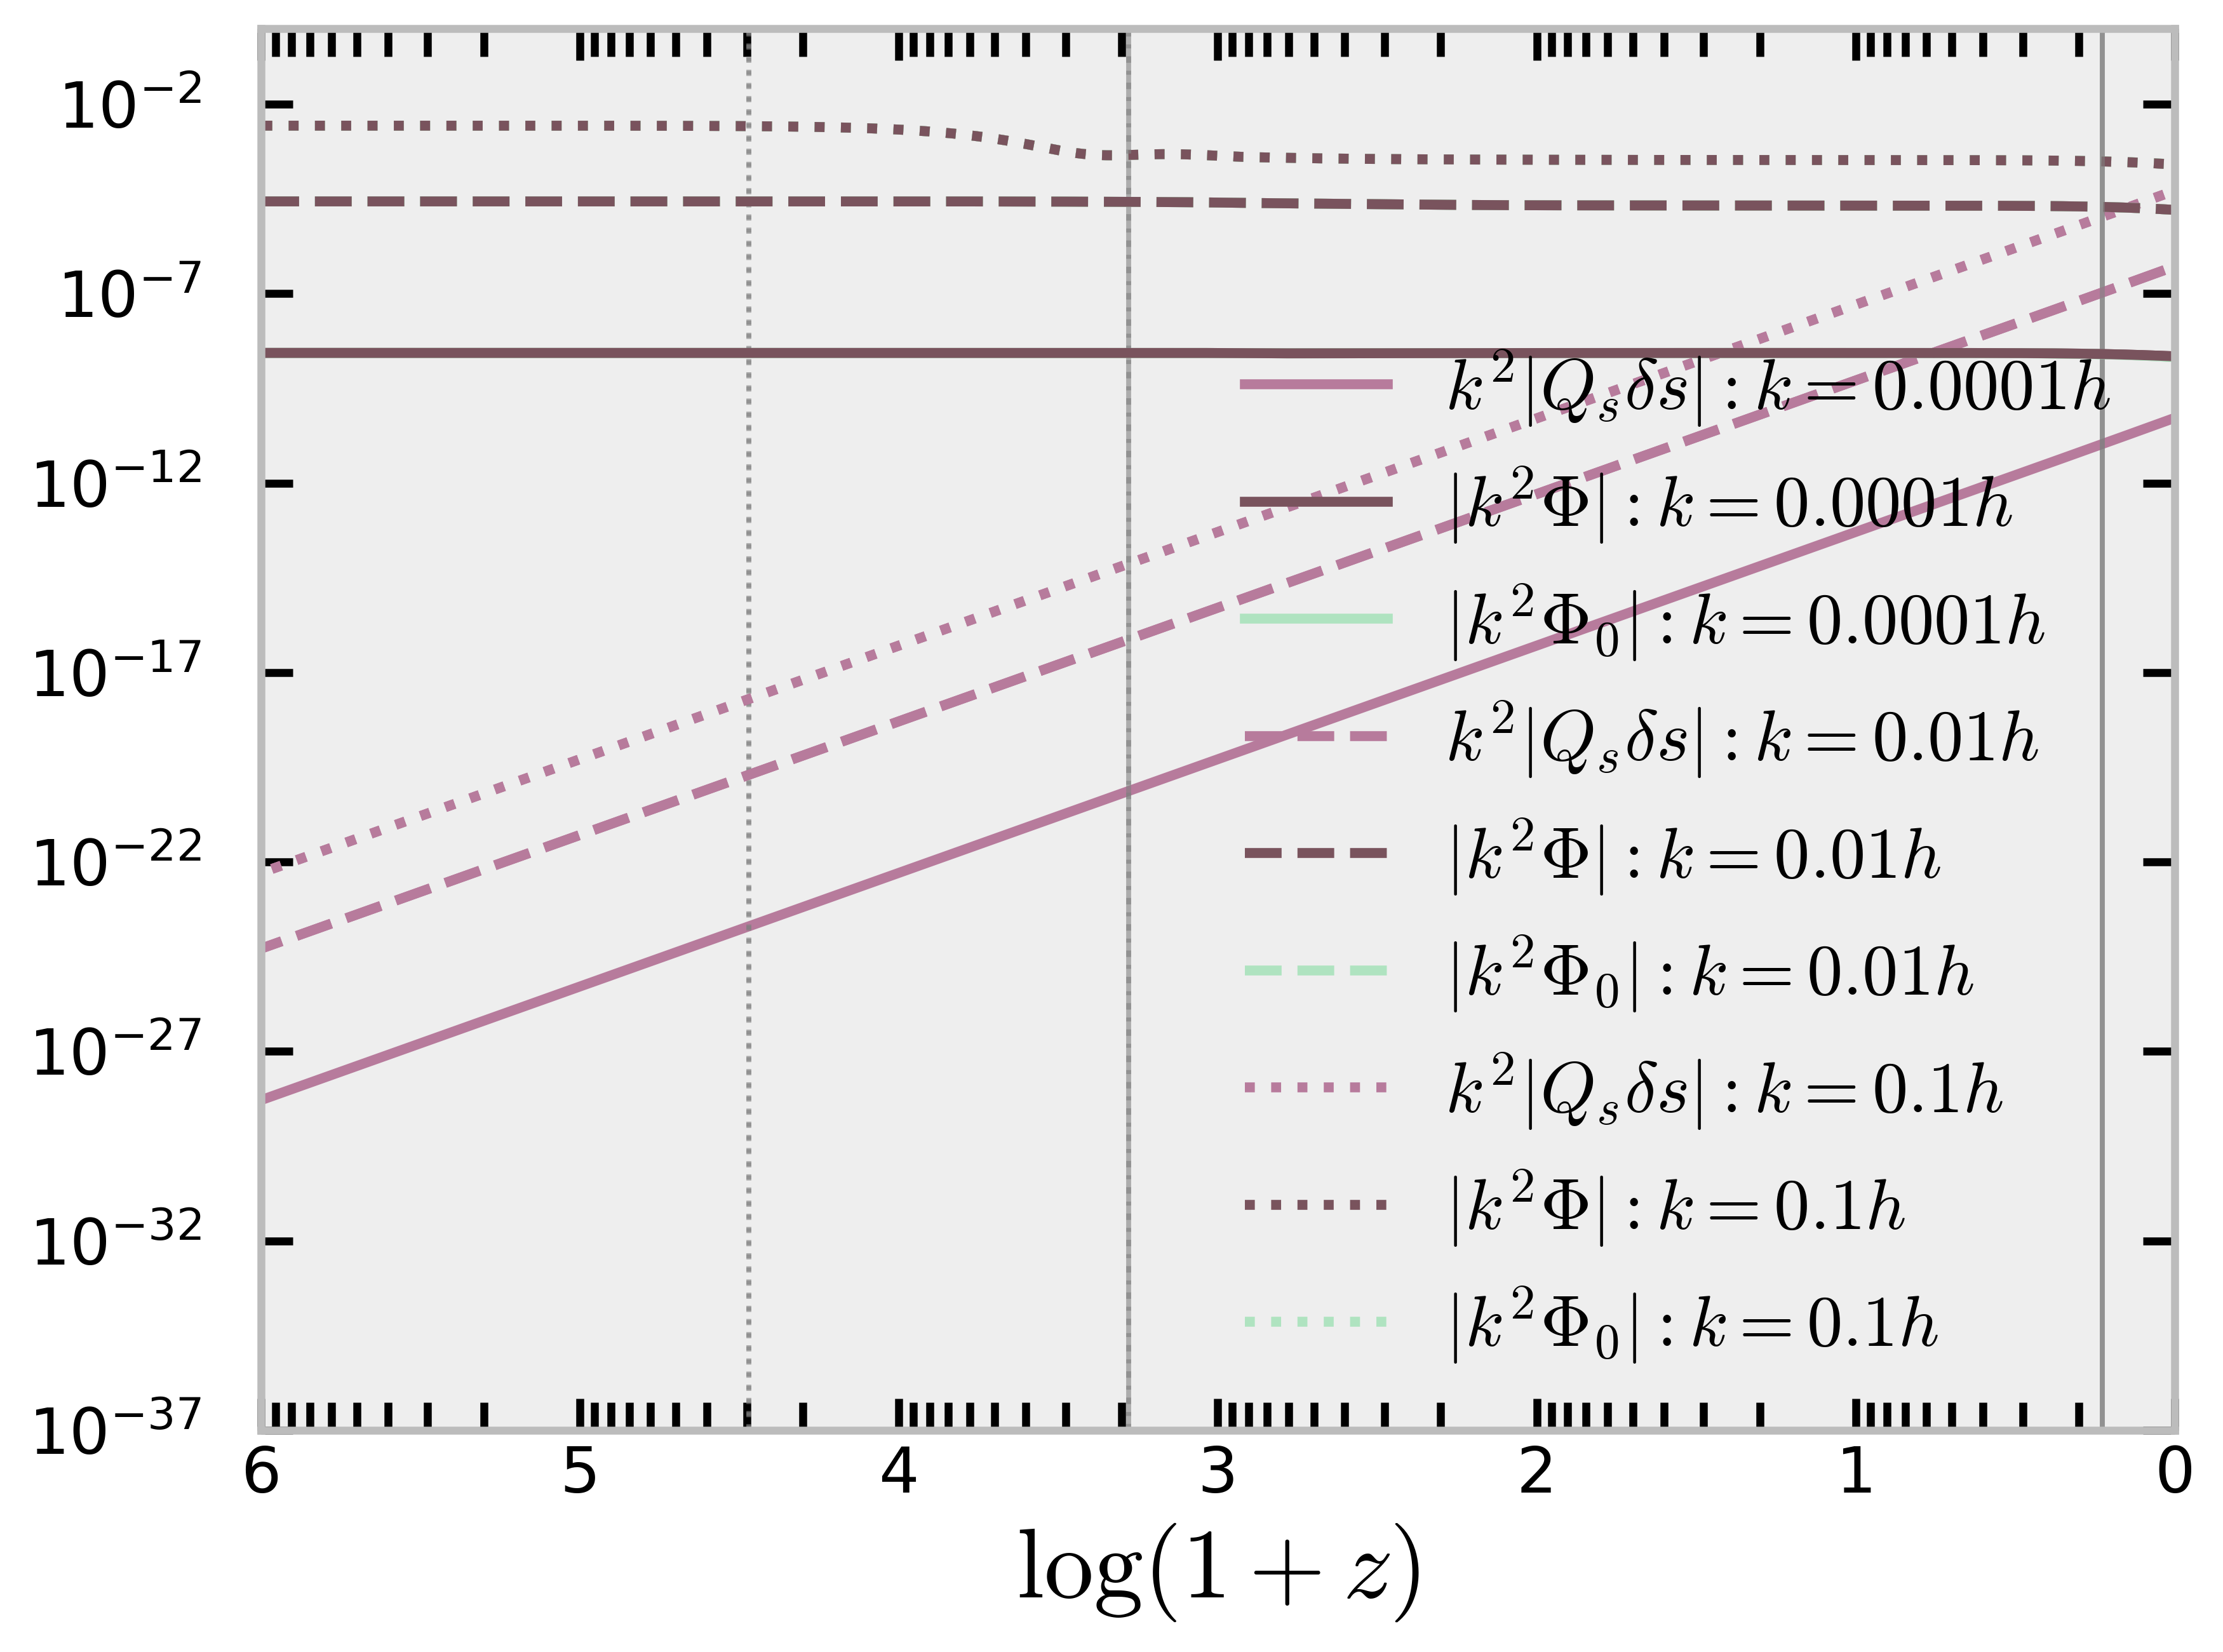

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--','-.', ':', (0,(5,1))]

def build_interp1d(x, y, kind='linear', clamp=True):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # average duplicates
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
    """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")

# Color palette for the 3 quantities (same color repeated for each quantity across k values)
quantity_colors = ['C0', 'C1', 'C2']  # You can replace with specific colors like ['red', 'blue', 'green']

color_idx = 0

for ik, index_k in enumerate([0,1,2]):  # loop over k values
    # Line style: solid for first k, dashed for second k
    linestyle = ['-', '--', ':'][ik]

    for ib, index in enumerate([1]):   # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack0 = cosmo[0].get_background()

        pblock   = cosmoPerturb['scalar'][index_k]
        pblock0   = cosmoPerturb0['scalar'][index_k]
        a        = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        a0        = pblock0['a']                          # perturbation a-grid
        z0 = 1/a0 - 1
        delta_rho_scf    = pblock['delta_rho_scf']
        delta_phi        = pblock['delta_phi_scf']
        delta_phi_prime  = pblock['delta_phi_prime_scf']
        psi              = pblock['psi']
        psi0              = pblock0['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        print(h0,f0)
        n0 = n0s[index]
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
        f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)
        df_key = pick_first_key(cosmoBack, ["f'_scf", "f'_scf", "f'_scf"])
        f_prime_on_pert = interp_bg_to_pert(cosmoBack, df_key, a, kind='linear', clamp=True)

        Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
        Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
        rho_c_key0 = pick_first_key(cosmoBack0, ["(.)rho_edm"])
        rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
        rho_c_on_pert0 = interp_bg_to_pert(cosmoBack0, rho_c_key0, a0, kind='linear', clamp=True)
        
        rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
        rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
        horizon = H_on_pert  # if you decide to plot it
        # print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))
        # print(Vphiphi_on_pert[-1])

        delta_c = pblock['delta_cdm']   # check your key name
        S_m = np.abs(1.5*a**2 * rho_c_on_pert * delta_c)
        delta_c0 = pblock0['delta_cdm']   # check your key name
        S_m0 = np.abs(1.5*a0**2 * rho_c_on_pert0 * delta_c0)
        S_m2 = np.abs(1.5*a**2 * rho_c_on_pert)
        # print(S_m[-1])
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])
        # print(delta_s)

        kphys = k_sorted[index_k]/0.67556
        k = k_sorted[index_k]


        Qs = np.abs(k*k * (f_on_pert - h0*Vphi_on_pert)*delta_s/rho_c_on_pert)
        print(Qs[-1])
        rhos = np.abs(1.5*a**2*(f_on_pert - Vphi_on_pert*(a*a*f_on_pert + k*k*h0)/(k*k + a*a*Vphiphi_on_pert))*delta_s)
        rhos1 = np.abs(1.5*a**2*(f_on_pert)*delta_s)
        k2psi = np.abs(k*k*psi)
        k2psi0 = np.abs(k*k*psi0)
        print(k2psi[-1])

        # label only once per k
        # label_str1 = fr'$k^2 |Q_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str2 = fr'$4 \pi G a^2 |\Delta \rho_s \delta s|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        # label_str3 = fr'$4 \pi G a^2 |\delta \rho_c|: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, n = {(n0):.1g}, h_0= {(h0):.2f}$' if ib == 0 else None
        label_str1 = fr'$k^2 |Q_s \delta s|: k = {(kphys):.3g} h$' if ib == 0 else None
        label_str2 = fr'$|k^2 \Phi|: k = {(kphys):.3g} h$' if ib == 0 else None
        label_str3 = fr'$|k^2 \Phi_0|: k = {(kphys):.3g} h$' if ib == 0 else None

        ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=linestyle, c=color[color_idx])
        ax0.plot(1+z, k2psi, label=label_str2, lw=lw, ls=linestyle, c=color[color_idx+1])
        ax0.plot(1+z0, k2psi0, label=label_str3, lw=lw, ls=linestyle, c=color[color_idx+2])
        # ax0.plot(1+z0, S_m0, label=label_str3, lw=lw, ls=linestyle, c=color[color_idx+2])
        # ax0.plot(1+z, rhos1, label=label_str2, lw=lw, ls=linestyle, c='red')
        # ax0.plot(1+z, rhos2, label=label_str2, lw=lw, ls=linestyle, c='blue')
        
        # Add vertical line for horizon entry (where aH = k)
        if ib == 0:
            # Find where a*H_on_pert equals kphys
            idx_horizon = np.argmin(np.abs(H_on_pert*a - k))
            z_horizon = z[idx_horizon]
            # Use dotted style for better visibility on vertical lines
            horizon_style = ['-', '--', ':'][ik]
            ax0.axvline(1+z_horizon, lw=lw/2, ls=horizon_style, c='gray', alpha=0.6)

# ax0.plot(1+z, 1e-4*pow(1+z,-2),lw=lw/2, ls='-', c='blue')

# Axes & styling
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
#x0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)
ax0.set_xlim(1e6, 1)
#ax0.set_ylim(1e-23, 1e5)
ax0.set_ylim(1e-37, 1e0)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 18}, ncol=1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('comp_psi_alg_constant.pdf')
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d

# fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
# ls = ['-','--','-.', ':', (0,(5,1))]

# def build_interp1d(x, y, kind='linear', clamp=True):
#     """Return an interp1d callable with sorted, duplicate-free x."""
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y)   # average duplicates
#         yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
#     """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
#     z_bg = np.asarray(bg['z'])
#     a_bg = 1.0/(1.0 + z_bg)
#     y_bg = np.asarray(bg[key])
#     f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#     return f(a_target)

# def pick_first_key(d, candidates):
#     for k in candidates:
#         if k in d:
#             return k
#     raise KeyError(f"None of the keys found: {candidates}")

# for ik, index_k in enumerate([0, 1,2]):  # loop over k values
#     color_idx = ik

#     for ib, index in enumerate([2]):   # loop over beta values
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoBack = cosmo[index].get_background()

#         pblock   = cosmoPerturb['scalar'][index_k]
#         a        = pblock['a']                          # perturbation a-grid
#         z = 1/a - 1
#         delta_rho_scf    = pblock['delta_rho_scf']
#         delta_phi        = pblock['delta_phi_scf']
#         delta_phi_prime  = pblock['delta_phi_prime_scf']
#         psi              = pblock['psi']

#         h0 = h0s[index]
#         f0 = f0s[index]
#         delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

#         # --- interpolate background pieces onto pert grid

#         f_key = pick_first_key(cosmoBack, ["f_scf", "f_scf", "f_scf"])
#         f_on_pert = interp_bg_to_pert(cosmoBack, f_key, a, kind='linear', clamp=True)

#         df_key = pick_first_key(cosmoBack, ["f'_scf", "f'_scf", "f'_scf"])
#         df_on_pert = interp_bg_to_pert(cosmoBack, df_key, a, kind='linear', clamp=True)

#         Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
#         Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

#         Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
#         Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

#         phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
#         phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
#         phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
#         phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

#         rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
#         rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
        
#         rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
#         rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

#         H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
#         H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
#         horizon = H_on_pert  # if you decide to plot it
#         print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))

#         kphys = k_sorted[index_k]/0.67556
#         k = k_sorted[index_k]

#         Qs = k*k * (f_on_pert - h0*Vphi_on_pert)/rho_c_on_pert
#         rhos = (4*np.pi*6.67430e-11*a*a)*(f_on_pert - Vphi_on_pert*(a*a*df_on_pert + k*k*h0)/(k*k + a*a*Vphiphi_on_pert*Vphiphi_on_pert))

#         # label only once per k
#         label_str1 = fr'$k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None
#         label_str2 = fr'$\Delta \rho_s: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

#         ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=ls[ib], c=color[color_idx])
#         # ax0.plot(1+z, rhos, label=label_str2, lw=lw, ls=ls[ib], c=color[color_idx+2])

#         # Optional horizon/k lines:
#         # if ib == 0:
#         #     ax0.plot(a, horizon, lw=lw, ls=':', c=color[color_idx+2])
#         #     ax0.hlines(y=k_sorted[index_k], xmin=a[0], xmax=a[-1], lw=lw, ls='-.', colors=color[color_idx+3])

# # Axes & styling
# ax0.set_xscale('log')
# ax0.set_yscale('log')
# ax0.set_xlabel(r'$\log(1+z)$', size=25)
# ax0.set_ylabel(r'$k^2 Q_s$', size=25)

# #ns-f0 plot 
# # ax0.set_xlim(1e6, 1)
# # ax0.set_ylim(-0.2, 100.)

# ax0.set_xlim(1e6, 1)
# ax0.set_ylim(1e-22, 1e5)

# ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
# ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
# original_labels = ax0.get_xticks()
# labels = []
# for label in original_labels:
#     labels.append(int(np.log10(label)))
# ax0.set_xticklabels(labels)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    
# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# fig.tight_layout()
# plt.savefig('qs_alg_constant.pdf')
# plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


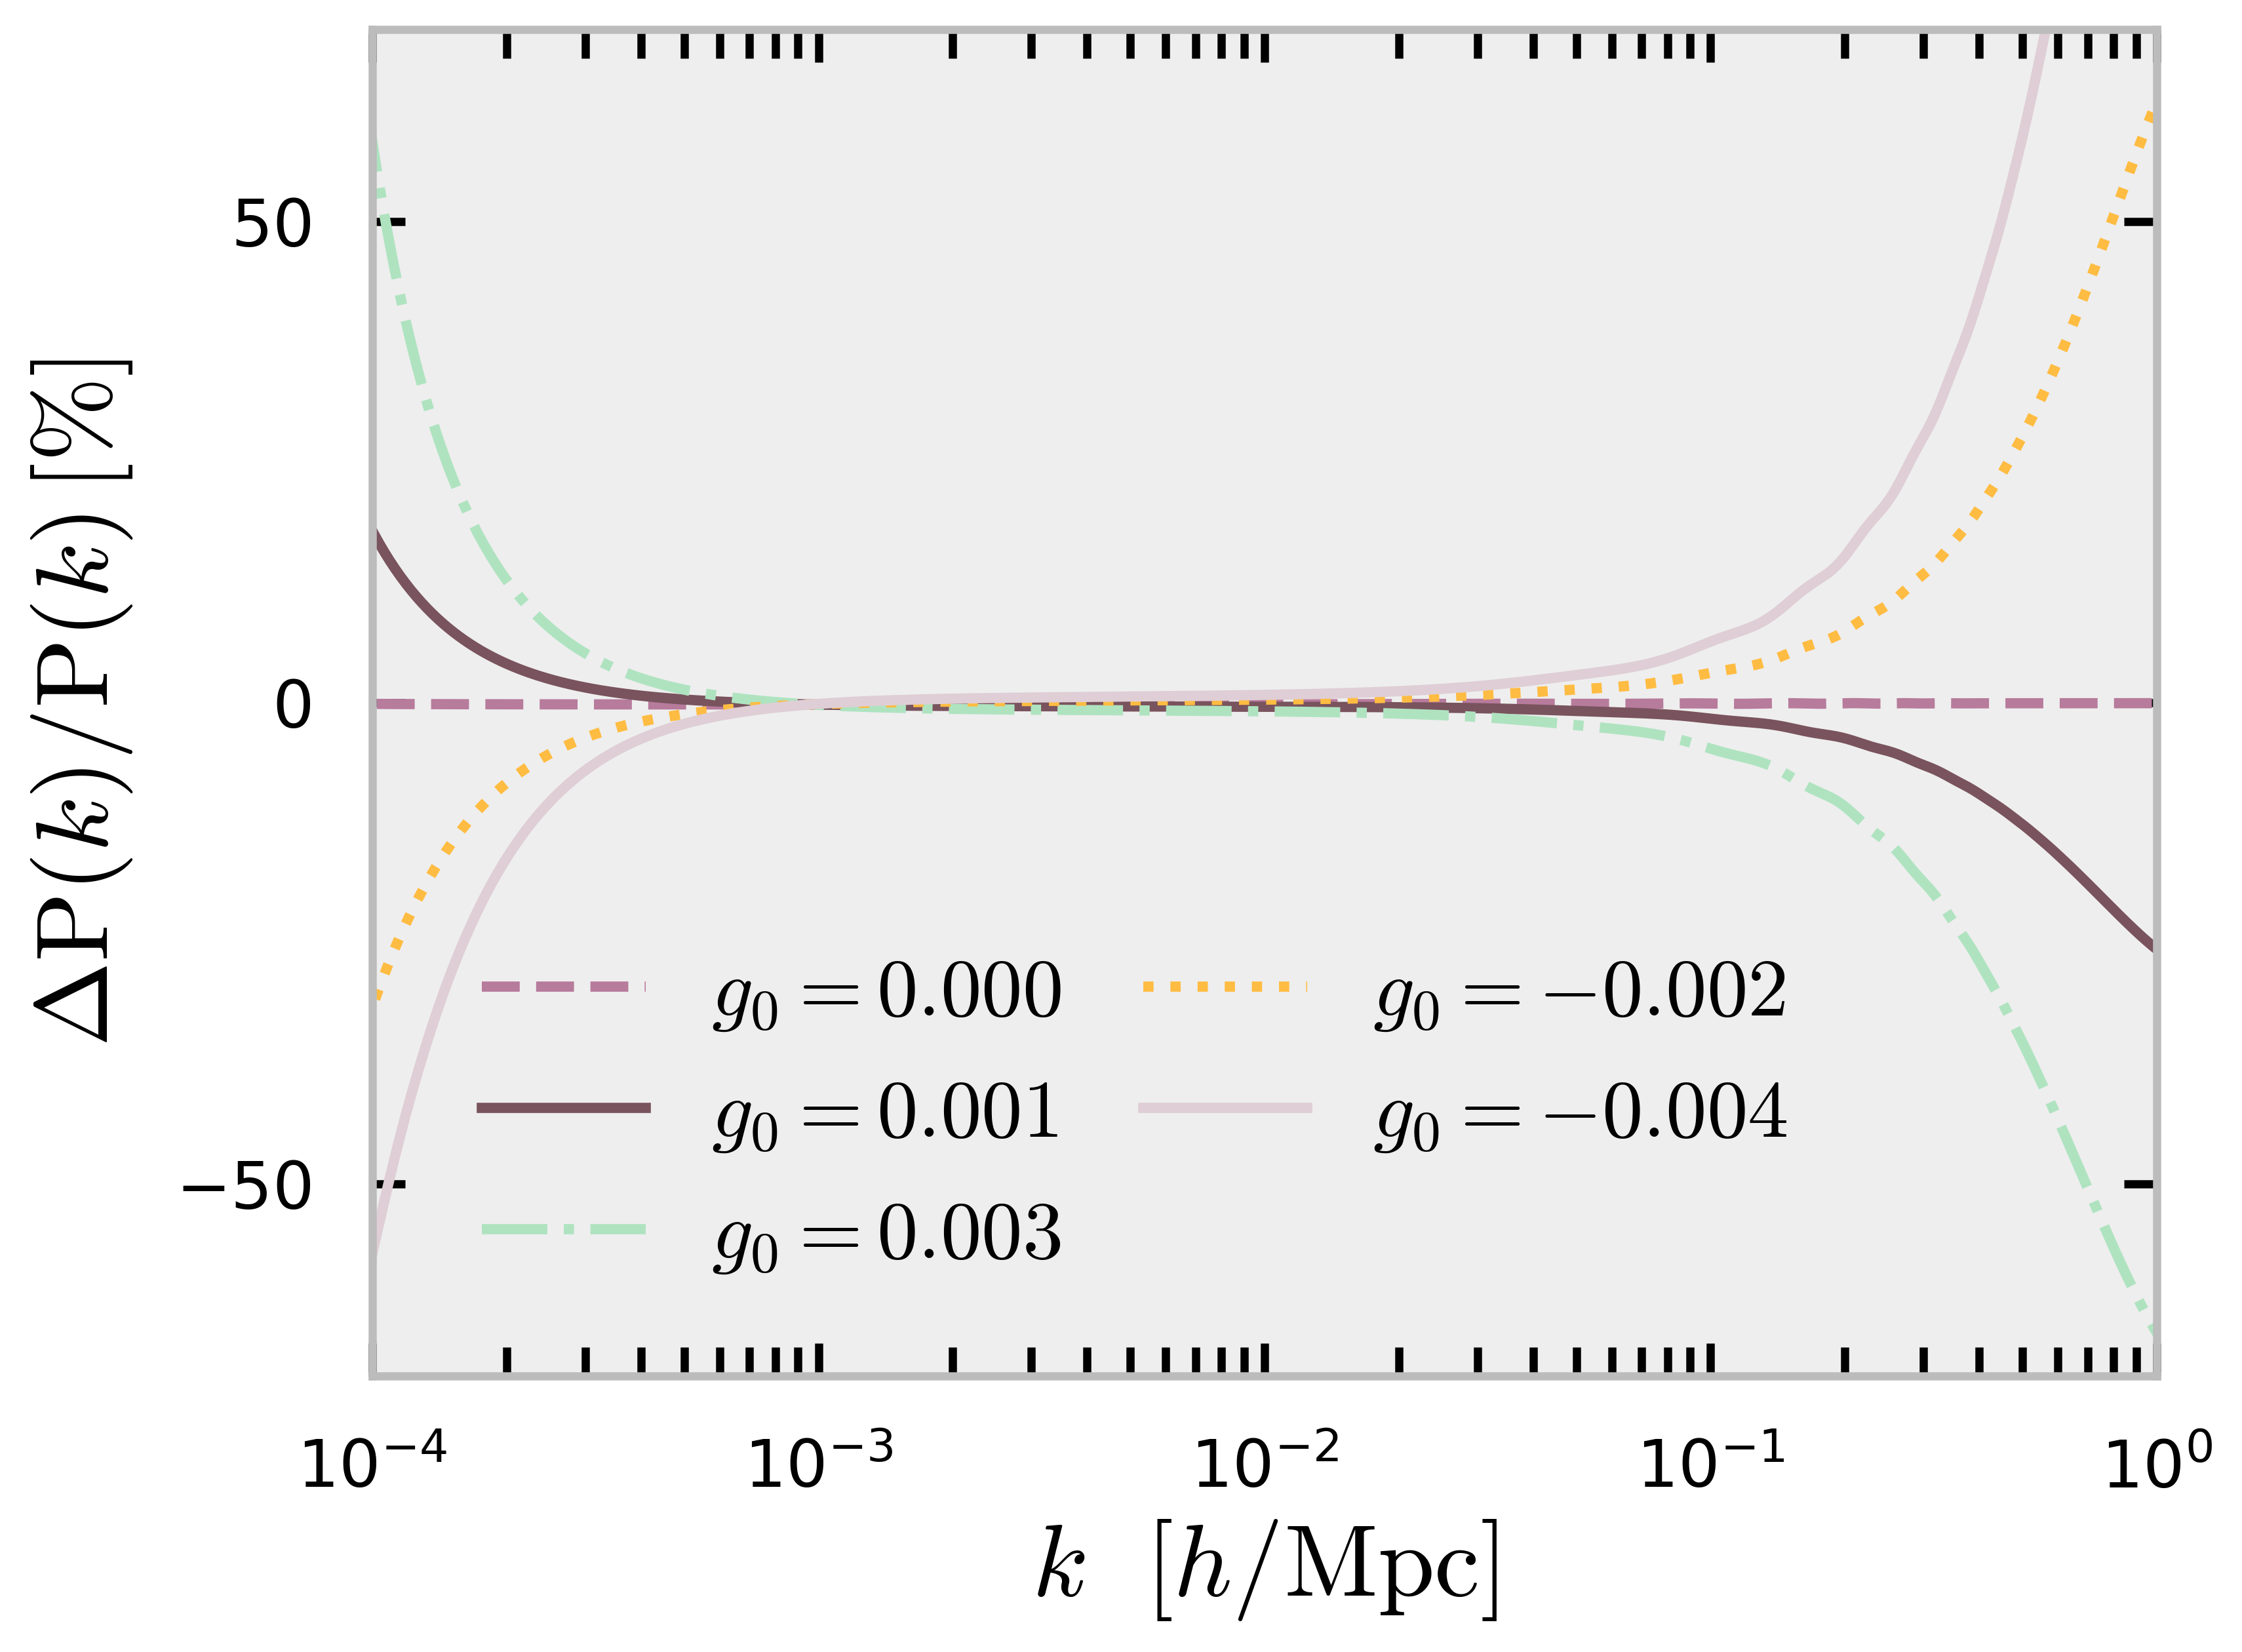

In [ ]:
# Plot only the differences (lower plot from cell 56) with 8x6 dimensions
plt.style.use(['ipynb', 'use_mathtext','colors10-ls'])
lw = 2.5
ls = ['--','-','-.', ':', '-']
kk = np.logspace(-5,np.log10(10),1000) # k in h/Mpc
Pk_standard = [] # P(k) in (Mpc/h)**3
h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc
for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,0.)*h_standard**3) # function .pk(k,z)
fig, ax1 = plt.subplots(figsize=(8,6))
i=0
for index in [0,1,2,3,4]:
    h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
    DELTA = []
    for k in kk:
        DELTA.append(100*(cosmo[index].pk(k*h,0.)*h**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
        /(standard.pk(k*h_standard,0.)*h_standard**3))
    ax1.plot(kk,DELTA, label = r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    i+=1
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1])
ax1.set_xlabel(r'$k \,\,\,\, [h/{\rm Mpc}]$', size=25)
ax1.set_ylabel(r'$\Delta {\rm P}(k)/{\rm P}(k)\, [\%]$', size=25,labelpad=10)
ax1.set_ylim(-70,70)
ax1.set_yticks([i for i in np.linspace(-50,50,3)])
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)
ax1.tick_params(axis='both', which='both', labelsize=16)
for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
ax1.legend(loc='lower left', frameon=boolean, prop={'size': 20}, bbox_to_anchor=(0.02, 0.02),ncol=2,columnspacing=1)
ax1.set_xlim([1.e-4,1])
#ax1.set_xlim([1.e-3,0.2])
# ax0.set_ylim([1e3,5.*1e4])
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('mpk_diff_alg_constant.pdf')
plt.show()

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_14158/1831863924.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)


0.0006280919919585507
-0.0003637146541894825
-0.015173122897999937
-0.0005214316358530708
-0.04639816943773298
-0.0008368269096792173
0.03260859439401778
-4.8245322308976095e-05
0.06509304872783336
0.00026727442768916795


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


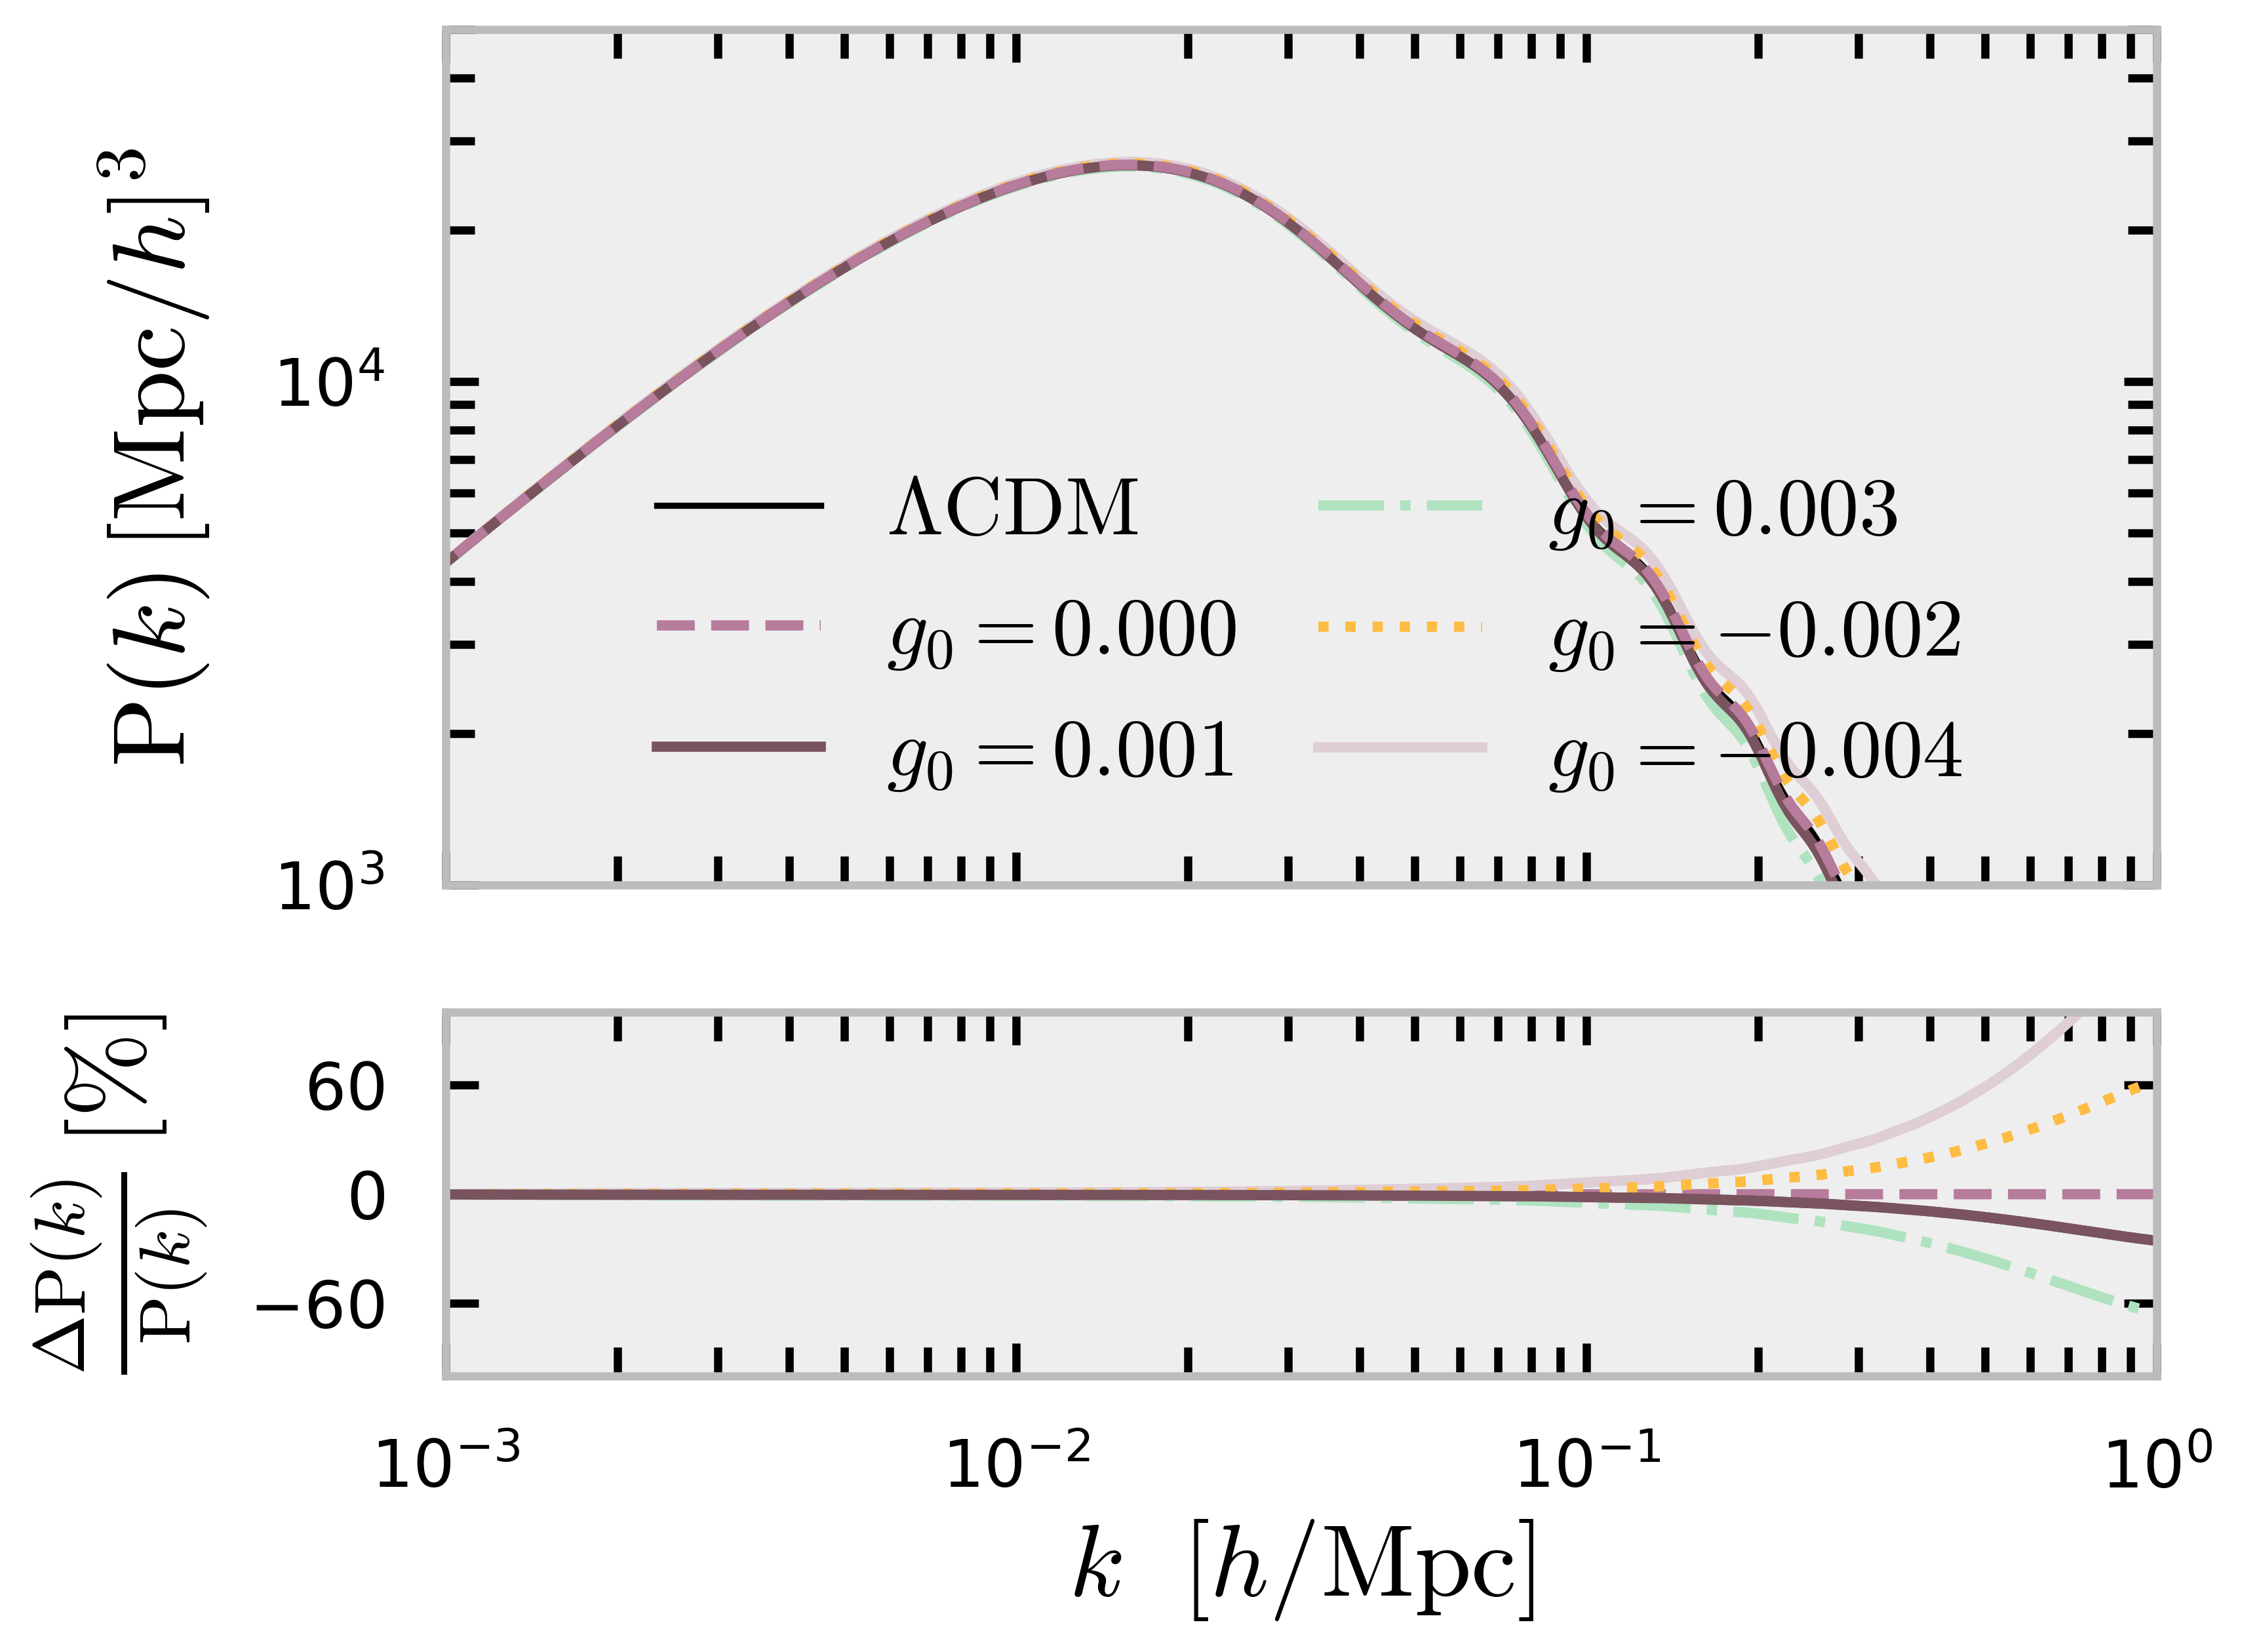

In [33]:
#plt.style.use('classic')
#vapeplot.set_palette('seapunk')
plt.style.use(['ipynb', 'use_mathtext','colors10-ls'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

kk = np.logspace(-5,np.log10(10),1000) # k in h/Mpc

Pk_standard = [] # P(k) in (Mpc/h)**3
h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc

#Pk_weird = [] # P(k) in (Mpc/h)**3
#h_weird = weird.h() # get reduced Hubble for conversions to 1/Mpc
#DELTAweird = []

for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,0.)*h_standard**3) # function .pk(k,z)
    #Pk_weird.append(standard.pk(k*h_weird,0.)*h_weird**3) # function .pk(k,z)
    #DELTAweird.append(100*(weird.pk(k*h_weird,0.)*h_weird**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
     #   /(standard.pk(k*h_standard,0.)*h_standard**3))
    
i=0
ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)
#ax0.plot(kk,Pk_weird,'k', label = r'$\Lambda{\rm CDM}$', c = 'r', ls='--',  lw=1.5)

for index in [0,1,2,3,4]:
    Pk = [] # P(k) in (Mpc/h)**3
    h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
    DELTA = []
    for k in kk:
        Pk.append(cosmo[index].pk(k*h,0.)*h**3) # function .pk(k,z)
        DELTA.append(100*(cosmo[index].pk(k*h,0.)*h**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
        /(standard.pk(k*h_standard,0.)*h_standard**3))
    # plot P(k)
    ax0.plot(kk,Pk, label = \
                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    ax1.plot(kk,DELTA, label = \
                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    #ax1.plot(kk,DELTAweird, lw=lw, ls='--', c='r')
    print((cosmo[index].pk(0.1*h,0.)-standard.pk(0.1*h_standard,0.))/standard.pk(0.1*h_standard,0.))
    print((cosmo[index].pk(0.001*h,0.)-standard.pk(0.001*h_standard,0.))/standard.pk(0.001*h_standard,0.))
    i+=1


    

ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(kk[0],kk[-1]);ax0.set_ylim(5,1e5)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1])

ax1.set_xlabel(r'$k \,\,\,\, [h/{\rm Mpc}]$', size=25)
ax0.set_ylabel(r'${\rm P} (k) \,[{\rm Mpc}/h]^3$', size=25,labelpad=15)
ax1.set_ylabel(r'$\frac{\Delta {\rm P}(k)}{{\rm P}(k)}\, [\%]$', size=25,labelpad=10)

#ns-f0 and ns-h0 plot 
# ax0.set_xlim([1.e-3,0.2])
ax0.set_xlim([1.e-3,1])
# ax1.set_xlim([1.e-3,0.2])
ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(-100,100)
ax1.set_yticks([i for i in np.linspace(-60,60,3)])

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)

    
#ax0.set_xscale('log')
ax1.set_xscale('log')
ax0.set_yscale('log')


ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )


ax0.legend(loc='lower left', frameon=boolean, prop={'size': 20}, bbox_to_anchor=(0.08, 0.02),ncol=2,columnspacing=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('mpk_alg_constant.pdf'), 
#transparent=True)
plt.show()

In [34]:
# #plt.style.use('classic')
# #vapeplot.set_palette('seapunk')
# plt.style.use(['ipynb', 'use_mathtext','colors10-ls'])

# lw = 2.5
# ls = ['--','-','-.', ':', '-']


# fig = plt.figure(figsize=(8,6))
# ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
# ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

# plt.subplots_adjust(hspace=0,wspace=0.)

# kk = np.logspace(-5,np.log10(1),1000) # k in h/Mpc

# Pk_standard = [] # P(k) in (Mpc/h)**3
# h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc

# #Pk_weird = [] # P(k) in (Mpc/h)**3
# #h_weird = weird.h() # get reduced Hubble for conversions to 1/Mpc
# #DELTAweird = []
# z0=0
# for k in kk:
#     Pk_standard.append(standard.pk(k*h_standard,z0)*h_standard**3) # function .pk(k,z)
#     #Pk_weird.append(standard.pk(k*h_weird,0.)*h_weird**3) # function .pk(k,z)
#     #DELTAweird.append(100*(weird.pk(k*h_weird,0.)*h_weird**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
#      #   /(standard.pk(k*h_standard,0.)*h_standard**3))
    
# i=0
# ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)
# #ax0.plot(kk,Pk_weird,'k', label = r'$\Lambda{\rm CDM}$', c = 'r', ls='--',  lw=1.5)

# for index in [0,1,2,3,4]:
#     Pk = [] # P(k) in (Mpc/h)**3
#     h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
#     DELTA = []
#     for k in kk:
#         Pk.append(cosmo[index].pk(k*h,z0)*h**3) # function .pk(k,z)
#         DELTA.append(100*(cosmo[index].pk(k*h,z0)*h**3 - standard.pk(k*h_standard,z0)*h_standard**3)\
#         /(standard.pk(k*h_standard,z0)*h_standard**3))
#     # plot P(k)
#     ax0.plot(kk,Pk, label = \
#                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
#     ax1.plot(kk,DELTA, label = \
#                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
#     #ax1.plot(kk,DELTAweird, lw=lw, ls='--', c='r')
#     print((cosmo[index].pk(0.1*h,z0)-standard.pk(0.1*h_standard,z0))/standard.pk(0.1*h_standard,z0))
#     print((cosmo[index].pk(0.001*h,z0)-standard.pk(0.001*h_standard,z0))/standard.pk(0.001*h_standard,z0))
#     i+=1


    

# ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(kk[0],kk[-1]);ax0.set_ylim(5,1e5)
# # ax1.se, colo=colotrp[0]t_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1])

# # ax1.set_xlabel(r'$k \,\,\,\, [, color=color[0=111])h/{\rm Mpc}]$', size=25)
# # ax0.set_ylabel(r'${\rm , color=color[03])P} (k)3 \,[{\rm Mpc}/h]^3$', size=25,label, color=color[02])pad=15)
# # ax1.set_ylabel(r'$\frac{\Delta {\rm P}(k)}{{\rm P}(k)}\, [\%]$', size=25,label.5pa1.2122d=10)

# #ns-f0 plot 
# ax0.set_xlim([1.e-4,0.2])
# ax1.set_xlim([1.e-4,0.2])
# ax0.set_ylim([1e3,5.*1e4])
# ax1.set_ylim(-1,1)
# # ax1.set_yticks([i for i in np.linspace(-80,0,3)])

# ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
# ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance
# ax1.tick_params(axis='both', which='both', labelsize=16)
# ax1.tick_params(axis='both', which='both', labelsize=16)

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)

    
# #ax0.set_xscale('log')
# ax1.set_xscale('log')
# ax0.set_yscale('log')


# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )


# ax0.legend(loc='lower left', frameon=boolean, prop={'size': 20}, bbox_to_anchor=(0.08, 0.02),ncol=2)
# plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 20
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# plt.savefig('mpk-100_alg_constant.pdf'), 
# #transparent=True)
# plt.show()

In [ ]:
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# lw = 2.5
# ls = ['--','-','-.', ':', '-']


# fig = plt.figure(figsize=(8,6))
# ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
# ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

# plt.subplots_adjust(hspace=0,wspace=0.)

# # get lambdac
# cls_standard = standard.lensed_cl(2000)
# ll = cls_standard['ell'][2:]
# clEE_standard = cls_standard['ee'][2:]

# i=0
# # plot Lc
# ax0.plot(ll,clEE_standard, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
# for index in [0,1,2,3,4]: #--------------------------------> BETA
# # get all C_l output
#     cls = cosmo[index].lensed_cl(2000)
#     ll = cls['ell'][2:]
#     clEE = cls['ee'][2:]
# # plot C_l^EE
#     ax0.plot(ll,clEE, label = \
#             r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[i], c=color[i])
#     DELTA = (clEE  - clEE_standard) / clEE_standard
#     ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
#     i+=1

# #ns-f0 plot 
# ax0.set_xscale('log')
# ax0.set_yscale('linear')
# ax0.set_xlim(30,2000)
# ax0.set_ylim(0,1.75e-16)
# ax1.set_xscale('log')
# ax1.set_yscale('linear')
# ax1.set_xlim(30,2000)
# ax1.set_ylim(-5.,5.)
# ax1.set_yticks([i for i in np.linspace(-7,5,4)])

# ax1.set_xlabel(r'$\ell$', size=25)
# ax0.set_ylabel(r'$C_\ell^\mathrm{EE}$', size=25,labelpad=10)
# ax1.set_ylabel(r'$\Delta C_\ell^\mathrm{EE}/C_\ell^\mathrm{EE}\, [\%]$', size=25)


# ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

# ax0.tick_params(axis='both', which='both', labelsize=16)
# ax0.tick_params(axis='both', which='both', labelsize=16)

# #---------------------------------------------------------------------------------> change ticklabels distance

# for tick in ax1.xaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax0.yaxis.get_major_ticks():
#     tick.set_pad(15)
# for tick in ax1.yaxis.get_major_ticks():
#     tick.set_pad(15)
    

# ax0.tick_params(axis='both', which='both', labelsize=16)

    
# ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# ax1.tick_params(axis='both', which='both', labelsize=16)

    
# ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
# ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
# ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
# ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

# plt.tight_layout()
# #plt.savefig('cq_cmb_tt.pdf', transparent=True)

# for ax in (ax0, ax1):
#     # copy the list so we don't iterate over lines we add
#     lines = list(ax.get_lines())[1:]
#     for ln in lines[::-1]:
#         ax.plot(
#             ln.get_xdata(), ln.get_ydata(),
#             ls=ln.get_linestyle(),
#             lw=ln.get_linewidth(),
#             c=ln.get_color(),
#             marker=ln.get_marker(),
#             markersize=ln.get_markersize(),
#             alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
#             label="_nolegend_",  # labels starting with '_' are ignored by legend()
#         )

# ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20})
# plt.setp(ax0.get_xticklabels(), visible=False)
# plt.rcParams['font.size'] = 20
# plt.rcParams['axes.linewidth'] = 2
# fig.tight_layout()
# plt.savefig('clsee.pdf', transparent=True)
# plt.show()

[8.48032735e-09 2.59413550e-09 1.07869757e-09 ... 5.40799650e-22
 5.39158462e-22 5.37523029e-22]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


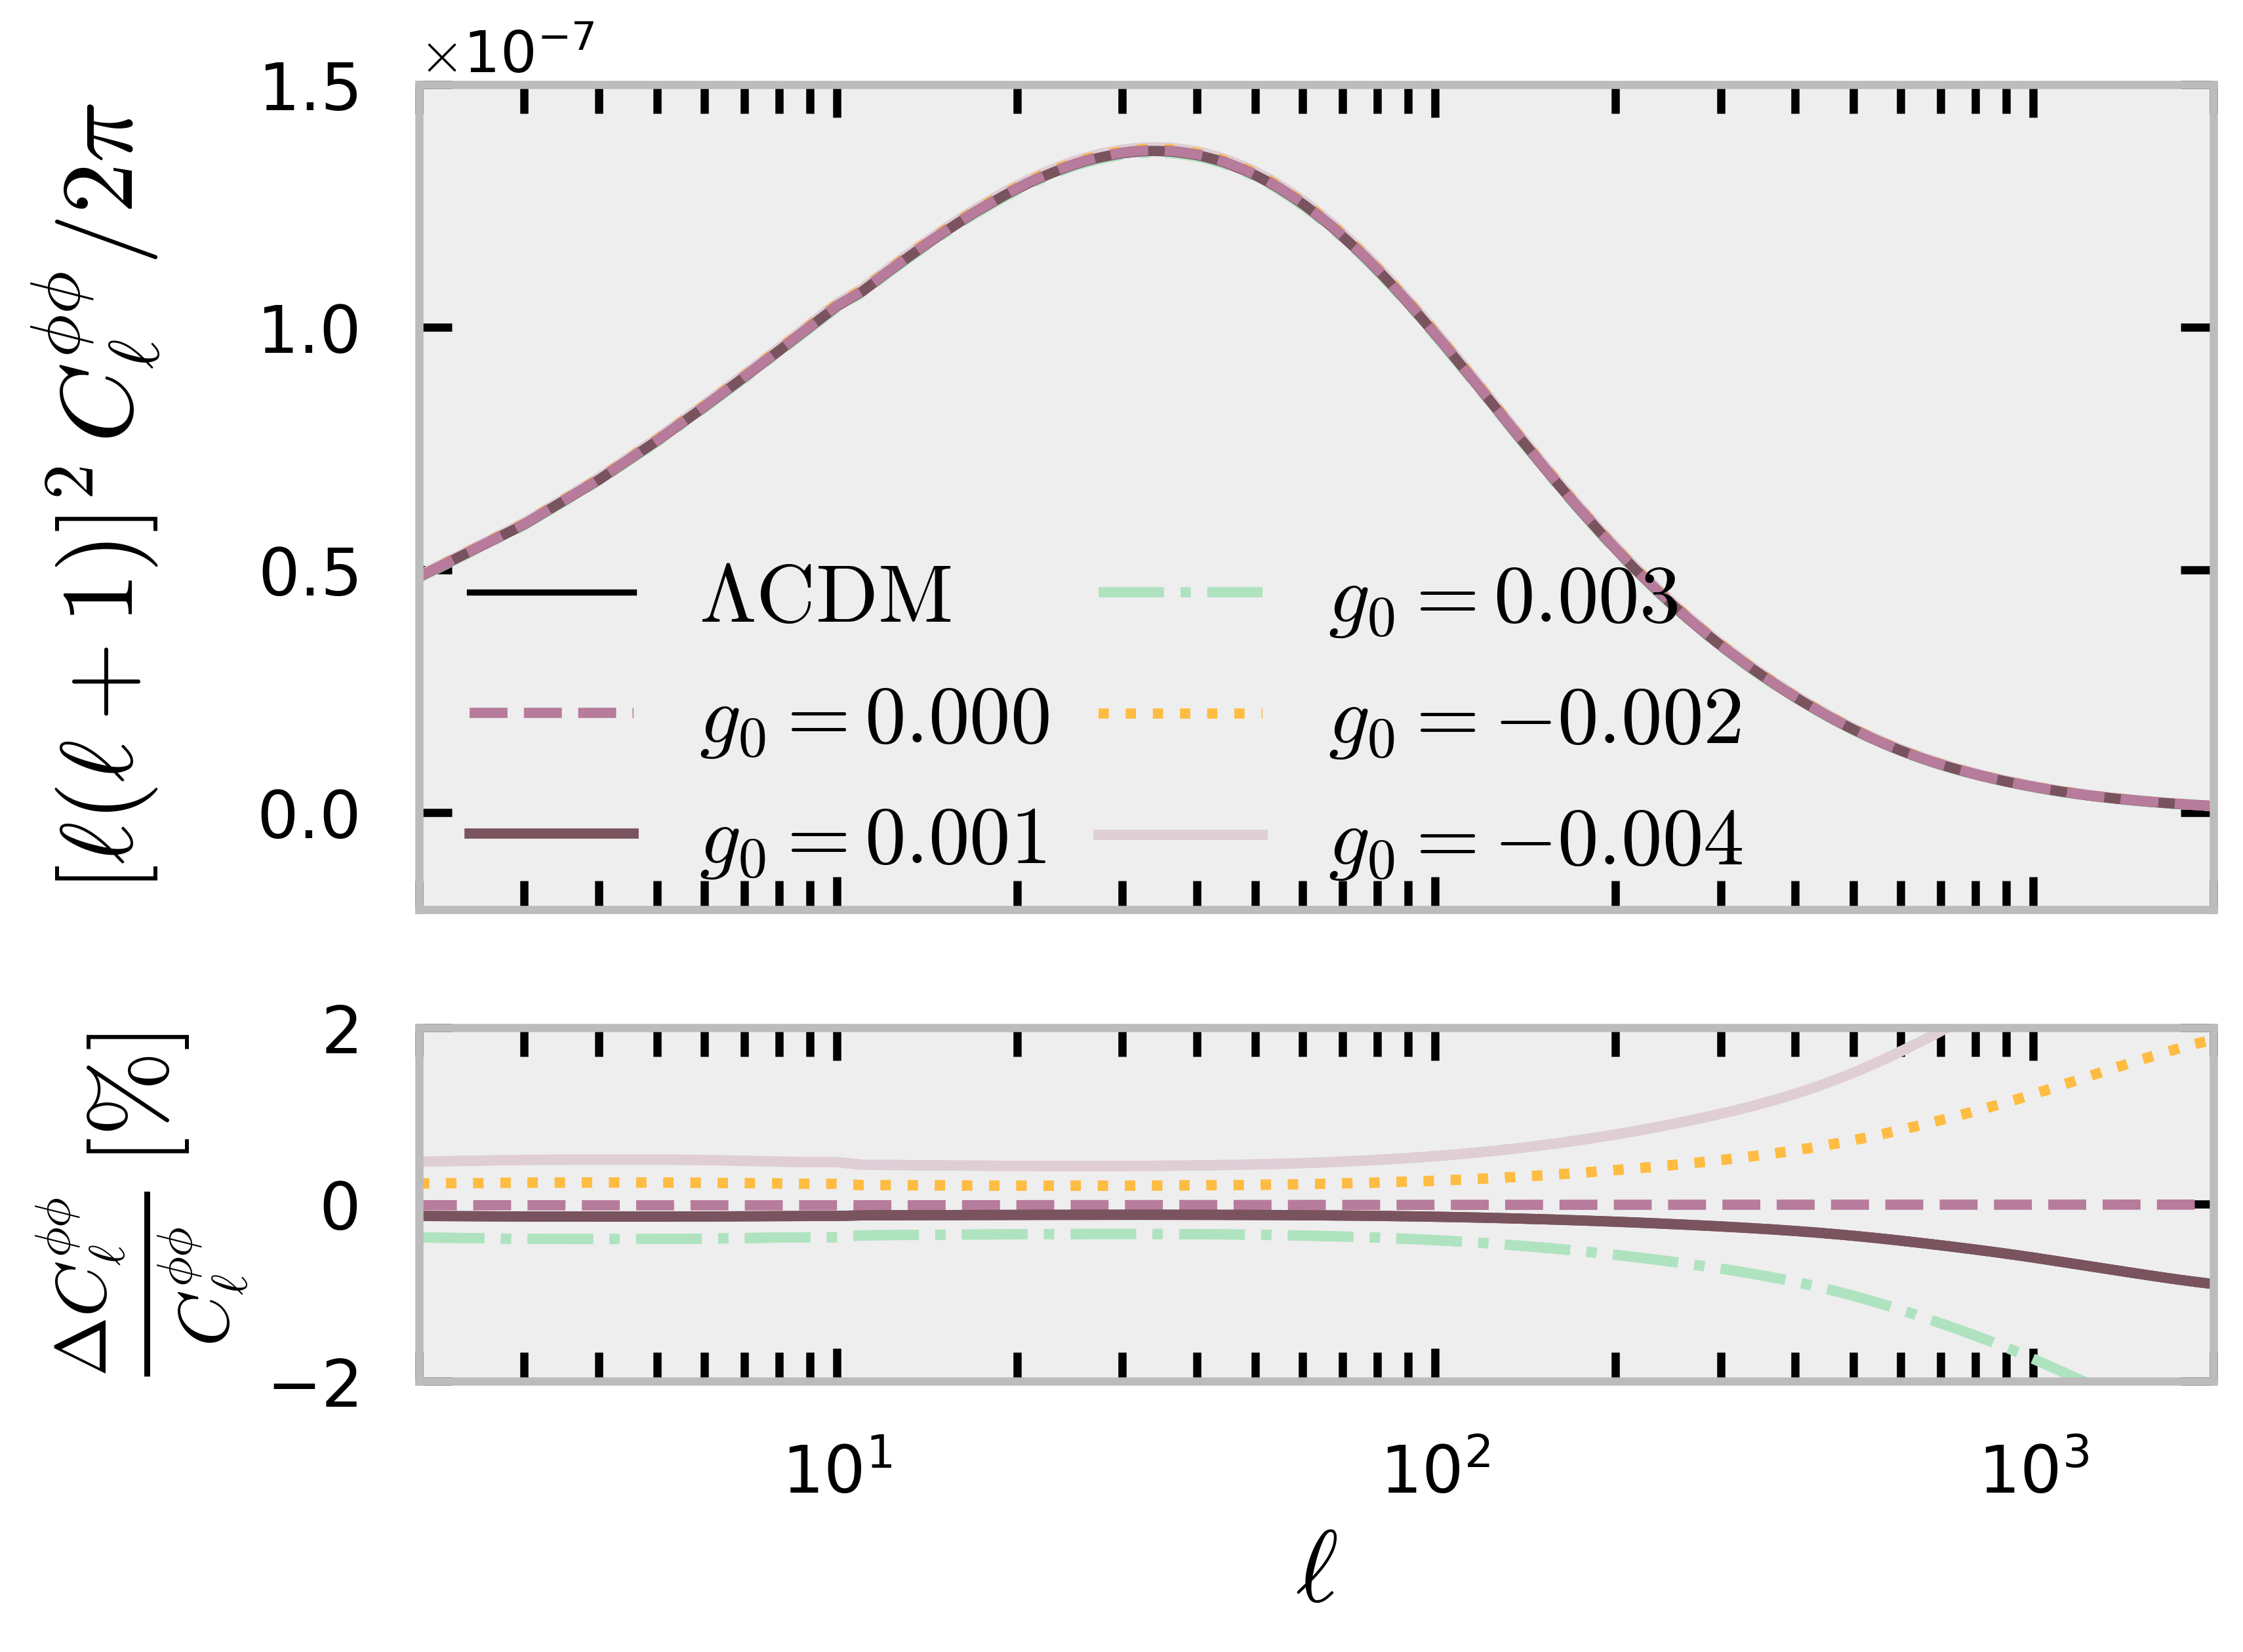

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

# get lambdac
cls_standard = standard.lensed_cl(2000)
ll = cls_standard['ell'][2:]
clPP_standard = cls_standard['pp'][2:]
print(clPP_standard)
# plot Lc
ax0.plot(ll,clPP_standard*(ll*(ll+1))**2./2./np.pi, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)

i=0
for index in [0,1,2,3,4]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].lensed_cl(2000)
    ll = cls['ell'][2:]
    clPP = cls['pp'][2:]
# plot C_l^EE
    ax0.plot(ll,clPP*(ll*(ll+1))**2./2./np.pi, label = \
            r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = clPP / clPP_standard - 1
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1

#ns-f0 plot 
ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(2,2000)
ax0.set_ylim(-2.e-8,1.5e-7)
ax1.set_yticks([i for i in np.linspace(0,2.e-7,5)])
ax1.set_yscale('linear')
ax1.set_xscale('log')
ax1.set_xlim(2,2000)
ax1.set_ylim(-2,2)
ax1.set_yticks([i for i in np.linspace(-2,2,3)])
#ax1.set_yticks([i for i in np.linspace(-10,10,3)])

ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$[\ell(\ell+1)]^2\, C_\ell^{\phi\phi}/2 \pi$', size=25,labelpad=23)
ax1.set_ylabel(r'$\frac{\Delta C_\ell^{\phi\phi}}{C_\ell^{\phi\phi}}\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.legend(loc=(0.01, 0.02), frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.6,bbox_to_anchor=(0.01, -0.005))
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('clsff_alg_constant.pdf', transparent=True)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


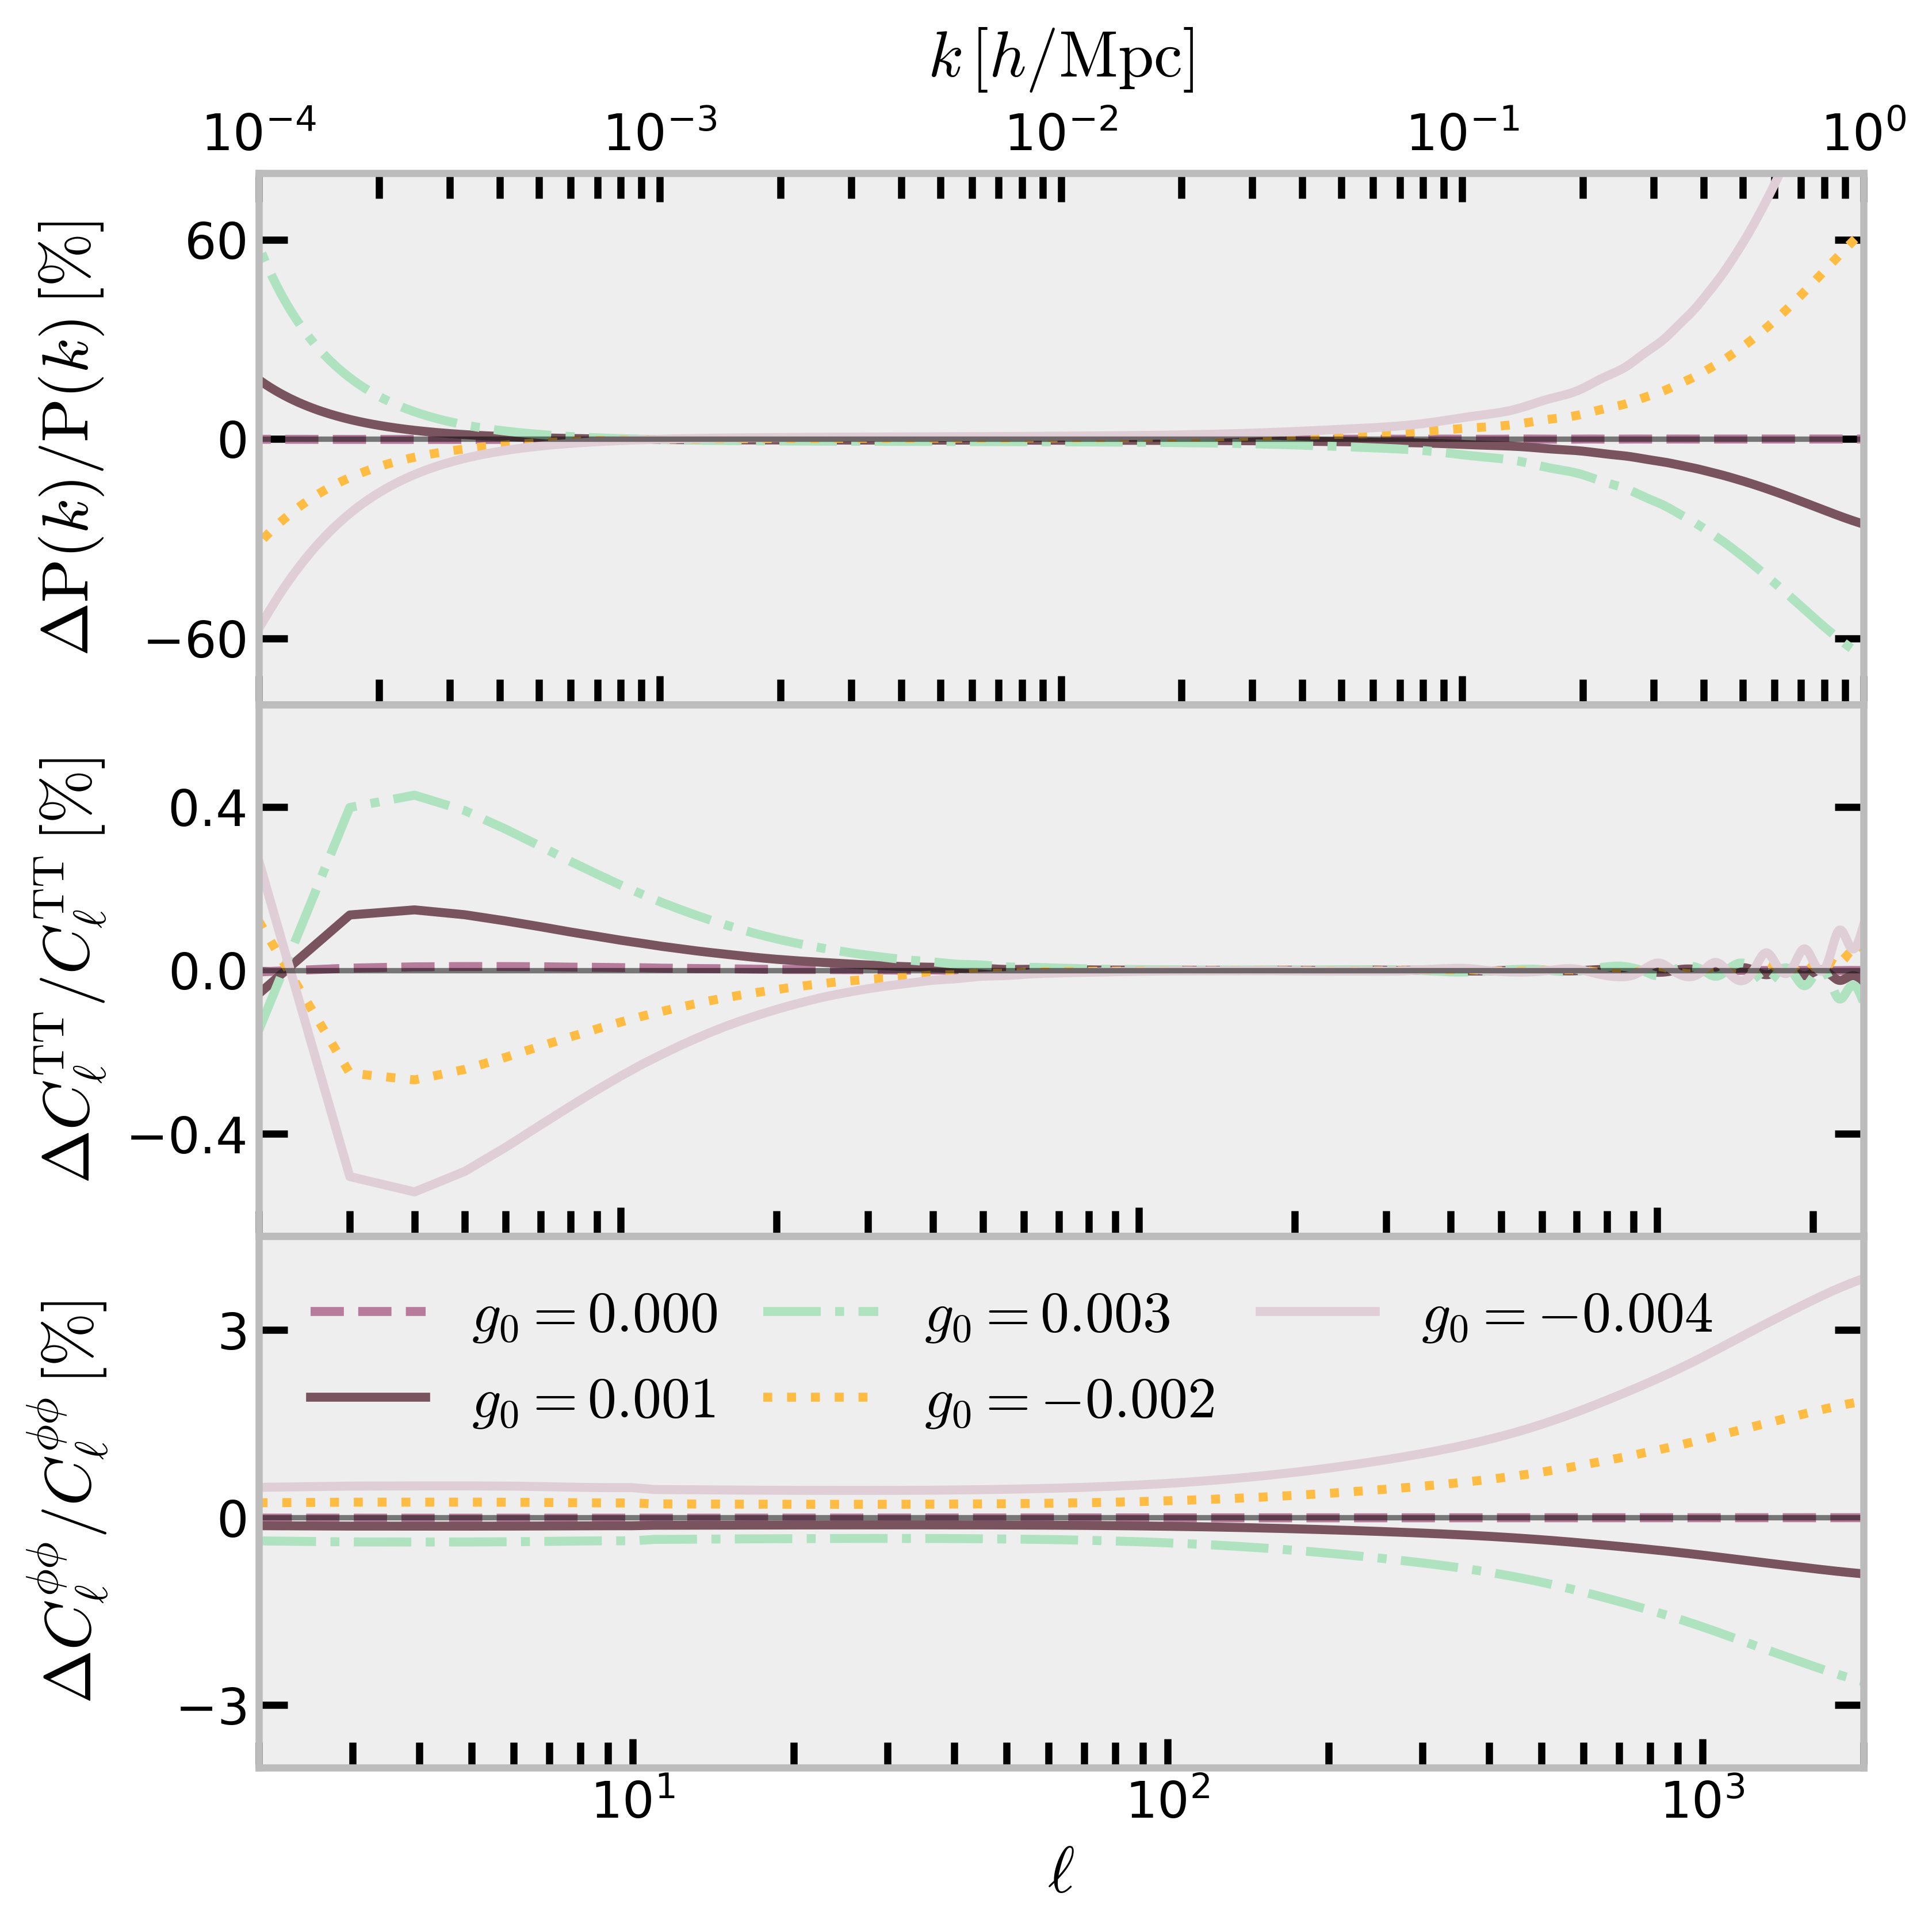

In [ ]:
# Three-panel plot: Top = ΔP(k)/P(k) vs k (x-axis on top), Middle = ClTT rel diff, Bottom = Cls_phiphi rel diff, no space between panels
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])
lw = 2.5
ls = ['--','-','-.', ':', '-']
fig, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(8, 8), sharex=False, gridspec_kw={'height_ratios': [1, 1, 1]})
# Top panel: ΔP(k)/P(k) vs k, x-axis on top
kk = np.logspace(-5, np.log10(10), 1000)
Pk_standard = []
h_standard = standard.h()
for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,0.)*h_standard**3)
i = 0
for index in [0,1,2,3,4]:
    h = cosmo[index].h()
    DELTA = []
    for k in kk:
        DELTA.append(100*(cosmo[index].pk(k*h,0.)*h**3 - standard.pk(k*h_standard,0.)*h_standard**3) / (standard.pk(k*h_standard,0.)*h_standard**3))
    ax_top.plot(kk, DELTA, label = r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    i += 1
ax_top.set_xscale('log')
ax_top.set_yscale('linear')
ax_top.set_xlim(kk[0], kk[-1])
ax_top.set_ylabel(r'$\Delta {\rm P}(k)/{\rm P}(k)\, [\%]$', size=18, labelpad=10)
ax_top.set_xlim([1.e-4,1])
ax_top.ticklabel_format(axis='y', style='plain', useMathText=True)
ax_top.tick_params(axis='both', which='both', labelsize=14)
ax_top.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=True, labeltop=True, labelbottom=False)
ax_top.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=True)
ax_top.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax_top.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
# ax_top.legend(loc='lower left', frameon=False, prop={'size': 14}, ncol=2, columnspacing=1)
ax_top.set_xlabel(r'$k \, [h/{\rm Mpc}]$', size=18, labelpad=10)
ax_top.xaxis.set_label_position('top')
# Middle panel: ClTT relative differences
cls_standard_tt = standard.lensed_cl(2500)
ll_tt = cls_standard_tt['ell'][2:]
clTT_standard = cls_standard_tt['tt'][2:]
i = 0
for index in [0,1,2,3,4]:
    cls = cosmo[index].lensed_cl(2500)
    ll = cls['ell'][2:]
    clTT = cls['tt'][2:]
    DELTA_TT = (clTT - clTT_standard) / clTT_standard
    ax_mid.plot(ll, DELTA_TT*100, label=r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    i += 1
ax_mid.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax_mid.set_xscale('log')
ax_mid.set_yscale('linear')
ax_mid.set_xlim(2, 2500)
ax_mid.set_ylabel(r'$\Delta C_\ell^\mathrm{TT}/C_\ell^\mathrm{TT}\, [\%]$', size=18, labelpad=5)
ax_mid.ticklabel_format(axis='y', style='plain')
ax_mid.tick_params(axis='both', which='both', labelsize=14)
ax_mid.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=False)
ax_mid.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=False)
ax_mid.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax_mid.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
ax_mid.set_xticklabels([])
# Bottom panel: Cls_phiphi relative differences
cls_standard_pp = standard.lensed_cl(2000)
ll_pp = cls_standard_pp['ell'][2:]
clPP_standard = cls_standard_pp['pp'][2:]
i = 0
for index in [0,1,2,3,4]:
    cls = cosmo[index].lensed_cl(2000)
    ll = cls['ell'][2:]
    clPP = cls['pp'][2:]
    DELTA_PP = (clPP - clPP_standard) / clPP_standard
    ax_bot.plot(ll, DELTA_PP*100, label=r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    i += 1
ax_bot.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax_top.axhline(0, color='k', ls='-', lw=1.5, alpha=0.5)
ax_bot.set_xscale('log')
ax_bot.set_yscale('linear')
ax_bot.set_xlim(2, 2000)
ax_top.set_ylim(-80, 80)
ax_top.set_yticks([i for i in np.linspace(-60, 60, 3)])
ax_mid.set_ylim(-0.65, 0.65)
ax_mid.set_yticks(np.linspace(-0.4, 0.4, 3))
# ax_bot.set_ylim(-1.5, 1.7)
ax_bot.set_ylim(-4, 4.5)
ax_bot.set_yticks(np.linspace(-3, 3, 3))
ax_bot.set_xlabel(r'$\ell$', size=18)
ax_bot.set_ylabel(r'$\Delta C_\ell^{\phi\phi}/C_\ell^{\phi\phi}\, [\%]$', size=18, labelpad=18)
ax_bot.ticklabel_format(axis='y', style='plain')
ax_bot.tick_params(axis='x', which='both', top=False, labelsize=14)
ax_bot.tick_params(axis='y', which='both', labelsize=14)
ax_bot.xaxis.set_tick_params(which='major', size=8, width=2, direction='in')
ax_bot.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in')
ax_bot.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax_bot.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)
ax_bot.legend(loc='upper left', frameon=False, prop={'size': 16}, ncol=3, columnspacing=0.8)
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig('cls_mpk_rel_alg_constant.pdf', transparent=True)
plt.show()

ValueError: Expect x to not have duplicates

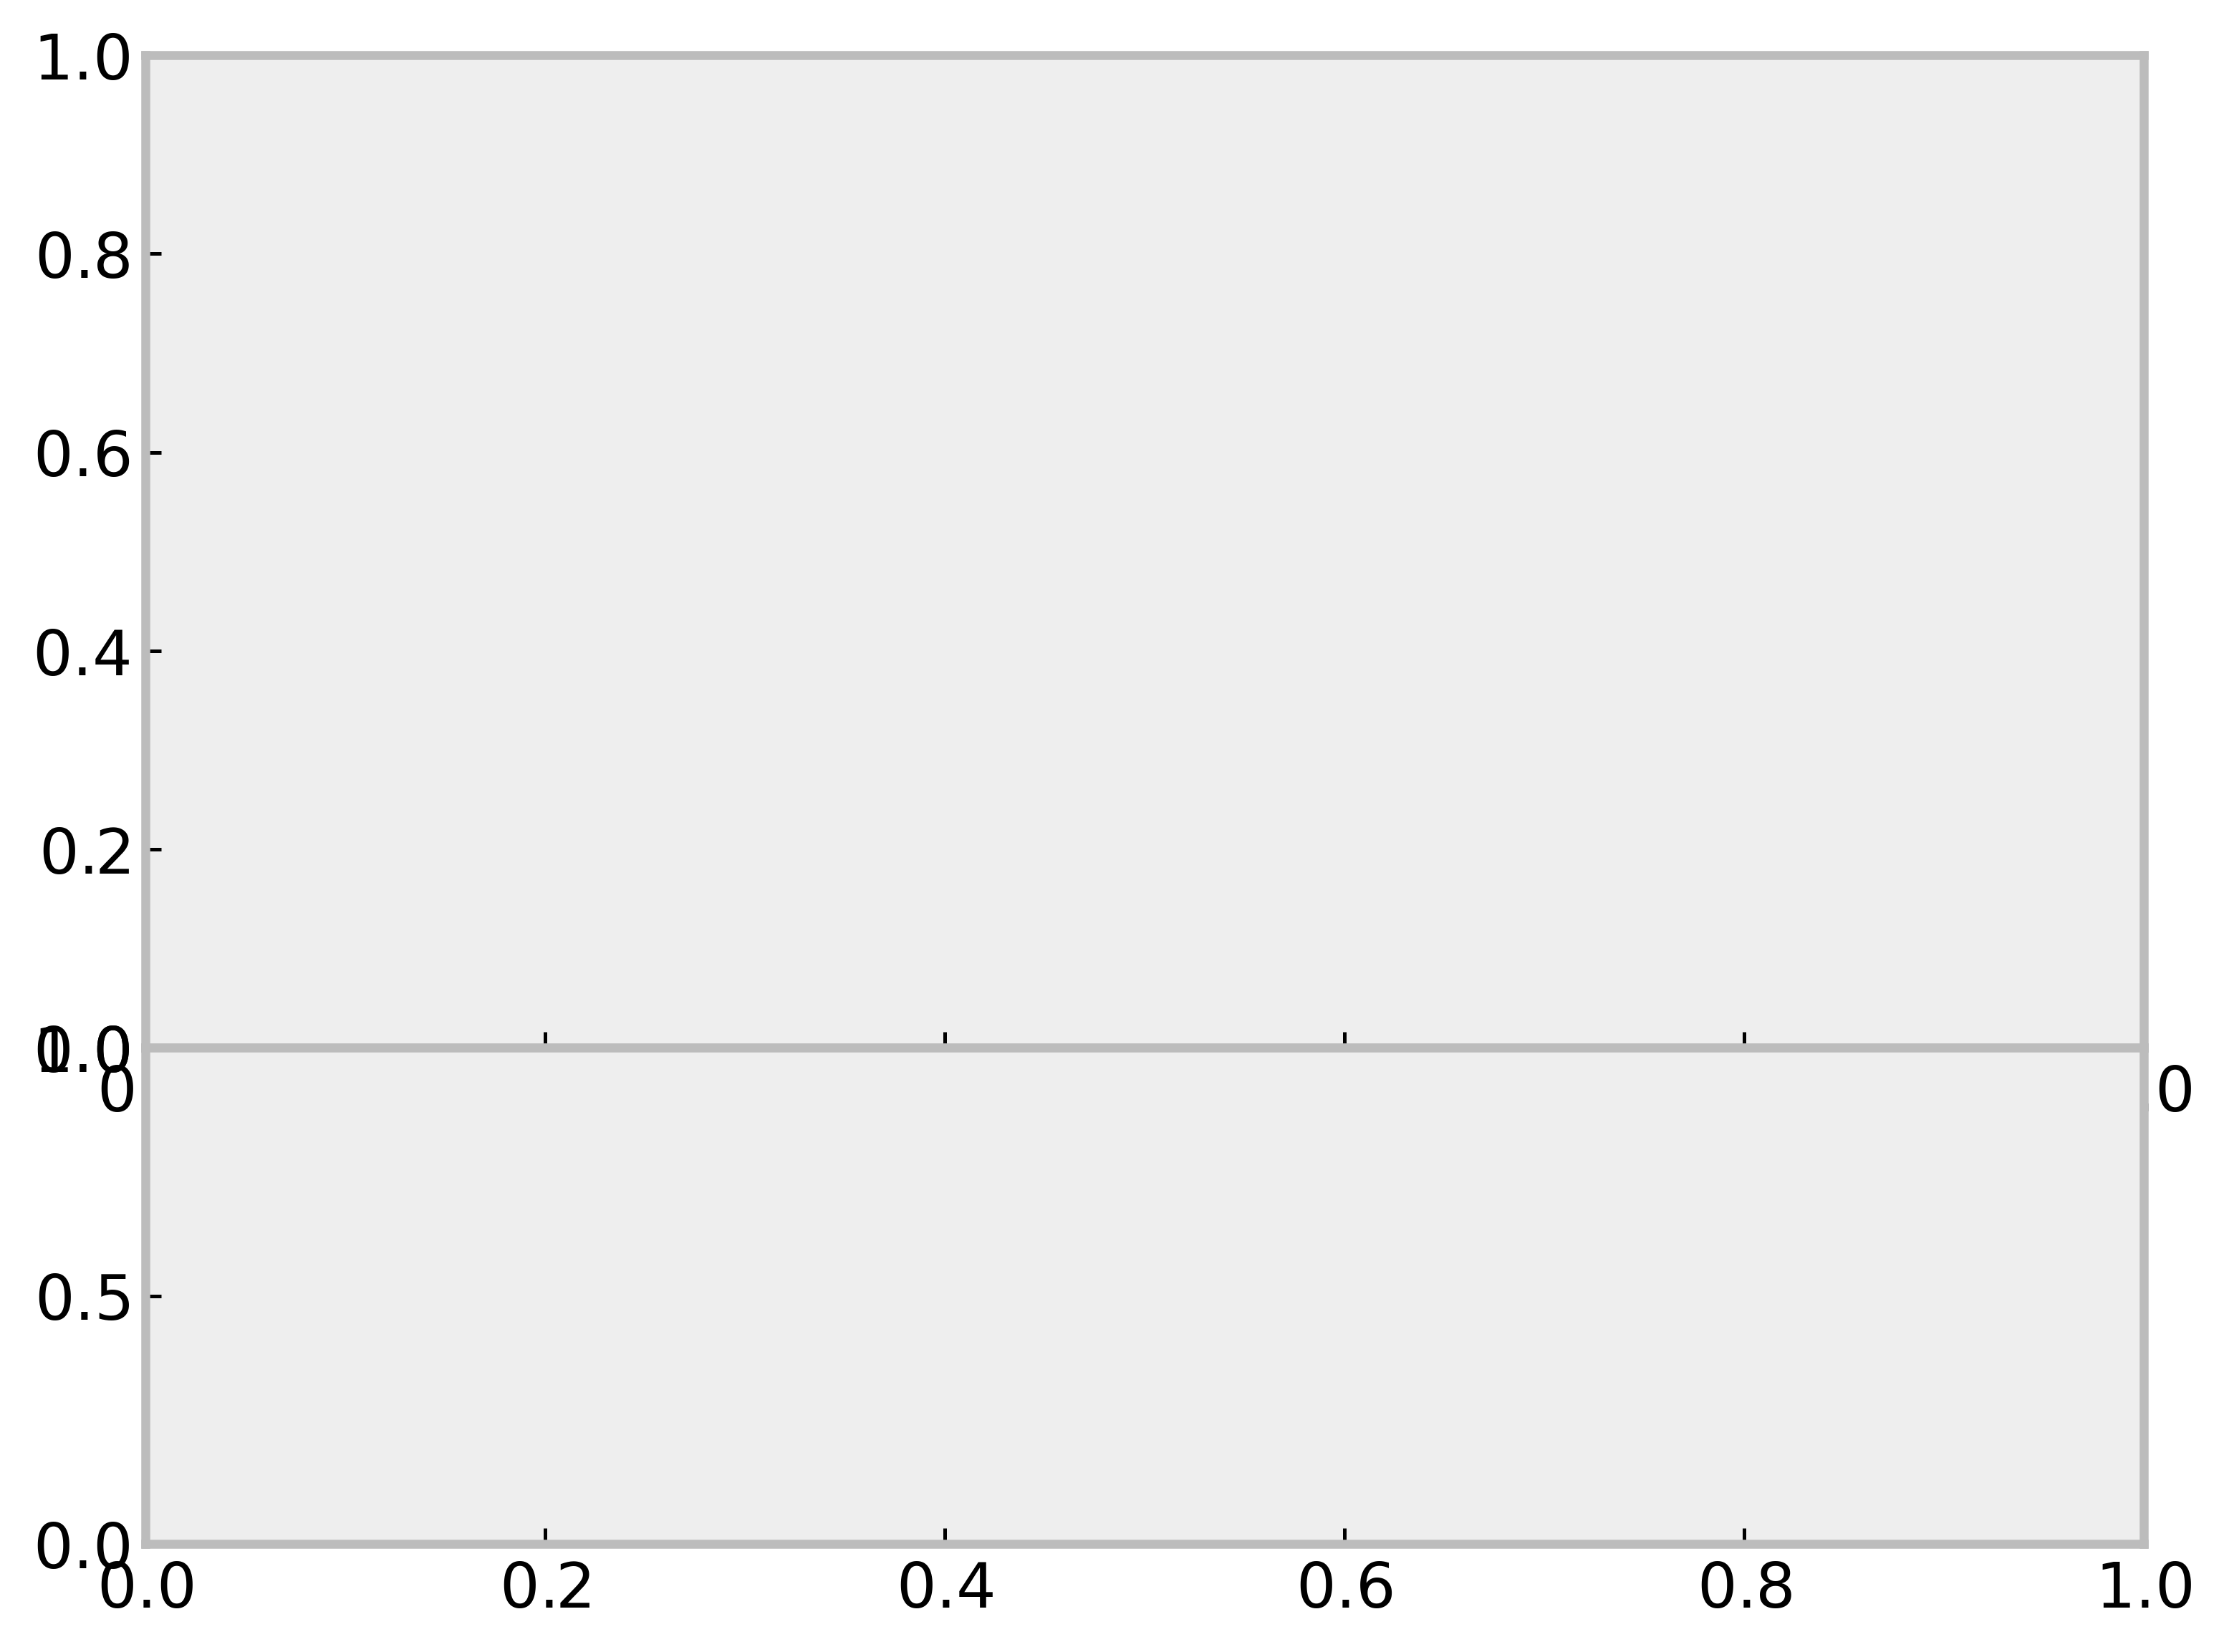

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']

temp = 10.0**(-8.0)

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

zz = np.linspace(10**5,1.,100000) # k in h/Mpc
zzi=zz[::-1]
taut = np.linspace(10**(-2),10**5,100000)
#print(zzi)
index_k = 2
# get lambdac
standardPerturb=standard.get_perturbations()
a = standardPerturb['scalar'][index_k]['a']
z=1/a
tau = standardPerturb['scalar'][index_k]['tau [Mpc]']
zi=z[::-1]
#print(zi)
Phipl = standardPerturb['scalar'][index_k]['phi']
Phipli = Phipl[::-1]
Psipl = standardPerturb['scalar'][index_k]['psi']
Psipli = Psipl[::-1]
phipsil_int = interp1d(zi,(Phipli+Psipli),kind="quadratic",fill_value='extrapolate')
tphipsil_int = interp1d(tau,(Phipl+Psipl))
phipsil_intt =  UnivariateSpline(zzi,phipsil_int(zzi))
tphipsil_intt =  UnivariateSpline(tau,tphipsil_int(tau))
#print(phipsil_intt(zzi))
phipsil_intt.set_smoothing_factor(temp)
phipsil_inttd = phipsil_intt.derivative(1)
tphipsil_intt.set_smoothing_factor(temp)
tphipsil_inttd = tphipsil_intt.derivative(1)
#print(phipsil_inttd(zzi))
#phipsild_int = np.gradient(phipsil_int(zz),zz)
#print(phipsil_int(zzi))
#phipsil_int_d1 = interpolate.spline(z,Phipl+Phipl,order=1)
# plot Lc
#print(phipsild_int)
ax0.plot(zzi, -phipsil_inttd(zzi), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
i=0
index_k = index_k_list[i]
print('k =', k_sorted[index_k])
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    cosmoPerturb=cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z=1/a
    zi=z[::-1]
    Phip = cosmoPerturb['scalar'][index_k]['phi']
    Phipi = Phip[::-1]
    Psip = cosmoPerturb['scalar'][index_k]['psi']
    Psipi = Psip[::-1]
    phipsi_int = interp1d(zi,(Phipi+Psipi)*10**3)
    phipsi_intt =  UnivariateSpline(zzi,phipsi_int(zzi))
    phipsi_intt.set_smoothing_factor(temp)
    phipsi_inttd = phipsi_intt.derivative(1)
    DELTA = phipsi_inttd(zzi)/ phipsil_inttd(zzi) -1.
    #DELTA.set_smoothing_factor(temp)

    ax0.plot(zzi, -phipsil_inttd(zzi),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    ax1.plot(zzi,DELTA*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
#ax0.set_xlim(1e4,1)
#ax0.set_ylim(-10,10.)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax0.set_xlim(1e4,1)
ax1.set_ylim(-20.,60.)
ax1.set_yticks([i for i in np.linspace(-20,60,5)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi\prime + \Psi\prime $', size=25,labelpad=12)
ax1.set_ylabel(r'$\Delta (\Phi\prime  + \Psi\prime )/(\Phi\prime  + \Psi\prime )\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('ppppp.pdf', transparent=True)
plt.show()

[1.48064360e-01 2.22077031e-01 3.33071671e-01 4.99508849e-01
 7.49041513e-01 1.12306405e+00 1.68347755e+00 2.52270798e+00
 3.77844608e+00 5.65512644e+00 8.45477750e+00 1.26203804e+01
 1.87948582e+01 2.78975005e+01 4.12159307e+01 6.05049849e+01
 8.80758338e+01 1.26856083e+02 2.28798833e+02 2.28940758e+02
 2.29083225e+02 2.29226242e+02 2.29369815e+02 2.29513952e+02
 2.29658660e+02 2.29803948e+02 2.29949821e+02 2.30096289e+02
 2.30243359e+02 2.30391038e+02 2.30539336e+02 2.30688261e+02
 2.30837820e+02 2.30988023e+02 2.31138878e+02 2.31290394e+02
 2.31442580e+02 2.31595445e+02 2.31748999e+02 2.31903251e+02
 2.32058211e+02 2.32213889e+02 2.32370294e+02 2.32527437e+02
 2.32685329e+02 2.32843980e+02 2.33003400e+02 2.33163601e+02
 2.33324595e+02 2.33486392e+02 2.33649004e+02 2.33812443e+02
 2.33976721e+02 2.34141851e+02 2.34307845e+02 2.34474716e+02
 2.34642477e+02 2.34811141e+02 2.34980722e+02 2.35151235e+02
 2.35322692e+02 2.35495109e+02 2.35668501e+02 2.35842882e+02
 2.36018268e+02 2.361946

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_90145/2827741001.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_90145/2827741001.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


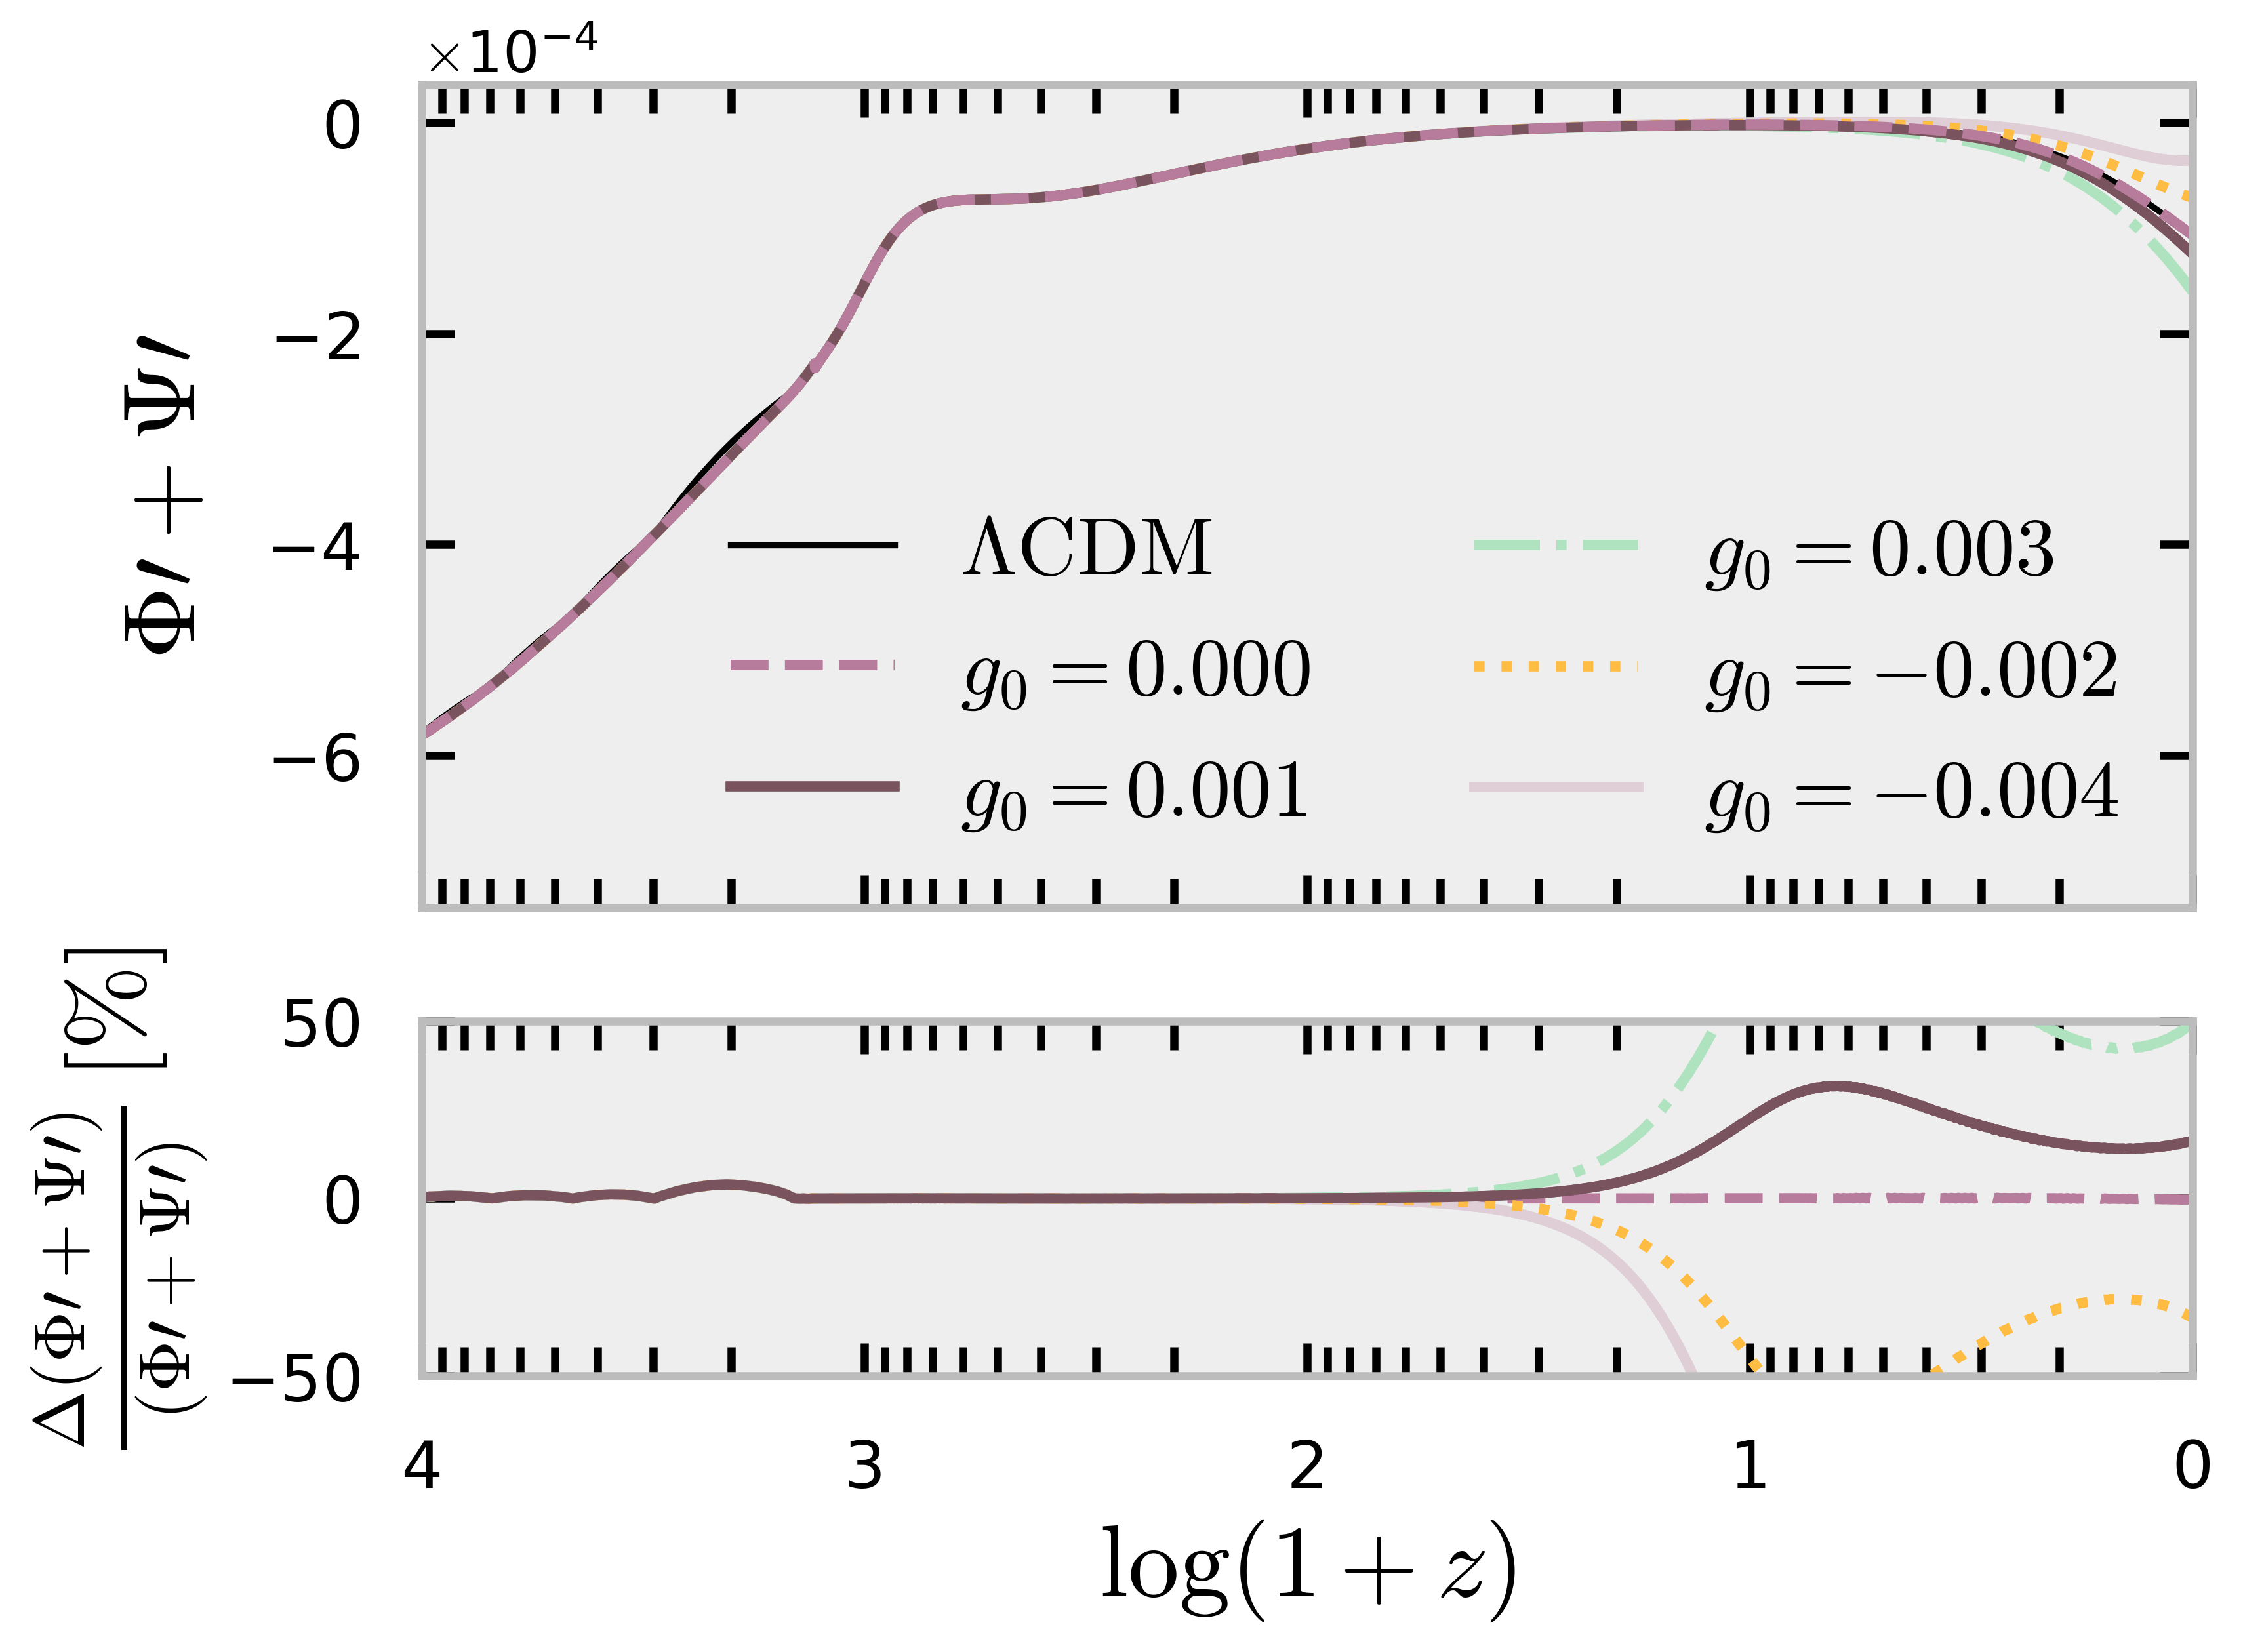

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

zz = np.logspace(5,0,10000) # k in h/Mpc
#tt = np.linspace(10**(-9),5.)
zzi = zz[::-1]
#print(zz)
#print(zzi)
index_k = 0
# get lambdac
standardPerturb=standard.get_perturbations()
a = standardPerturb['scalar'][index_k]['a']
tau = standardPerturb['scalar'][index_k]['tau [Mpc]']
print(tau)
z=1/a
zi = z[::-1]
Phipl = standardPerturb['scalar'][index_k]['phi_prime']
print(Phipl)
Phipli = Phipl[::-1]
Psipl = standardPerturb['scalar'][index_k]['phi_prime']
Psipli = Psipl[::-1]
phipsil_int = interp1d(zi,Phipli+Psipli)
# plot Lc
ax0.plot(zzi, phipsil_int(zzi), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)

print('k =', k_sorted[index_k])
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    cosmoPerturb=cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z=1/a
    zi = z[::-1]
    Phip = cosmoPerturb['scalar'][index_k]['phi_prime']
    Phipi = Phip[::-1]
    Psip = cosmoPerturb['scalar'][index_k]['phi_prime']
    Psipi = Psip[::-1]
    phipsi_int = interp1d(zi,Phipi+Psipi)

    ax0.plot(zzi, phipsi_int(zzi),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    DELTA = (phipsi_int(zzi)  - phipsil_int(zzi)) / phipsil_int(zzi)
    ax1.plot(zzi,DELTA*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(1e4,1)
#ax0.set_ylim(0,1.1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

#ns-f0 plot 
ax1.set_yscale('linear')
ax1.set_xscale('log')
ax0.set_xlim(1e4,1)
ax1.set_ylim(-10.,10.)
ax1.set_yticks([i for i in np.linspace(-50,50,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi\prime + \Psi\prime$', size=25,labelpad=12)
ax1.set_ylabel(r'$\frac{\Delta (\Phi\prime + \Psi\prime)}{(\Phi\prime + \Psi\prime)}\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)


ax0.tick_params(axis='both', which='both', labelsize=16)


ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)


ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax1.ticklabel_format(axis='y', style='plain', useMathText=True)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20},ncol=2)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('pppp2_alg_constant.pdf', transparent=True)
plt.show()

In [ ]:

smooth_factor = 1e-8
order=5
index_k = 2
print('k =', k_sorted[index_k])
print('k_index =', index_k)
# get lambdac
standardPerturb=standard.get_perturbations()
#print(al)
zl=(1./al)
zil = z[::-1]
Phipli = Phipl[::-1]
Psipli = Psipl[::-1]
Potl = Phipl+Psipl
Potl_intz = interp1d(zl,Potl,kind="cubic",fill_value="extrapolate")
Potl_intt = interp1d(taul,Potl,kind="cubic",fill_value="extrapolate")

z=[]
zi=[]
Phipi=[]
Psipi=[]
Pot=[]
Pot_intz=[]
Pot_intt=[]
SPot=[]
dPot=[]
test=[]
ui=[]
deltap=[]

for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    cosmoPerturb=cosmo[index].get_perturbations()
    #print(a[index])
    z.append(1/a[index])
    zi.append(z[index][::-1])
    Phipi.append(Phip[index][::-1])
    Psipi.append(Psip[index][::-1])
    Pot.append(Phip[index]+Psip[index])
    Pot_intz.append(interp1d(z[index],Pot[index],kind="cubic",fill_value="extrapolate"))
    Pot_intt.append(interp1d(tau[index],Pot[index],kind="cubic",fill_value="extrapolate"))

inf = np.amax([tau[0][0],tau[1][0],tau[2][0]])
sup = np.amin([tau[0][-1],tau[1][-1],tau[2][-1]])

tau_array = np.linspace(inf,sup,100000)

z_inf = np.amax([z[0][-1],z[1][-1],z[2][-1]])
z_sup = np.amin([z[0][0],z[1][0],z[2][0]])

z_break = 10
z_array = np.linspace(z_inf,z_break,1000000)
z_array2 = np.linspace(z_break,z_sup,1000000)

z_array3 = np.linspace(z_inf,z_sup,1000000)

SPotl = UnivariateSpline(taul, Potl_intt(taul),k=4,s=5e5)
SPotl.set_smoothing_factor(smooth_factor)
dPotl = SPotl.derivative(1)
testl = interp1d(zl,taul,kind="cubic",fill_value="extrapolate")
uil = interp1d(z_array3,dPotl(testl(z_array3)),kind="quadratic",fill_value='extrapolate')

for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    SPot.append(UnivariateSpline(tau[index], Pot_intt[index](tau[index]),k=4,s=5e5))
    SPot[index].set_smoothing_factor(smooth_factor)
    dPot.append(SPot[index].derivative(1))
    test.append(interp1d(z[index],tau[index],kind="cubic",fill_value="extrapolate"))
    ui.append(interp1d(z_array3,dPot[index](test[index](z_array3)),kind="quadratic",fill_value='extrapolate'))
    deltap.append(interp1d(z_array3,dPot[index](test[index](z_array3))/dPotl(testl(z_array3)) - 1.,kind="quadratic",fill_value='extrapolate'))
    #print(ui[index](z_array3).tolist())
    #print(deltap[index](z_array3).tolist())
#print(a[1][-1])

k = 0.067556
k_index = 2


NameError: name 'al' is not defined

NameError: name 'z_array' is not defined

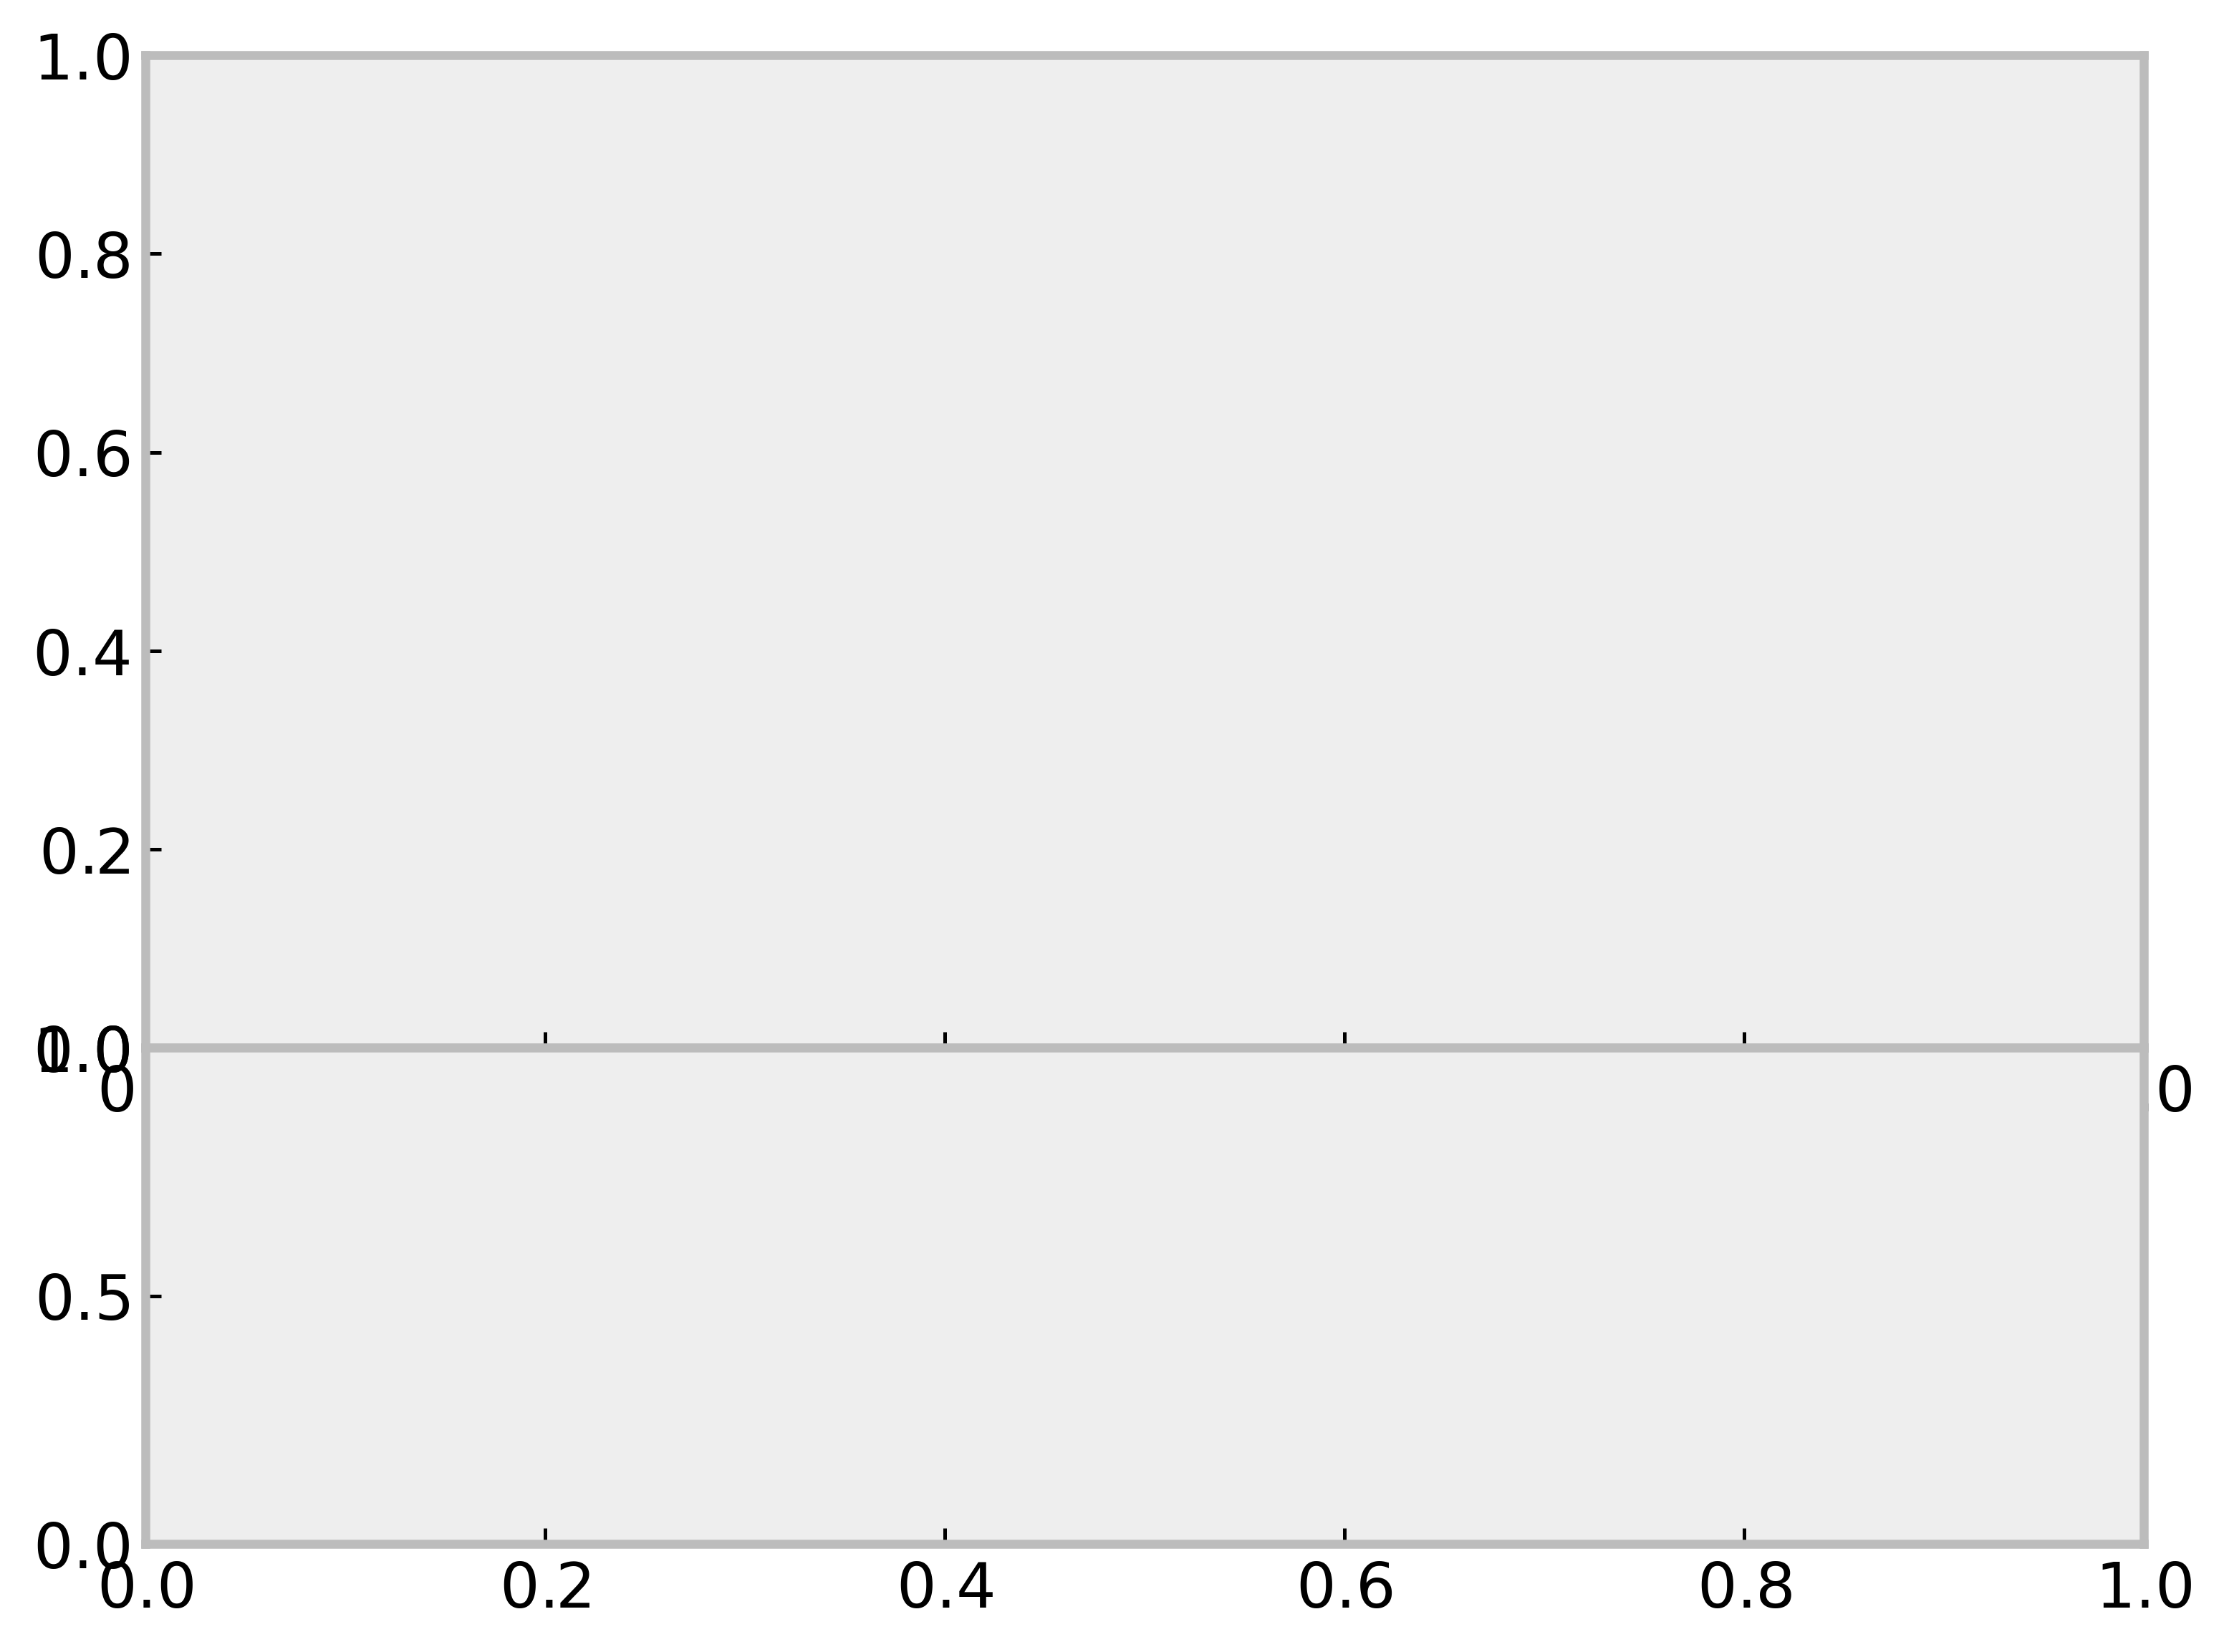

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

ax0.plot(z_array,uil(z_array)*1e4, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
ax0.plot(z_array2,uil(z_array2)*1e4, c = 'k', ls='-', lw=1.5)
index_k = 2
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    DELTA1 = (ui[index](z_array)*10e3- uil(z_array)*10e3)/(uil(z_array)*10e3)
    DELTA2 = (ui[index](z_array2)*10e3 - uil(z_array2)*10e3)/(uil(z_array2)*10e3)
    
    #DELTA.set_smoothing_factor(temp)
    ax0.plot(z_array,ui[index](z_array)*1e4,
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    ax0.plot(z_array2,ui[index](z_array2)*1e4 ,
         lw=lw, ls=ls[style],c=color[style])
    ax1.plot(z_array, ((ui[index](z_array)-uil(z_array))*100.), lw=lw, ls=ls[style],c=color[style])
    ax1.plot(z_array2, ((ui[index](z_array2)-uil(z_array2))*100.), lw=lw, ls=ls[style],c=color[style])
    #ax1.plot(z_array2,-100.*DELTA2, lw=lw, ls=ls[style],c=color[style])
    style+=1



ax0.set_yscale('linear')
ax0.set_xscale('log')
#ax0.set_xlim([coiso*z_array2[-1],z_array[0]])
ax0.set_ylim(-10,7.)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax1.set_xlim(5e3,1)
ax1.set_ylim(-0.001,0.001)
#ax1.set_yticks([i for i in np.linspace(-45,45,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$ 10^4\ (\Phi\prime + \Psi\prime) $', size=25,labelpad=25)
ax1.set_ylabel(r'$\Delta (\Phi\prime  + \Psi\prime )\, [\%]$', size=25)

#ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)
#ax0.text(0.95*10e4, -1.6,r'$(\times 10^{4})$', fontsize=15,rotation=90)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.8)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('lensp.pdf')
#, transparent=True)
plt.show()